--- Starting Analysis ---
Loading data...
Data loaded successfully.
Input features shape: (13, 113)
Results shape: (195, 5)
Preparing results data...
Daily MAE calculated:
        date  Daily_MAE_Final_RLS
0 2024-06-18          1513.126667
1 2024-06-19           584.474667
2 2024-06-20          1006.241333
3 2024-06-21           522.408667
4 2024-06-22          1868.972000
Merging daily MAE with input features...
Merge complete. Analysis DataFrame shape: (13, 114)
Analysis DataFrame head (MAE column):
            Daily_MAE_Final_RLS
date                           
2024-06-18          1513.126667
2024-06-19           584.474667
2024-06-20          1006.241333
2024-06-21           522.408667
2024-06-22          1868.972000
Starting EDA and generating plots...


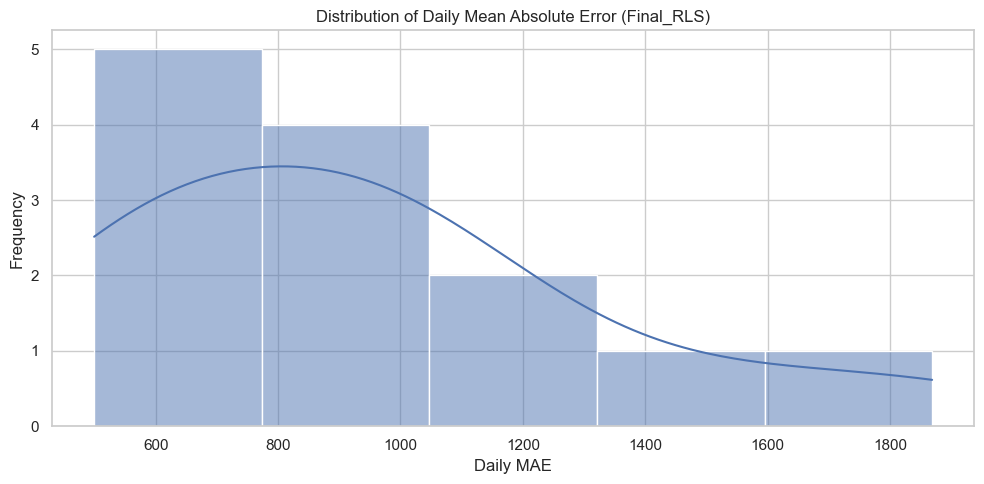

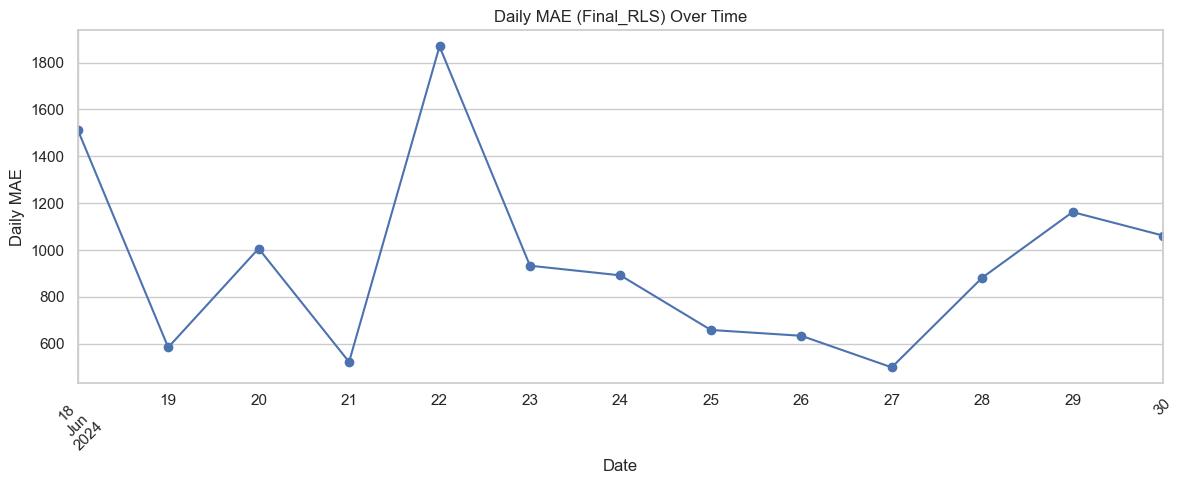


--- MAE Statistics ---
count      13.000000
mean      939.801231
std       401.392375
min       499.260000
25%       633.994000
50%       891.901333
75%      1061.549333
max      1868.972000
Name: Daily_MAE_Final_RLS, dtype: float64
Calculating aggregated features for correlation analysis...
Calculating and plotting correlation matrix...


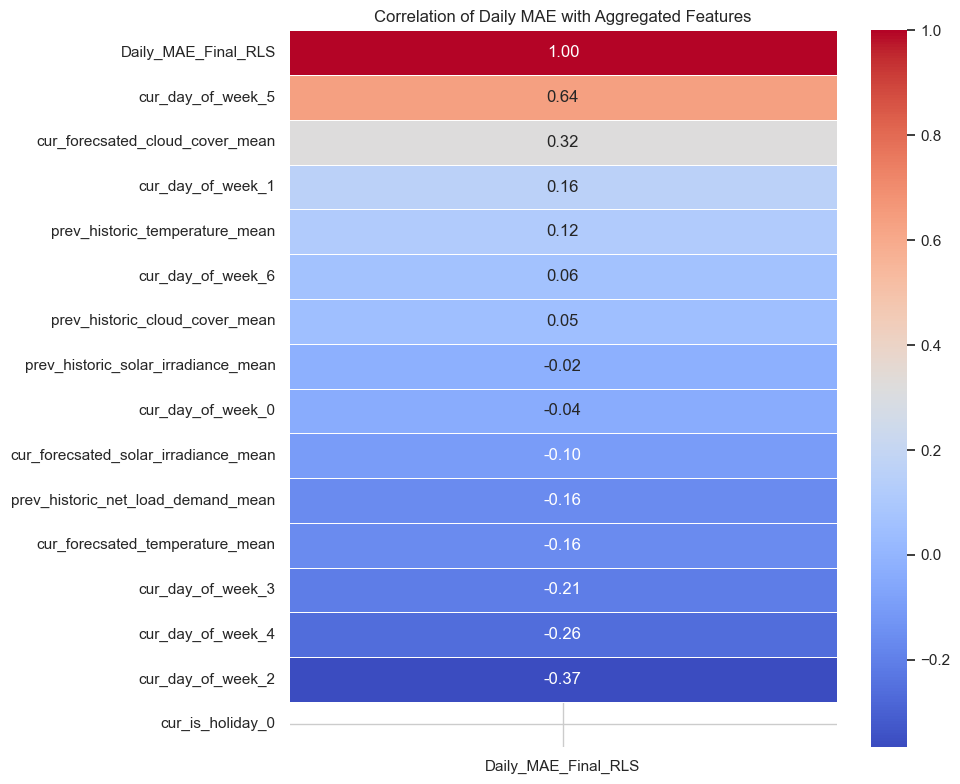


--- Correlation with Daily MAE ---
Daily_MAE_Final_RLS                                    1.0
cur_day_of_week_5                                 0.636512
cur_forecsated_cloud_cover_mean                   0.319503
cur_day_of_week_1                                 0.161624
prev_historic_temperature_mean                    0.119204
cur_day_of_week_6                                 0.063539
prev_historic_cloud_cover_mean                      0.0457
prev_historic_solar_irradiance_mean              -0.023755
cur_day_of_week_0                                -0.035856
cur_forecsated_solar_irradiance_mean             -0.103582
prev_historic_net_load_demand_mean               -0.160582
cur_forecsated_temperature_mean                  -0.161009
cur_day_of_week_3                                -0.206819
cur_day_of_week_4                                -0.262873
cur_day_of_week_2                                -0.365502
cur_is_holiday_0                        N/A (No Variation)
Name: Daily_MAE_Fina

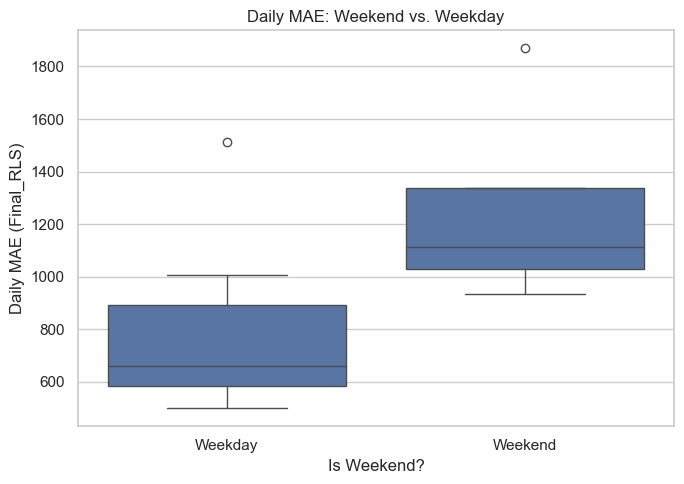

Generating scatter plots: MAE vs. Cloud Cover and Solar Irradiance...


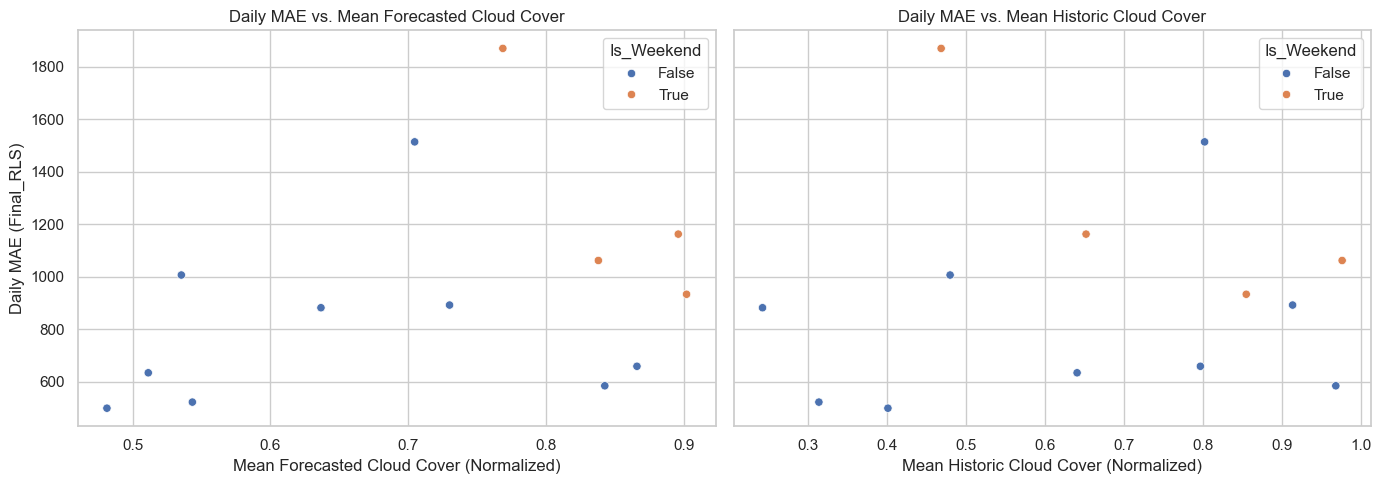

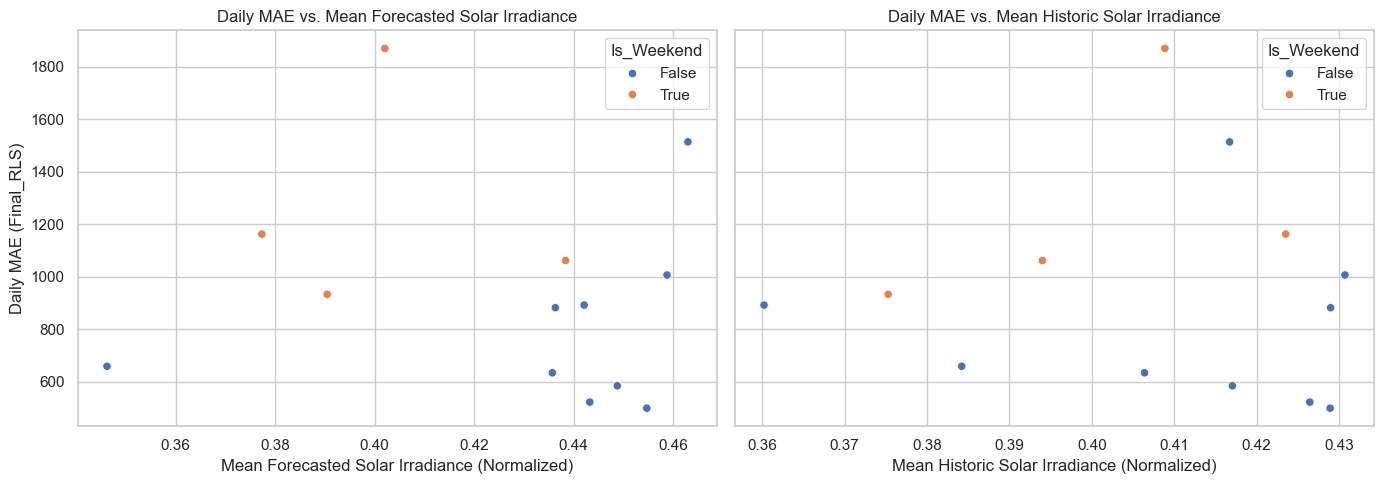


--- Analysis Complete ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore simple warnings if any occur during plotting or calculations
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)  # Often from seaborn plots

print("--- Starting Analysis ---")

# --- 1. Load Data ---
print("Loading data...")
try:
    # Define file paths (adjust if necessary for your local setup)
    results_path = "./../Results/Daytime/Validation_Features/Arch_Hall_ST2B13_Validation_Results.csv"
    inputs_path = "./../Data/Clustering_Data/Daytime/Validation_Features/Arch_Hall_ST2B13_X_Validation_Normalized.csv"

    # Load results data
    df_results = pd.read_csv(results_path, index_col=0, parse_dates=True)

    # Load input features data
    df_inputs = pd.read_csv(inputs_path, index_col=0, parse_dates=True)  # Assuming 'date' is the first column

    print("Data loaded successfully.")
    print(f"Input features shape: {df_inputs.shape}")
    print(f"Results shape: {df_results.shape}")

except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print("Please ensure the file paths are correct relative to your script location.")
    exit()  # Exit if files are not found
except Exception as e:
    print(f"An error occurred during data loading: {e}")
    exit()

# --- 2. Prepare Results Data ---
print("Preparing results data...")
# Calculate Absolute Error for Final_RLS
df_results["AbsError_Final_RLS"] = (df_results["Actual"] - df_results["Final_RLS"]).abs()
df_results["AbsError_LSTM_RLS"] = (df_results["Actual"] - df_results["LSTM_RLS"]).abs()
df_results["AbsError_ANN_RLS"] = (df_results["Actual"] - df_results["ANN_RLS"]).abs()
df_results["AbsError_Benchmark"] = (df_results["Actual"] - df_results["Benchmark"]).abs()

# Extract date for grouping (index is already datetime)
df_results["date_only"] = df_results.index.date

# Calculate daily MAE
daily_mae = df_results.groupby("date_only")["AbsError_Final_RLS"].mean().reset_index()
daily_mae.rename(columns={"AbsError_Final_RLS": "Daily_MAE_Final_RLS", "date_only": "date"}, inplace=True)

# Convert the 'date' column in daily_mae back to datetime objects for merging
daily_mae["date"] = pd.to_datetime(daily_mae["date"])

print("Daily MAE calculated:")
print(daily_mae.head())

# --- 3. Prepare Input Data ---
# Ensure the index of df_inputs is datetime (already done via parse_dates=True)
# If the index wasn't the date column, you would do:
# df_inputs['date'] = pd.to_datetime(df_inputs['date'])
# df_inputs.set_index('date', inplace=True)
# For this script, we assume the first column IS the date and used as index.

# --- 4. Merge Data ---
print("Merging daily MAE with input features...")
# Merge based on the date index
df_analysis = df_inputs.merge(daily_mae, left_index=True, right_on="date", how="inner")
# Set the date back as index if preferred, or keep it as a column
df_analysis.set_index("date", inplace=True)

print("Merge complete. Analysis DataFrame shape:", df_analysis.shape)
print("Analysis DataFrame head (MAE column):")
print(df_analysis[["Daily_MAE_Final_RLS"]].head())

# --- 5. Exploratory Data Analysis (EDA) ---
print("Starting EDA and generating plots...")

# Set plotting style
sns.set(style="whitegrid")

# --- MAE Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(df_analysis["Daily_MAE_Final_RLS"], kde=True)
plt.title("Distribution of Daily Mean Absolute Error (Final_RLS)")
plt.xlabel("Daily MAE")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# --- MAE Over Time ---
plt.figure(figsize=(12, 5))
df_analysis["Daily_MAE_Final_RLS"].plot(marker="o", linestyle="-")
plt.title("Daily MAE (Final_RLS) Over Time")
plt.xlabel("Date")
plt.ylabel("Daily MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- MAE Statistics ---
print("\n--- MAE Statistics ---")
print(df_analysis["Daily_MAE_Final_RLS"].describe())

# --- Feature Engineering for Correlation ---
print("Calculating aggregated features for correlation analysis...")
# Calculate daily means for key features
feature_prefixes = [
    "prev_historic_net_load_demand",
    "prev_historic_temperature",
    "cur_forecsated_temperature",
    "prev_historic_solar_irradiance",
    "cur_forecsated_solar_irradiance",
    "prev_historic_cloud_cover",
    "cur_forecsated_cloud_cover",
]

for prefix in feature_prefixes:
    # Ensure we only select columns that actually exist
    cols = [col for col in df_analysis.columns if col.startswith(prefix) and not col.endswith("_mean")]
    if cols:  # Check if any columns were found for the prefix
        df_analysis[f"{prefix}_mean"] = df_analysis[cols].mean(axis=1)
    else:
        print(f"Warning: No columns found for prefix '{prefix}'")


# Identify day of week and holiday columns
dow_cols = [col for col in df_analysis.columns if col.startswith("cur_day_of_week_")]
holiday_col = "cur_is_holiday_0"  # Assuming this is the holiday column name

# Check if holiday column exists
if holiday_col not in df_analysis.columns:
    print(f"Warning: Holiday column '{holiday_col}' not found. Skipping.")
    correlation_cols = (
        ["Daily_MAE_Final_RLS"] + [f"{prefix}_mean" for prefix in feature_prefixes if f"{prefix}_mean" in df_analysis.columns] + dow_cols
    )
else:
    correlation_cols = (
        ["Daily_MAE_Final_RLS"]
        + [f"{prefix}_mean" for prefix in feature_prefixes if f"{prefix}_mean" in df_analysis.columns]
        + dow_cols
        + [holiday_col]
    )

# Select columns for correlation analysis (only include columns that were successfully created)
valid_correlation_cols = [col for col in correlation_cols if col in df_analysis.columns]
df_corr = df_analysis[valid_correlation_cols]

# --- Correlation Analysis ---
print("Calculating and plotting correlation matrix...")
correlation_matrix = df_corr.corr()

# Plot heatmap of correlations with Daily_MAE_Final_RLS
plt.figure(figsize=(10, 8))
# Only plot if the MAE column exists in the correlation matrix
if "Daily_MAE_Final_RLS" in correlation_matrix.columns:
    sns.heatmap(
        correlation_matrix[["Daily_MAE_Final_RLS"]].sort_values(by="Daily_MAE_Final_RLS", ascending=False),
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        cbar=True,
    )  # Added cbar
    plt.title("Correlation of Daily MAE with Aggregated Features")
    plt.tight_layout()
    plt.show()

    print("\n--- Correlation with Daily MAE ---")
    # Handle potential NaN in holiday correlation if it exists
    print(correlation_matrix["Daily_MAE_Final_RLS"].sort_values(ascending=False).fillna("N/A (No Variation)"))
else:
    print("Warning: 'Daily_MAE_Final_RLS' not found in correlation matrix.")


# --- Weekend vs. Weekday Analysis ---
print("Analyzing Weekend vs. Weekday performance...")
# Add a 'Weekend' flag for easier plotting
# Check if DOW columns exist before creating the flag
if "cur_day_of_week_5" in df_analysis.columns and "cur_day_of_week_6" in df_analysis.columns:
    df_analysis["Is_Weekend"] = (df_analysis["cur_day_of_week_5"] == 1) | (df_analysis["cur_day_of_week_6"] == 1)

    plt.figure(figsize=(7, 5))
    sns.boxplot(x="Is_Weekend", y="Daily_MAE_Final_RLS", data=df_analysis)
    plt.title("Daily MAE: Weekend vs. Weekday")
    plt.xlabel("Is Weekend?")
    plt.ylabel("Daily MAE (Final_RLS)")
    plt.xticks([0, 1], ["Weekday", "Weekend"])
    plt.tight_layout()
    plt.show()
else:
    print("Warning: Day of week columns ('cur_day_of_week_5', 'cur_day_of_week_6') not found. Skipping Weekend/Weekday plot.")
    df_analysis["Is_Weekend"] = False  # Add column as False if DOW cols missing


# --- Scatter Plots for Key Features ---
print("Generating scatter plots: MAE vs. Cloud Cover and Solar Irradiance...")

# Check if mean features exist before plotting
plot_features = {
    "cur_forecsated_cloud_cover_mean": "Mean Forecasted Cloud Cover",
    "prev_historic_cloud_cover_mean": "Mean Historic Cloud Cover",
    "cur_forecsated_solar_irradiance_mean": "Mean Forecasted Solar Irradiance",
    "prev_historic_solar_irradiance_mean": "Mean Historic Solar Irradiance",
}

# Plot Cloud Cover
fig_cc, axes_cc = plt.subplots(1, 2, figsize=(14, 5), sharey=True)  # Share Y axis
plot_count_cc = 0
if "cur_forecsated_cloud_cover_mean" in df_analysis.columns:
    sns.scatterplot(ax=axes_cc[0], x="cur_forecsated_cloud_cover_mean", y="Daily_MAE_Final_RLS", data=df_analysis, hue="Is_Weekend")
    axes_cc[0].set_title("Daily MAE vs. Mean Forecasted Cloud Cover")
    axes_cc[0].set_xlabel(f"{plot_features['cur_forecsated_cloud_cover_mean']} (Normalized)")
    axes_cc[0].set_ylabel("Daily MAE (Final_RLS)")
    plot_count_cc += 1
else:
    axes_cc[0].set_visible(False)

if "prev_historic_cloud_cover_mean" in df_analysis.columns:
    ax_idx = 1 if plot_count_cc == 1 else 0  # Adjust axis index if first plot was skipped
    sns.scatterplot(ax=axes_cc[ax_idx], x="prev_historic_cloud_cover_mean", y="Daily_MAE_Final_RLS", data=df_analysis, hue="Is_Weekend")
    axes_cc[ax_idx].set_title("Daily MAE vs. Mean Historic Cloud Cover")
    axes_cc[ax_idx].set_xlabel(f"{plot_features['prev_historic_cloud_cover_mean']} (Normalized)")
    axes_cc[ax_idx].set_ylabel("Daily MAE (Final_RLS)")
    plot_count_cc += 1
else:
    axes_cc[1].set_visible(False)

if plot_count_cc > 0:
    plt.tight_layout()
    plt.show()
else:
    plt.close(fig_cc)  # Close the figure if no plots were made
    print("Skipping Cloud Cover scatter plots as mean features not found.")


# Plot Solar Irradiance
fig_si, axes_si = plt.subplots(1, 2, figsize=(14, 5), sharey=True)  # Share Y axis
plot_count_si = 0
if "cur_forecsated_solar_irradiance_mean" in df_analysis.columns:
    sns.scatterplot(ax=axes_si[0], x="cur_forecsated_solar_irradiance_mean", y="Daily_MAE_Final_RLS", data=df_analysis, hue="Is_Weekend")
    axes_si[0].set_title("Daily MAE vs. Mean Forecasted Solar Irradiance")
    axes_si[0].set_xlabel(f"{plot_features['cur_forecsated_solar_irradiance_mean']} (Normalized)")
    axes_si[0].set_ylabel("Daily MAE (Final_RLS)")
    plot_count_si += 1
else:
    axes_si[0].set_visible(False)

if "prev_historic_solar_irradiance_mean" in df_analysis.columns:
    ax_idx = 1 if plot_count_si == 1 else 0  # Adjust axis index if first plot was skipped
    sns.scatterplot(ax=axes_si[ax_idx], x="prev_historic_solar_irradiance_mean", y="Daily_MAE_Final_RLS", data=df_analysis, hue="Is_Weekend")
    axes_si[ax_idx].set_title("Daily MAE vs. Mean Historic Solar Irradiance")
    axes_si[ax_idx].set_xlabel(f"{plot_features['prev_historic_solar_irradiance_mean']} (Normalized)")
    axes_si[ax_idx].set_ylabel("Daily MAE (Final_RLS)")
    plot_count_si += 1
else:
    axes_si[1].set_visible(False)

if plot_count_si > 0:
    plt.tight_layout()
    plt.show()
else:
    plt.close(fig_si)  # Close the figure if no plots were made
    print("Skipping Solar Irradiance scatter plots as mean features not found.")


print("\n--- Analysis Complete ---")


--- Starting Full Analysis ---
Loading data...
Data loaded successfully.
Input features shape: (13, 113)
Results shape: (195, 5)
Preparing results data...
Daily MAE calculated.
Merging daily MAE with input features...
Merge complete. Analysis DataFrame shape: (13, 114)
Starting Initial EDA...


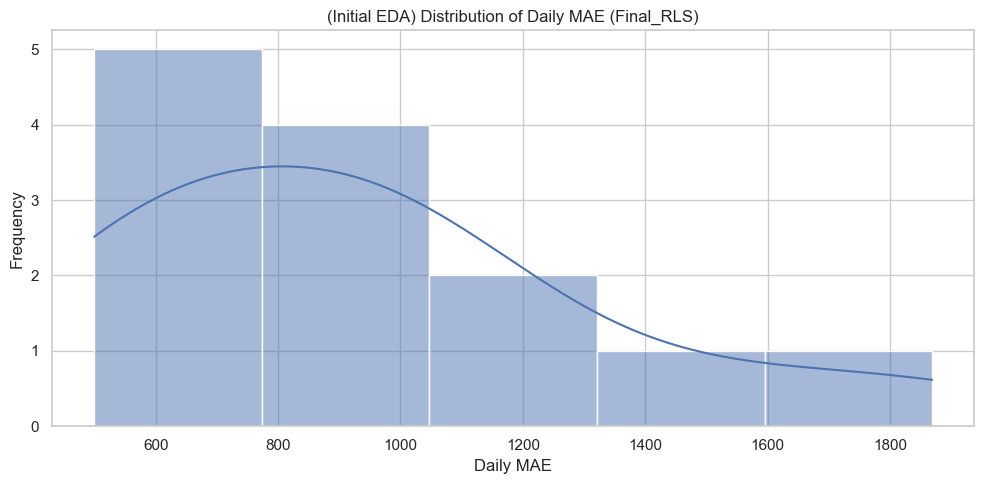

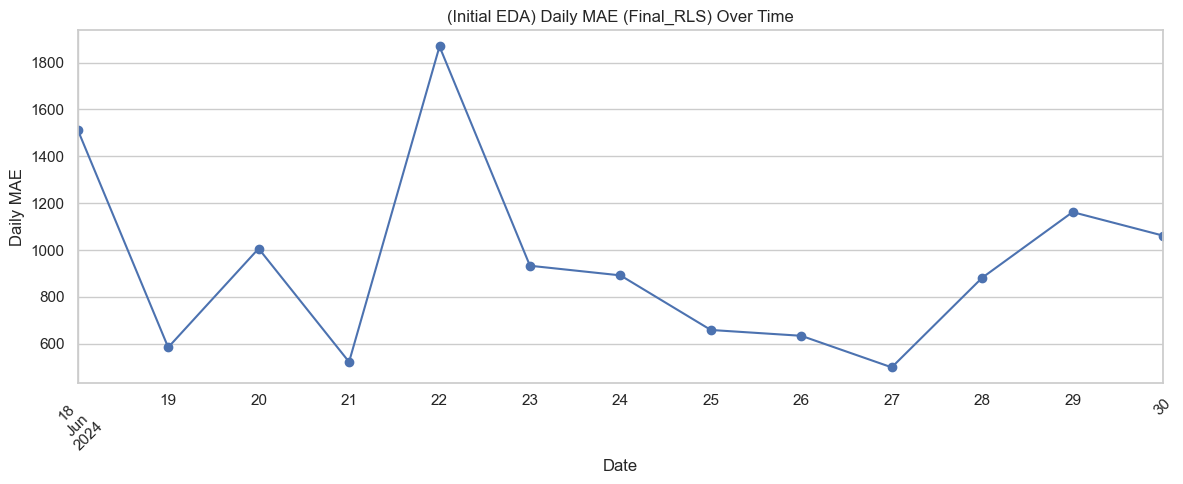


--- (Initial EDA) MAE Statistics ---
count      13.000000
mean      939.801231
std       401.392375
min       499.260000
25%       633.994000
50%       891.901333
75%      1061.549333
max      1868.972000
Name: Daily_MAE_Final_RLS, dtype: float64
Calculating aggregated mean features for correlation analysis...
Calculating and plotting correlation matrix (Mean Features)...


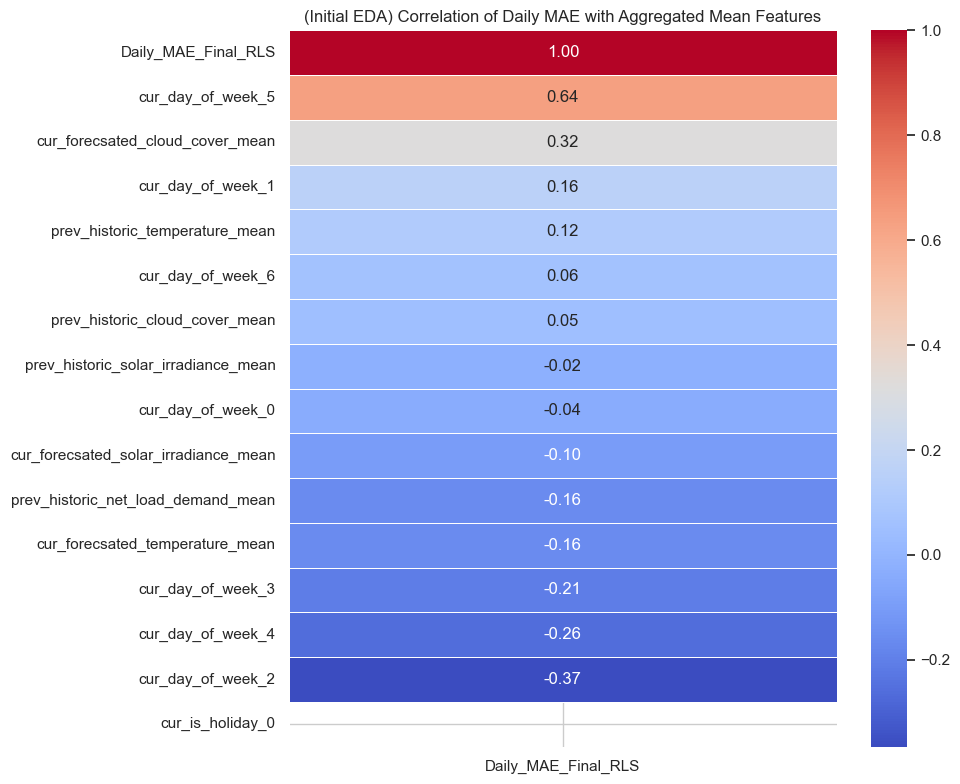


--- (Initial EDA) Correlation with Daily MAE (Mean Features) ---
Daily_MAE_Final_RLS                                    1.0
cur_day_of_week_5                                 0.636512
cur_forecsated_cloud_cover_mean                   0.319503
cur_day_of_week_1                                 0.161624
prev_historic_temperature_mean                    0.119204
cur_day_of_week_6                                 0.063539
prev_historic_cloud_cover_mean                      0.0457
prev_historic_solar_irradiance_mean              -0.023755
cur_day_of_week_0                                -0.035856
cur_forecsated_solar_irradiance_mean             -0.103582
prev_historic_net_load_demand_mean               -0.160582
cur_forecsated_temperature_mean                  -0.161009
cur_day_of_week_3                                -0.206819
cur_day_of_week_4                                -0.262873
cur_day_of_week_2                                -0.365502
cur_is_holiday_0                        N/A (No V

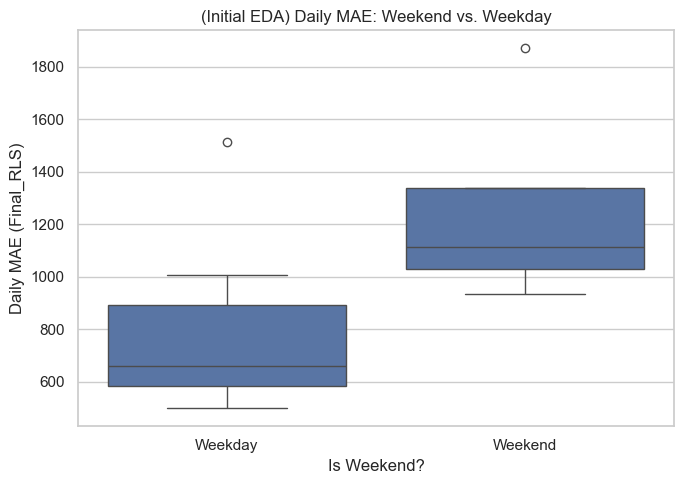

Skipping scatter plots of MAE vs Mean Features for brevity in this combined script.

--- Starting Hourly Error Analysis ---
Cannot segment hourly MAE by weekend/weekday (Is_Weekend flag missing or has only one value).


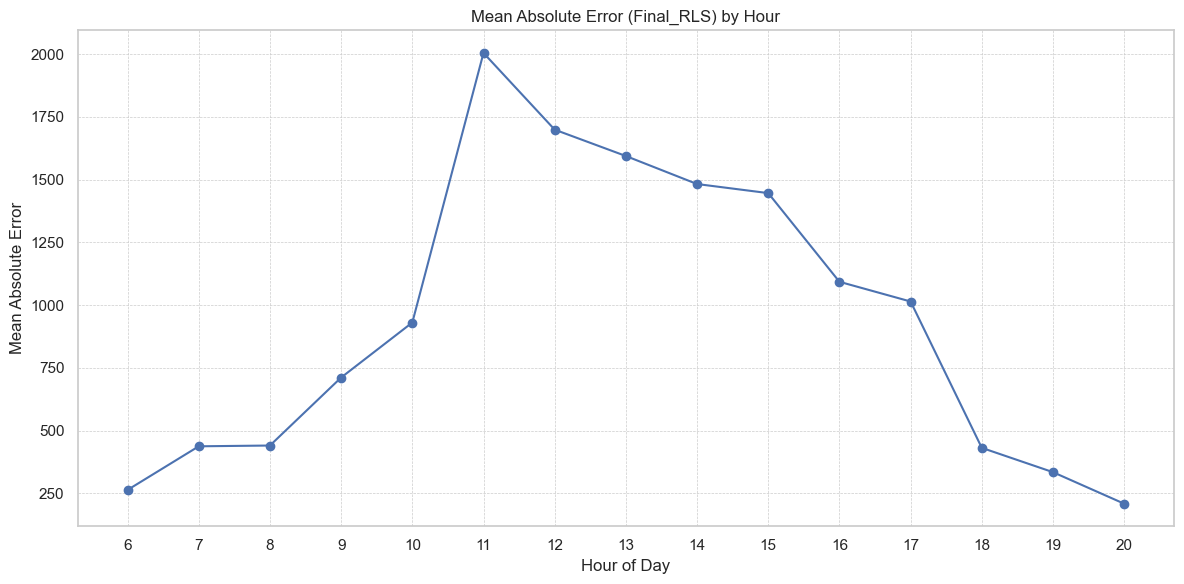


Hourly MAE (Overall):
hour
6      263.947692
7      437.764615
8      440.833846
9      711.796923
10     930.933077
11    2005.150769
12    1699.481538
13    1594.460000
14    1482.803077
15    1446.644615
16    1093.286923
17    1014.657692
18     431.542308
19     334.716923
20     208.998462
Name: AbsError_Final_RLS, dtype: float64

--- Starting Feature Variability Analysis ---
Calculated STD for: cur_forecsated_temperature
Calculated STD for: cur_forecsated_solar_irradiance
Calculated STD for: cur_forecsated_cloud_cover

Calculating and plotting correlation matrix (Variability Features)...


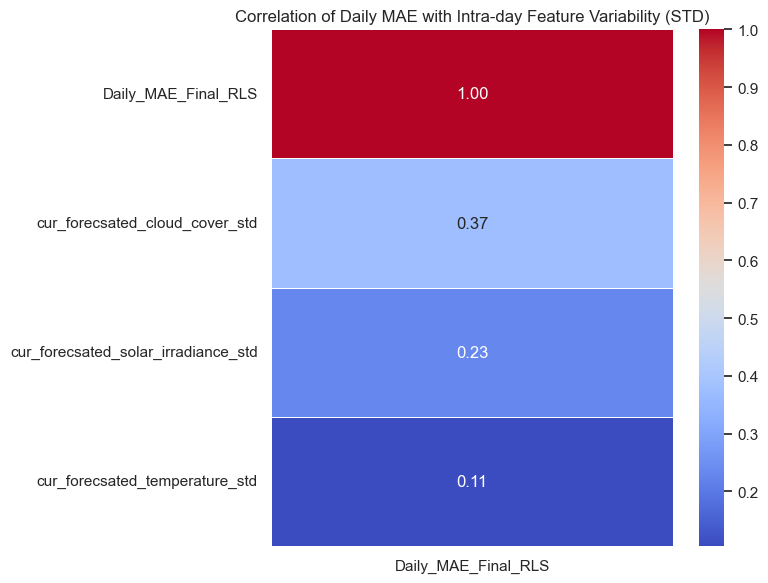


--- Correlation with Daily MAE (Variability Features) ---
Daily_MAE_Final_RLS                    1.000000
cur_forecsated_cloud_cover_std         0.372978
cur_forecsated_solar_irradiance_std    0.230721
cur_forecsated_temperature_std         0.106144
Name: Daily_MAE_Final_RLS, dtype: float64
Generating scatter plots: MAE vs. Feature Variability...


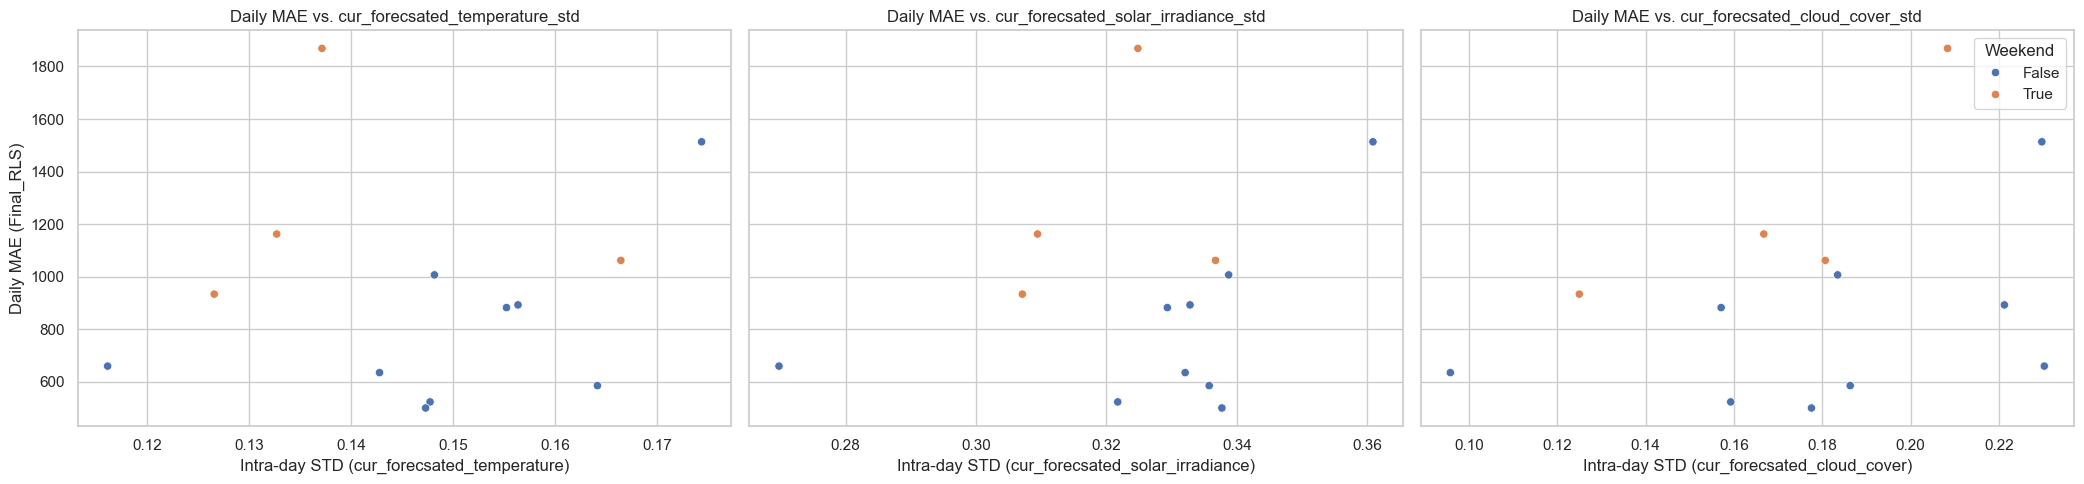


--- Full Analysis Complete ---


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore simple warnings if any occur during plotting or calculations
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning) # Often from seaborn plots

print("--- Starting Full Analysis ---")

# --- 1. Load Data ---
print("Loading data...")
try:
    # Define file paths (using the names provided in the prompt)
    results_path = "./../Results/Daytime/Arch_Hall_ST2B13_Validation_Results.csv"
    inputs_path = "./../Data/Clustering_Data/Daytime/Arch_Hall_ST2B13_X_Validation_Normalized.csv"

    # Load results data
    # Need to handle the first column name correctly
    df_results_raw = pd.read_csv(results_path)
    if df_results_raw.columns[0].startswith(','):
         df_results_raw.rename(columns={df_results_raw.columns[0]: df_results_raw.columns[0][1:]}, inplace=True)
    elif df_results_raw.columns[0] == 'Unnamed: 0':
         df_results_raw.rename(columns={df_results_raw.columns[0]: 'Timestamp'}, inplace=True)
    df_results = pd.read_csv(results_path, index_col=0, parse_dates=True)


    # Load input features data
    df_inputs = pd.read_csv(inputs_path, index_col=0, parse_dates=True) # Assuming 'date' is the first column

    print("Data loaded successfully.")
    print(f"Input features shape: {df_inputs.shape}")
    print(f"Results shape: {df_results.shape}")

except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print("Please ensure the file paths are correct relative to your script location.")
    # exit() # Exit if files are not found - Commented out for tool execution
    raise e # Raise error to stop execution in tool environment
except Exception as e:
    print(f"An error occurred during data loading: {e}")
    # exit() # Commented out for tool execution
    raise e # Raise error to stop execution in tool environment

# --- 2. Prepare Results Data ---
print("Preparing results data...")
# Calculate Absolute Error for Final_RLS
df_results['AbsError_Final_RLS'] = (df_results['Actual'] - df_results['Final_RLS']).abs()

# Extract date and hour for grouping
df_results['date_only'] = df_results.index.date
df_results['hour'] = df_results.index.hour

# Calculate daily MAE
daily_mae = df_results.groupby('date_only')['AbsError_Final_RLS'].mean().reset_index()
daily_mae.rename(columns={'AbsError_Final_RLS': 'Daily_MAE_Final_RLS', 'date_only': 'date'}, inplace=True)

# Convert the 'date' column in daily_mae back to datetime objects for merging
daily_mae['date'] = pd.to_datetime(daily_mae['date'])

print("Daily MAE calculated.")

# --- 3. Prepare Input Data ---
# Ensure the index of df_inputs is datetime (already done via parse_dates=True)

# --- 4. Merge Data ---
print("Merging daily MAE with input features...")
df_analysis = df_inputs.merge(daily_mae, left_index=True, right_on='date', how='inner')
df_analysis.set_index('date', inplace=True)
print("Merge complete. Analysis DataFrame shape:", df_analysis.shape)

# --- 5. Initial Exploratory Data Analysis (EDA) ---
print("Starting Initial EDA...")

# Set plotting style
sns.set(style="whitegrid")

# --- MAE Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(df_analysis['Daily_MAE_Final_RLS'], kde=True)
plt.title('(Initial EDA) Distribution of Daily MAE (Final_RLS)')
plt.xlabel('Daily MAE')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# --- MAE Over Time ---
plt.figure(figsize=(12, 5))
df_analysis['Daily_MAE_Final_RLS'].plot(marker='o', linestyle='-')
plt.title('(Initial EDA) Daily MAE (Final_RLS) Over Time')
plt.xlabel('Date')
plt.ylabel('Daily MAE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- MAE Statistics ---
print("\n--- (Initial EDA) MAE Statistics ---")
print(df_analysis['Daily_MAE_Final_RLS'].describe())

# --- Feature Engineering for Correlation (Mean Features) ---
print("Calculating aggregated mean features for correlation analysis...")
feature_prefixes_mean = [
    'prev_historic_net_load_demand',
    'prev_historic_temperature',
    'cur_forecsated_temperature',
    'prev_historic_solar_irradiance',
    'cur_forecsated_solar_irradiance',
    'prev_historic_cloud_cover',
    'cur_forecsated_cloud_cover'
]
mean_feature_cols = []
for prefix in feature_prefixes_mean:
    cols = [col for col in df_analysis.columns if col.startswith(prefix) and not col.endswith('_mean') and not col.endswith('_std')]
    if cols:
        mean_col_name = f'{prefix}_mean'
        df_analysis[mean_col_name] = df_analysis[cols].mean(axis=1)
        mean_feature_cols.append(mean_col_name)
    else:
        print(f"Warning: No columns found for mean prefix '{prefix}'")

# Identify day of week and holiday columns
dow_cols = [col for col in df_analysis.columns if col.startswith('cur_day_of_week_')]
holiday_col = 'cur_is_holiday_0'
correlation_cols_mean = ['Daily_MAE_Final_RLS'] + mean_feature_cols + dow_cols
if holiday_col in df_analysis.columns:
    correlation_cols_mean.append(holiday_col)

valid_correlation_cols_mean = [col for col in correlation_cols_mean if col in df_analysis.columns]
df_corr_mean = df_analysis[valid_correlation_cols_mean]

# --- Correlation Analysis (Mean Features) ---
print("Calculating and plotting correlation matrix (Mean Features)...")
correlation_matrix_mean = df_corr_mean.corr()
plt.figure(figsize=(10, 8))
if 'Daily_MAE_Final_RLS' in correlation_matrix_mean.columns:
    sns.heatmap(correlation_matrix_mean[['Daily_MAE_Final_RLS']].sort_values(by='Daily_MAE_Final_RLS', ascending=False), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=True)
    plt.title('(Initial EDA) Correlation of Daily MAE with Aggregated Mean Features')
    plt.tight_layout()
    plt.show()
    print("\n--- (Initial EDA) Correlation with Daily MAE (Mean Features) ---")
    # Handle potential NaN in holiday correlation if it exists
    print(correlation_matrix_mean['Daily_MAE_Final_RLS'].sort_values(ascending=False).fillna('N/A (No Variation)'))
else:
    print("Warning: 'Daily_MAE_Final_RLS' not found in mean correlation matrix.")


# --- Weekend vs. Weekday Analysis ---
print("Analyzing Weekend vs. Weekday performance...")
if 'cur_day_of_week_5' in df_analysis.columns and 'cur_day_of_week_6' in df_analysis.columns:
    df_analysis['Is_Weekend'] = (df_analysis['cur_day_of_week_5'] == 1) | (df_analysis['cur_day_of_week_6'] == 1)
    # Add Is_Weekend flag to df_results for hourly analysis
    # Ensure index alignment before merge
    df_results_temp = df_results.reset_index()
    df_results_temp['date_only'] = pd.to_datetime(df_results_temp['date_only']) # Ensure date type match
    df_analysis_temp = df_analysis.reset_index()

    df_results_merged = pd.merge(df_results_temp, df_analysis_temp[['date', 'Is_Weekend']], left_on='date_only', right_on='date', how='left')
    df_results_merged.set_index('date', inplace=True) # Restore original index
    # print(df_results_merged.head())
    # df_results = df_results_merged.drop(columns=['date']) # Remove duplicate date column

    plt.figure(figsize=(7, 5))
    sns.boxplot(x='Is_Weekend', y='Daily_MAE_Final_RLS', data=df_analysis)
    plt.title('(Initial EDA) Daily MAE: Weekend vs. Weekday')
    plt.xlabel('Is Weekend?')
    plt.ylabel('Daily MAE (Final_RLS)')
    plt.xticks([0, 1], ['Weekday', 'Weekend'])
    plt.tight_layout()
    plt.show()
else:
    print("Warning: Day of week columns not found. Skipping Weekend/Weekday plot and hourly separation.")
    df_analysis['Is_Weekend'] = False # Set default if DOW cols missing
    df_results['Is_Weekend'] = False # Set default if DOW cols missing


# --- Scatter Plots (Mean Features) ---
# (Skipping regenerating these plots here for brevity, code is in previous response if needed)
print("Skipping scatter plots of MAE vs Mean Features for brevity in this combined script.")


# --- 6. Hourly Error Analysis ---
print("\n--- Starting Hourly Error Analysis ---")

# Calculate MAE per hour
hourly_mae = df_results.groupby('hour')['AbsError_Final_RLS'].mean()

# Calculate MAE per hour, separated by weekday/weekend
if 'Is_Weekend' in df_results.columns and df_results['Is_Weekend'].nunique() > 1:
    hourly_mae_segmented = df_results.groupby(['hour', 'Is_Weekend'])['AbsError_Final_RLS'].mean().unstack()
    hourly_mae_segmented.rename(columns={False: 'Weekday', True: 'Weekend'}, inplace=True)
    plot_segmented = True
else:
    print("Cannot segment hourly MAE by weekend/weekday (Is_Weekend flag missing or has only one value).")
    plot_segmented = False

# Plotting Hourly MAE
plt.figure(figsize=(12, 6))
if plot_segmented:
    hourly_mae_segmented.plot(kind='line', marker='o', ax=plt.gca())
    plt.title('Mean Absolute Error (Final_RLS) by Hour (Weekday vs. Weekend)')
else:
    hourly_mae.plot(kind='line', marker='o', ax=plt.gca())
    plt.title('Mean Absolute Error (Final_RLS) by Hour')

plt.xlabel('Hour of Day')
plt.ylabel('Mean Absolute Error')
plt.xticks(hourly_mae.index) # Ensure all hours are shown
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
if plot_segmented:
    plt.legend(title='Day Type')
else:
    # Check if legend exists before trying to remove it
     if plt.gca().get_legend() is not None:
        plt.gca().get_legend().remove()
plt.tight_layout()
plt.show()

print("\nHourly MAE (Overall):")
print(hourly_mae)
if plot_segmented:
    print("\nHourly MAE (Segmented by Weekend):")
    print(hourly_mae_segmented)


# --- 7. Feature Variability Analysis ---
print("\n--- Starting Feature Variability Analysis ---")

# Calculate standard deviation for key forecasted features
feature_prefixes_std = [
    'cur_forecsated_temperature',
    'cur_forecsated_solar_irradiance',
    'cur_forecsated_cloud_cover'
    # Add others if needed, e.g., 'prev_historic_...'
]
std_feature_cols = []
for prefix in feature_prefixes_std:
    # Select the 15 hourly columns for the current prefix
    cols = [col for col in df_analysis.columns if col.startswith(prefix) and f'{prefix}_' in col and not col.endswith('_mean') and not col.endswith('_std')]
    if len(cols) == 15: # Ensure we have the 15 hourly values
        std_col_name = f'{prefix}_std'
        df_analysis[std_col_name] = df_analysis[cols].std(axis=1)
        std_feature_cols.append(std_col_name)
        print(f"Calculated STD for: {prefix}")
    else:
        print(f"Warning: Could not find 15 columns for STD prefix '{prefix}'. Found {len(cols)} columns.")
        # print(f"Columns found: {cols}") # Optional: print found columns for debugging


# Correlation Analysis (Variability Features)
if std_feature_cols: # Proceed only if STD features were calculated
    correlation_cols_std = ['Daily_MAE_Final_RLS'] + std_feature_cols
    df_corr_std = df_analysis[correlation_cols_std]
    correlation_matrix_std = df_corr_std.corr()

    print("\nCalculating and plotting correlation matrix (Variability Features)...")
    plt.figure(figsize=(8, 6))
    if 'Daily_MAE_Final_RLS' in correlation_matrix_std.columns:
        sns.heatmap(correlation_matrix_std[['Daily_MAE_Final_RLS']].sort_values(by='Daily_MAE_Final_RLS', ascending=False), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=True)
        plt.title('Correlation of Daily MAE with Intra-day Feature Variability (STD)')
        plt.tight_layout()
        plt.show()
        print("\n--- Correlation with Daily MAE (Variability Features) ---")
        print(correlation_matrix_std['Daily_MAE_Final_RLS'].sort_values(ascending=False))
    else:
        print("Warning: 'Daily_MAE_Final_RLS' not found in variability correlation matrix.")

    # Scatter Plots (Variability Features)
    print("Generating scatter plots: MAE vs. Feature Variability...")
    num_std_features = len(std_feature_cols)
    if num_std_features > 0:
        fig_std, axes_std = plt.subplots(1, num_std_features, figsize=(7 * num_std_features, 5), sharey=True)
        if num_std_features == 1: # Handle case where only one subplot exists
            axes_std = [axes_std]

        for i, std_col in enumerate(std_feature_cols):
            sns.scatterplot(ax=axes_std[i], x=std_col, y='Daily_MAE_Final_RLS', data=df_analysis, hue='Is_Weekend')
            axes_std[i].set_title(f'Daily MAE vs. {std_col}')
            axes_std[i].set_xlabel(f'Intra-day STD ({std_col.replace("_std","")})')
            axes_std[i].set_ylabel('Daily MAE (Final_RLS)')
            # Only show legend on the last plot for clarity if multiple plots
            if i == num_std_features - 1:
                 axes_std[i].legend(title='Weekend')
            else:
                 if axes_std[i].get_legend() is not None:
                     axes_std[i].get_legend().remove()


        plt.tight_layout()
        plt.show()

else:
    print("Skipping Variability Feature Correlation and Plots as no STD features were calculated.")


print("\n--- Full Analysis Complete ---")

--- Starting Analysis ---
Analyzing Feeder: Arch_Hall_ST2B13
Using Results File: ..\Data\Clustering_Data\Daytime\Validation_Results\Arch_Hall_ST2B13_Validation_Results.csv
Using Input Features File: ..\Data\Clustering_Data\Daytime\Validation_Features\Arch_Hall_ST2B13_X_Validation_Normalized.csv
Models to Analyze: ['Final_RLS', 'LSTM_RLS', 'ANN_RLS', 'Benchmark']

--- Loading data ---
Data loaded successfully.
Input features shape: (13, 113)
Results shape: (195, 5)
Results Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Inputs Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

--- Preparing results data ---
Calculated AbsError_Final_RLS
Calculated AbsError_LSTM_RLS
Calculated AbsError_ANN_RLS
Calculated AbsError_Benchmark
Calculating daily MAE for each model...
Calculated Daily MAE for Final_RLS:
        date  Daily_MAE_Final_RLS
0 2024-06-18          1513.126667
1 2024-06-19           584.474667
2 2024-06-20          1006.241333
Calculated Daily MAE fo

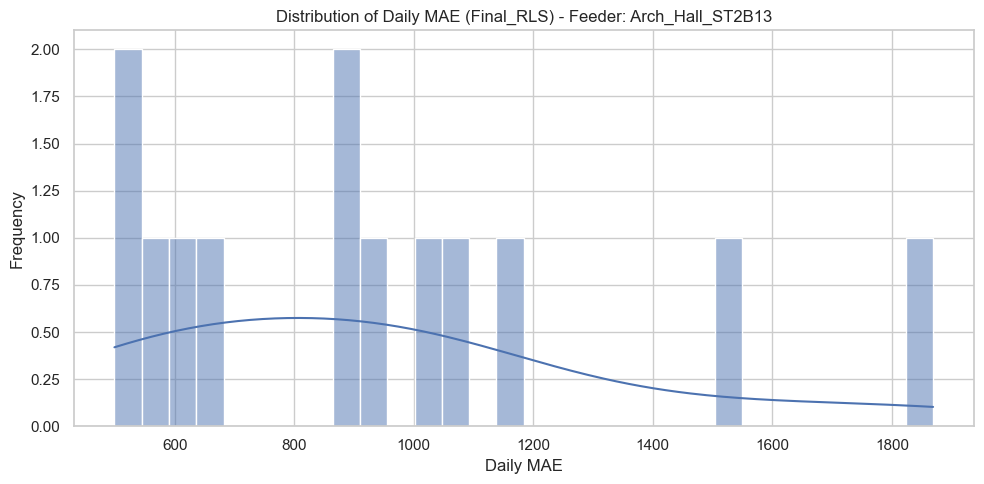

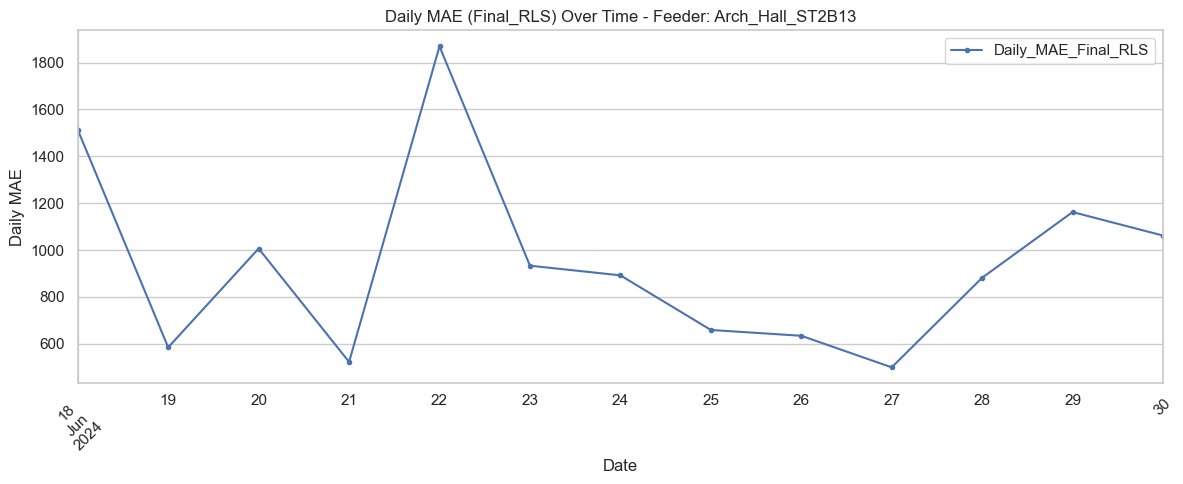


--- MAE Statistics (Final_RLS) ---
count      13.000000
mean      939.801231
std       401.392375
min       499.260000
25%       633.994000
50%       891.901333
75%      1061.549333
max      1868.972000
Name: Daily_MAE_Final_RLS, dtype: float64

--- Correlation Analysis (Final_RLS) ---

--- Correlation: MAE (Final_RLS) vs. Time Features ---
                  Daily_MAE_Final_RLS
cur_day_of_week_5            0.636512
Is_Weekend                   0.547255
cur_day_of_week_1            0.161624
cur_day_of_week_6            0.063539
cur_day_of_week_0           -0.035856
cur_day_of_week_3           -0.206819
cur_day_of_week_4           -0.262873
cur_day_of_week_2           -0.365502
cur_is_holiday_0                  N/A

--- Correlation: MAE (Final_RLS) vs. Weather Features ---
                                     Daily_MAE_Final_RLS
prev_historic_temperature_mean                  0.117282
prev_historic_cloud_cover_mean                  0.045700
prev_historic_solar_irradiance_mean           

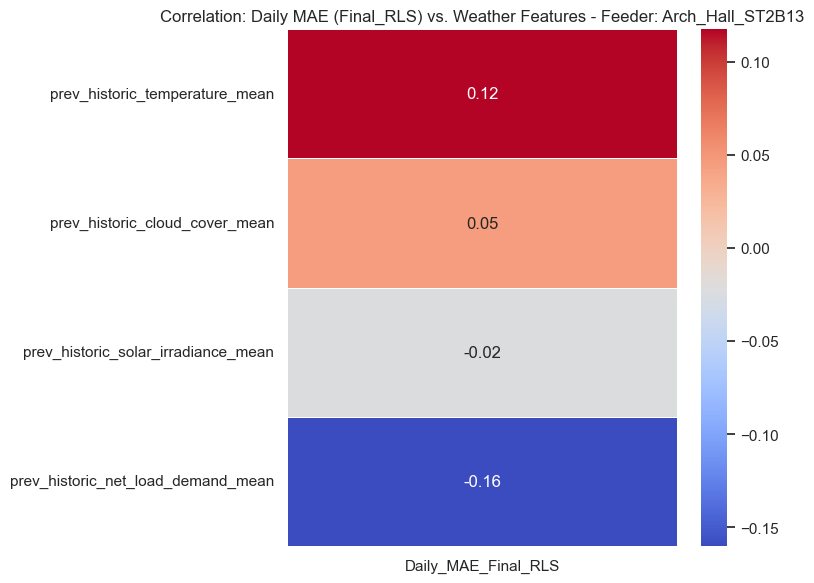


==================== Analyzing Model: LSTM_RLS ====================


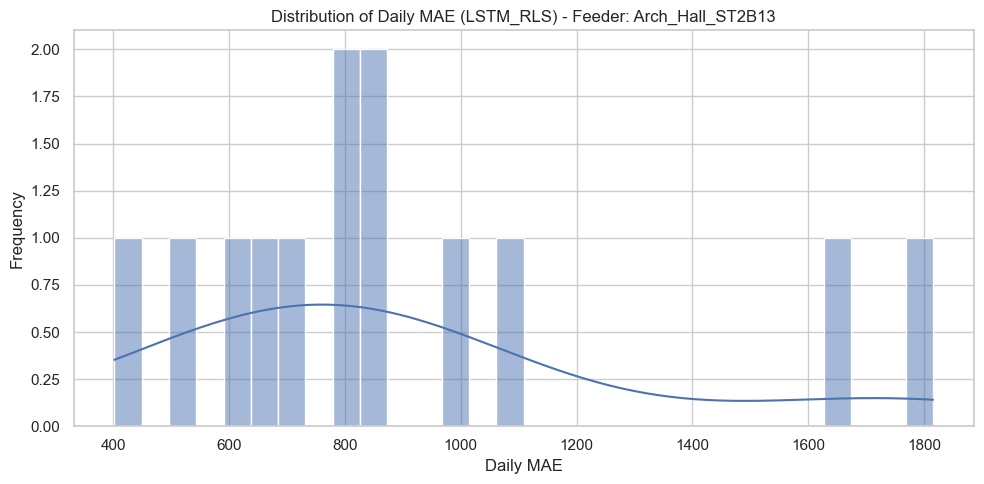

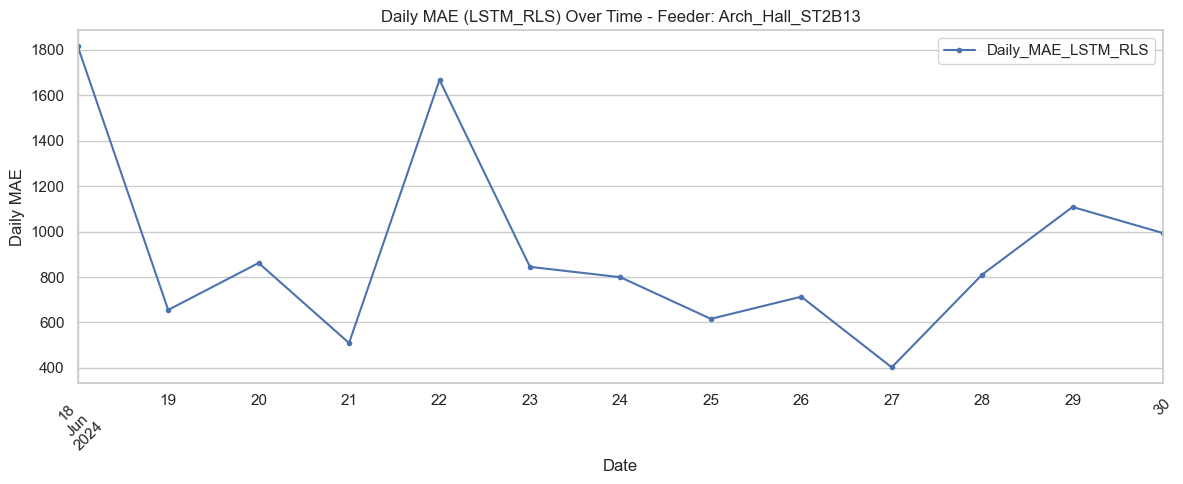


--- MAE Statistics (LSTM_RLS) ---
count      13.000000
mean      907.502000
std       416.162705
min       402.214000
25%       655.023333
50%       810.732667
75%       993.402667
max      1815.594667
Name: Daily_MAE_LSTM_RLS, dtype: float64

--- Correlation Analysis (LSTM_RLS) ---

--- Correlation: MAE (LSTM_RLS) vs. Time Features ---
                  Daily_MAE_LSTM_RLS
cur_day_of_week_5           0.512666
Is_Weekend                  0.410428
cur_day_of_week_1            0.32865
cur_day_of_week_6           0.012356
cur_day_of_week_0          -0.078244
cur_day_of_week_2          -0.238166
cur_day_of_week_4          -0.263953
cur_day_of_week_3          -0.293766
cur_is_holiday_0                 N/A

--- Correlation: MAE (LSTM_RLS) vs. Weather Features ---
                                     Daily_MAE_LSTM_RLS
prev_historic_cloud_cover_mean                 0.136790
prev_historic_net_load_demand_mean             0.030593
prev_historic_solar_irradiance_mean            0.015215
prev_his

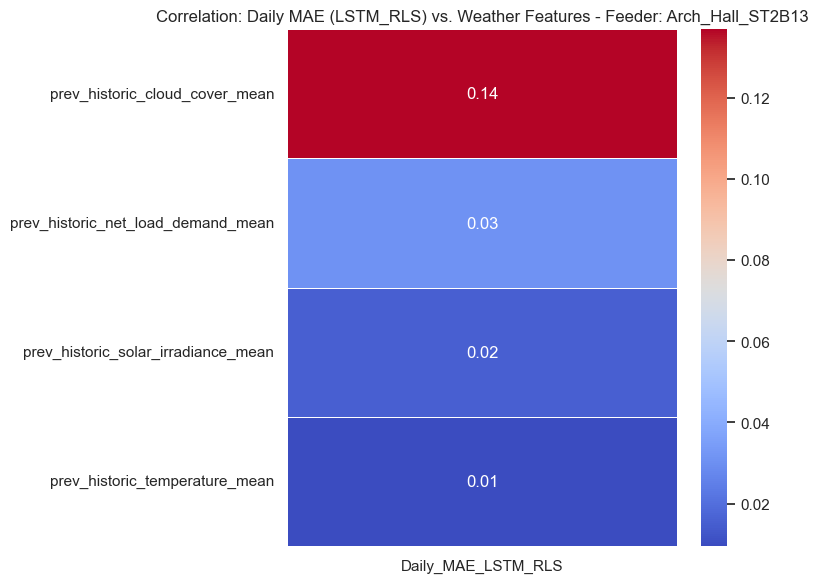


==================== Analyzing Model: ANN_RLS ====================


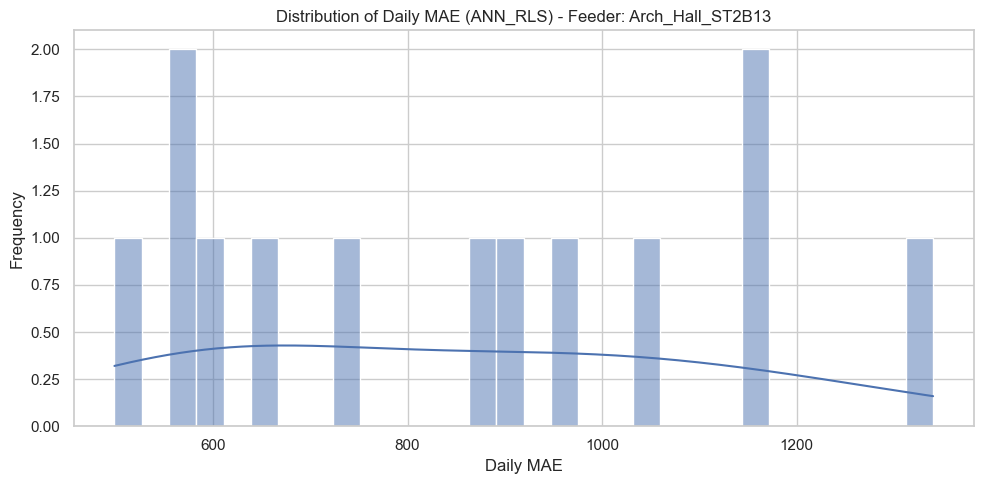

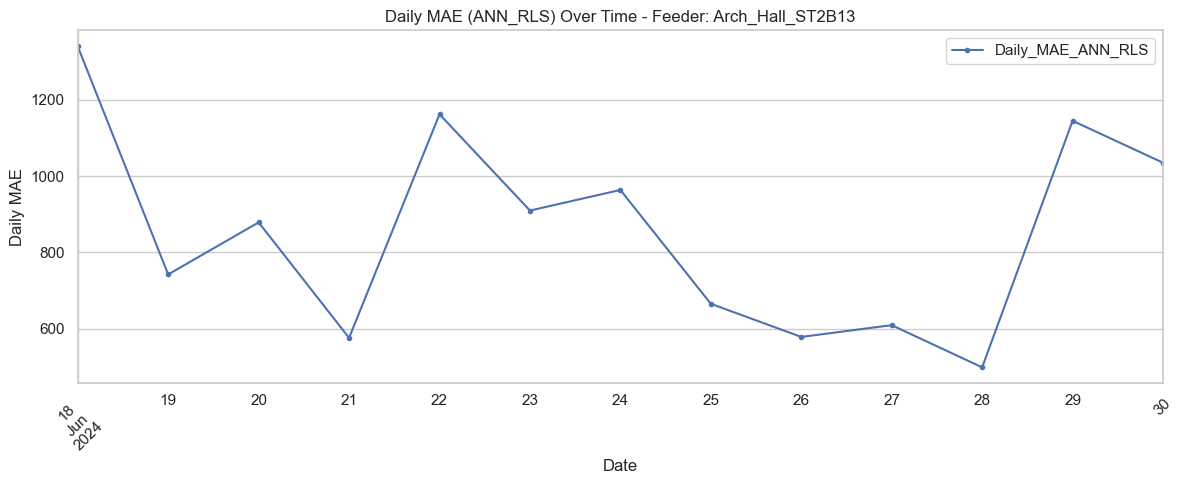


--- MAE Statistics (ANN_RLS) ---
count      13.000000
mean      854.244000
std       266.563237
min       498.590667
25%       609.246000
50%       878.790667
75%      1035.222667
max      1340.391333
Name: Daily_MAE_ANN_RLS, dtype: float64

--- Correlation Analysis (ANN_RLS) ---

--- Correlation: MAE (ANN_RLS) vs. Time Features ---
                  Daily_MAE_ANN_RLS
Is_Weekend                 0.543764
cur_day_of_week_5          0.498639
cur_day_of_week_1          0.247389
cur_day_of_week_6          0.196947
cur_day_of_week_0          0.123489
cur_day_of_week_3         -0.183519
cur_day_of_week_2         -0.322883
cur_day_of_week_4         -0.527775
cur_is_holiday_0                N/A

--- Correlation: MAE (ANN_RLS) vs. Weather Features ---
                                     Daily_MAE_ANN_RLS
prev_historic_cloud_cover_mean                0.435983
prev_historic_net_load_demand_mean           -0.025181
prev_historic_temperature_mean               -0.131218
prev_historic_solar_irradia

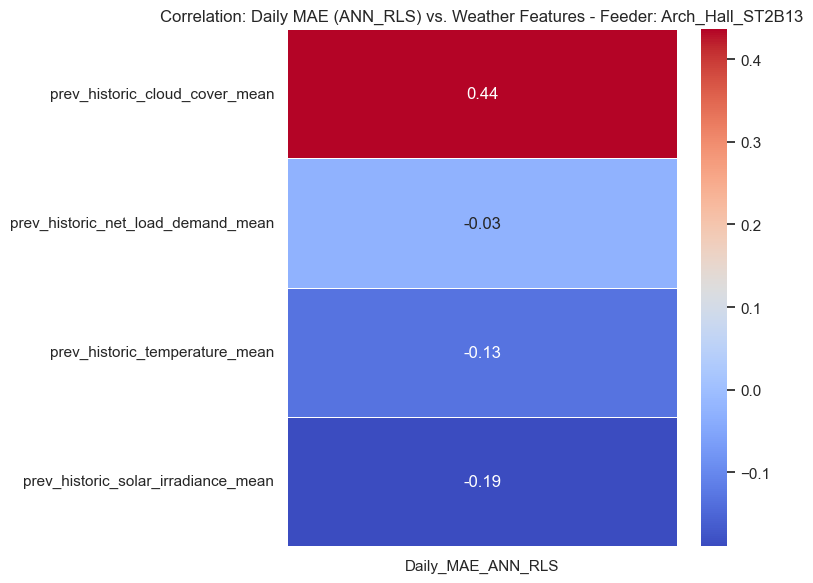


==================== Analyzing Model: Benchmark ====================


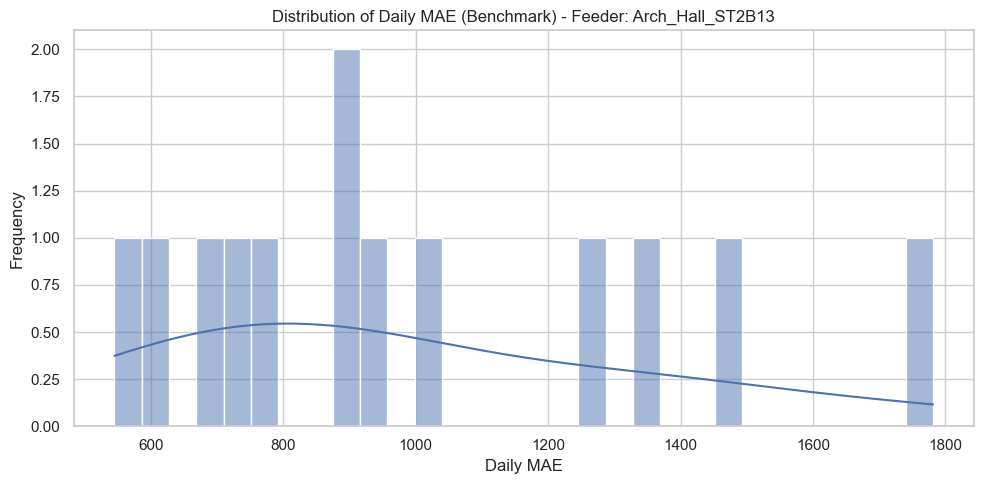

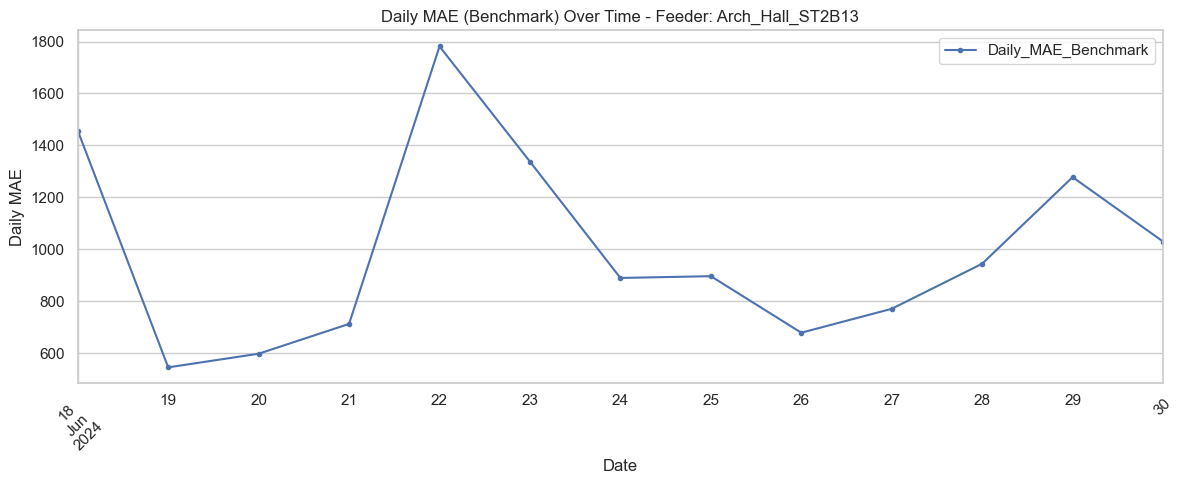


--- MAE Statistics (Benchmark) ---
count      13.000000
mean      993.603026
std       370.268515
min       544.954667
25%       712.300667
50%       896.248000
75%      1277.650000
max      1781.435333
Name: Daily_MAE_Benchmark, dtype: float64

--- Correlation Analysis (Benchmark) ---

--- Correlation: MAE (Benchmark) vs. Time Features ---
                  Daily_MAE_Benchmark
Is_Weekend                    0.68023
cur_day_of_week_5             0.64239
cur_day_of_week_6            0.227764
cur_day_of_week_1            0.219506
cur_day_of_week_0           -0.084628
cur_day_of_week_4           -0.198222
cur_day_of_week_3           -0.371151
cur_day_of_week_2           -0.457784
cur_is_holiday_0                  N/A

--- Correlation: MAE (Benchmark) vs. Weather Features ---
                                     Daily_MAE_Benchmark
prev_historic_cloud_cover_mean                  0.059138
prev_historic_temperature_mean                 -0.090179
prev_historic_solar_irradiance_mean           

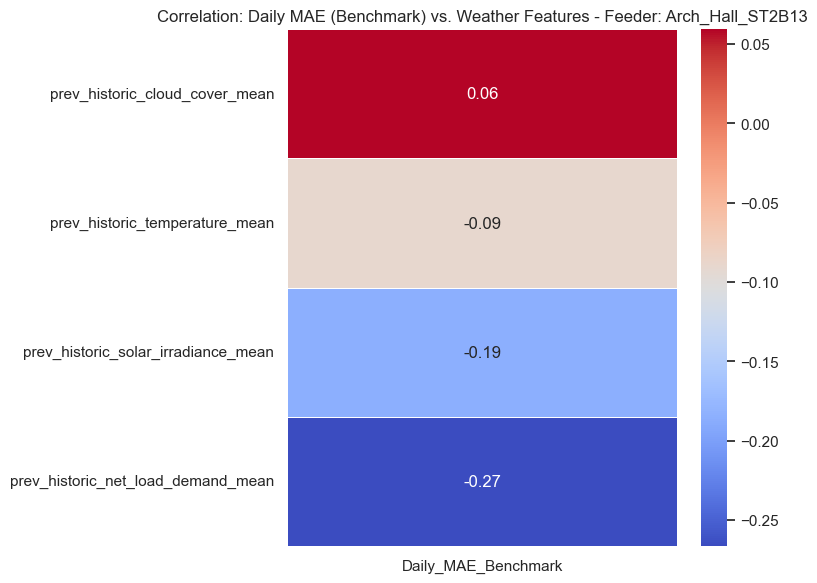


==================== Combined Correlation Table (Features vs. Daily MAE) ====================
                                    Final_RLS LSTM_RLS ANN_RLS Benchmark
cur_day_of_week_5                       0.637    0.513   0.499     0.642
Is_Weekend                              0.547     0.41   0.544      0.68
cur_day_of_week_2                      -0.366   -0.238  -0.323    -0.458
cur_day_of_week_4                      -0.263   -0.264  -0.528    -0.198
cur_day_of_week_3                      -0.207   -0.294  -0.184    -0.371
cur_day_of_week_1                       0.162    0.329   0.247      0.22
prev_historic_net_load_demand_mean      -0.16    0.031  -0.025    -0.266
prev_historic_temperature_mean          0.117     0.01  -0.131     -0.09
cur_day_of_week_6                       0.064    0.012   0.197     0.228
prev_historic_cloud_cover_mean          0.046    0.137   0.436     0.059
cur_day_of_week_0                      -0.036   -0.078   0.123    -0.085
prev_historic_solar_irradianc

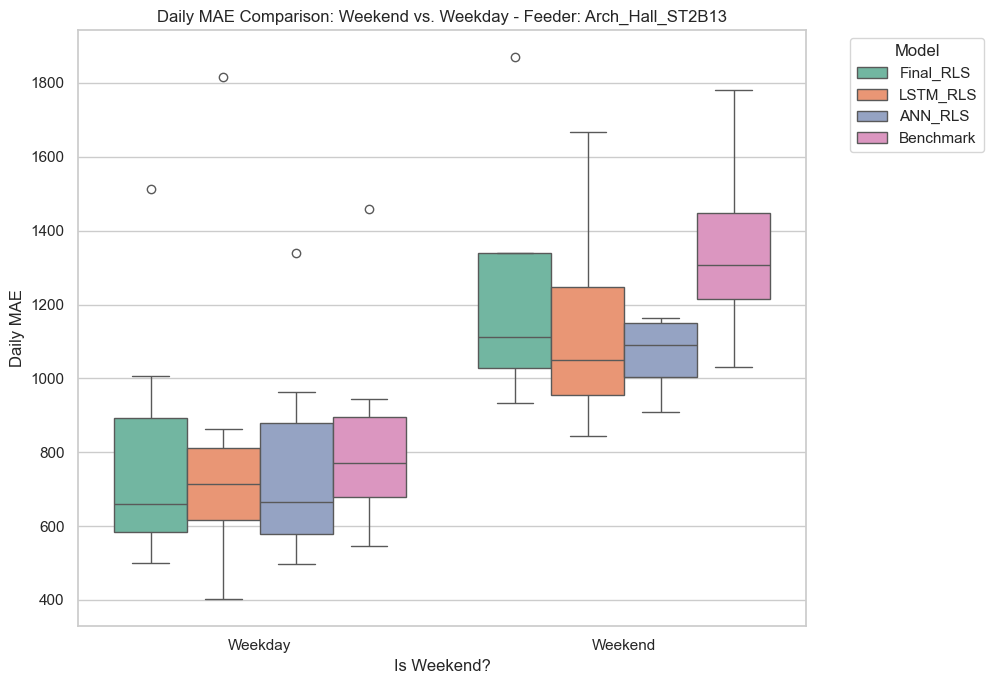


--- Analysis Complete ---


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path # Used for easier path handling

# Ignore simple warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning) # Ignore runtime warnings for correlation

print("--- Starting Analysis ---")

# --- 0. Configuration ---
# Define file paths (MODIFY THESE FOR DIFFERENT FEEDERS/DATASETS)
base_data_path = Path("./../Data/Clustering_Data/Daytime/Validation_Features/")
# *** Ensure this path is correct for your setup ***
base_results_path = Path("./../Data/Clustering_Data/Daytime/Validation_Results/")
feeder_name = "Arch_Hall_ST2B13" # Example feeder name

# Use Path objects and the / operator for joining paths
results_path = base_results_path / f"{feeder_name}_Validation_Results.csv"
inputs_path = base_data_path / f"{feeder_name}_X_Validation_Normalized.csv"

# Define the models present in the results file that you want to analyze
models_to_analyze = ["Final_RLS", "LSTM_RLS", "ANN_RLS", "Benchmark"]
actual_col_name = "Actual" # Name of the actual value column

print(f"Analyzing Feeder: {feeder_name}")
print(f"Using Results File: {results_path}")
print(f"Using Input Features File: {inputs_path}")
print(f"Models to Analyze: {models_to_analyze}")


# --- 1. Load Data ---
print("\n--- Loading data ---")
try:
    # Load results data
    df_results = pd.read_csv(results_path, index_col=0, parse_dates=True)

    # Load input features data
    df_inputs = pd.read_csv(inputs_path, index_col=0, parse_dates=True)

    # Ensure index has a name, important for merging later
    if df_results.index.name is None:
        df_results.index.name = "timestamp" # Or appropriate name
    if df_inputs.index.name is None:
        df_inputs.index.name = "timestamp"

    print("Data loaded successfully.")
    print(f"Input features shape: {df_inputs.shape}")
    print(f"Results shape: {df_results.shape}")
    print(f"Results Index Type: {type(df_results.index)}")
    print(f"Inputs Index Type: {type(df_inputs.index)}")


    # Basic check: Ensure all specified models and actual column exist in results
    required_cols = models_to_analyze + [actual_col_name]
    missing_cols = [col for col in required_cols if col not in df_results.columns]
    if missing_cols:
        print(f"Error: The following required columns are missing in {results_path}: {missing_cols}")
        exit()

except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print(f"Attempted to load: {results_path} and {inputs_path}")
    print("Please ensure the base paths, feeder name, and file naming convention are correct.")
    exit()
except Exception as e:
    print(f"An error occurred during data loading: {e}")
    exit()

# --- 2. Prepare Results Data ---
print("\n--- Preparing results data ---")
# Calculate Absolute Error for each specified model
for model_name in models_to_analyze:
    abs_error_col = f"AbsError_{model_name}"
    df_results[abs_error_col] = (df_results[actual_col_name] - df_results[model_name]).abs()
    print(f"Calculated {abs_error_col}")

# Extract date for grouping (index is already datetime)
df_results["date_only"] = df_results.index.date

# Calculate daily MAE for each model
daily_mae_dfs = {}
print("Calculating daily MAE for each model...")
for model_name in models_to_analyze:
    abs_error_col = f"AbsError_{model_name}"
    daily_mae_col = f"Daily_MAE_{model_name}"
    # Group by date and calculate mean absolute error
    numeric_cols = df_results.select_dtypes(include=np.number).columns
    if abs_error_col in numeric_cols:
        daily_mae = df_results.groupby("date_only")[abs_error_col].mean().reset_index()
        # Rename columns for clarity and merging
        daily_mae.rename(columns={abs_error_col: daily_mae_col, "date_only": "date"}, inplace=True)
        # Convert the 'date' column back to datetime objects for merging
        daily_mae["date"] = pd.to_datetime(daily_mae["date"])
        daily_mae_dfs[model_name] = daily_mae
        print(f"Calculated Daily MAE for {model_name}:")
        print(daily_mae.head(3))
    else:
         print(f"Warning: Column {abs_error_col} not found or not numeric for daily MAE calculation.")


# --- 3. Prepare Input Data ---
print("\n--- Input data preparation complete (index is datetime) ---")

# --- 4. Merge Data ---
print("\n--- Merging daily MAEs with input features ---")
# Start with the input features DataFrame, ensure index is date for merging
df_analysis = df_inputs.copy()
# Ensure the index is just the date part for merging with daily MAE
df_analysis.index = df_analysis.index.normalize()


# Merge the daily MAE for each model
merged_mae_df = None
for model_name in models_to_analyze:
    if model_name in daily_mae_dfs:
        daily_mae_col = f"Daily_MAE_{model_name}"
        print(f"Preparing to merge {daily_mae_col}...")
        current_mae_df = daily_mae_dfs[model_name].set_index("date")
        if merged_mae_df is None:
            merged_mae_df = current_mae_df
        else:
            merged_mae_df = merged_mae_df.join(current_mae_df, how="outer")
    else:
        print(f"Skipping merge for {model_name}, daily MAE data not found.")

# Now merge the combined MAE data with the input features
if merged_mae_df is not None:
    print("Joining input features with all daily MAEs...")
    df_analysis = df_analysis.join(merged_mae_df, how="inner")
    print("Merge complete.")
else:
    print("Error: No daily MAE data was successfully processed for merging.")
    exit()

# Drop rows where any MAE is NaN
mae_cols_to_check = [f"Daily_MAE_{m}" for m in models_to_analyze if f"Daily_MAE_{m}" in df_analysis.columns]
df_analysis.dropna(subset=mae_cols_to_check, inplace=True)


print("Final Analysis DataFrame shape:", df_analysis.shape)
if df_analysis.empty:
    print("Error: Analysis DataFrame is empty after merging. Check date alignment and data.")
    exit()

print("Analysis DataFrame head (MAE columns):")
mae_cols_to_show = [f"Daily_MAE_{m}" for m in models_to_analyze if f"Daily_MAE_{m}" in df_analysis.columns]
print(df_analysis[mae_cols_to_show].head())
print("Analysis DataFrame Index Type:", type(df_analysis.index))


# --- 5. Feature Engineering ---
print("\n--- Calculating aggregated features and time features ---")
# Calculate daily means for key features
feature_prefixes = [
    "prev_historic_net_load_demand",
    "prev_historic_temperature",
    "cur_forecsated_temperature",
    "prev_historic_solar_irradiance",
    "cur_forecsated_solar_irradiance",
    "prev_historic_cloud_cover",
    "cur_forecsated_cloud_cover",
]

weather_feature_means = []
for prefix in feature_prefixes:
    cols = [col for col in df_analysis.columns if col.startswith(prefix) and not col.endswith("_mean")]
    mean_col_name = f"{prefix}_mean"
    if cols:
        if mean_col_name not in df_analysis.columns:
             df_analysis[mean_col_name] = df_analysis[cols].mean(axis=1)
             print(f"Calculated {mean_col_name}")
             weather_feature_means.append(mean_col_name)
        else:
             print(f"Column {mean_col_name} already exists.")
             if mean_col_name not in weather_feature_means: weather_feature_means.append(mean_col_name)
    else:
        print(f"Warning: No columns found for prefix '{prefix}'")


# Identify day of week and holiday columns
dow_cols = sorted([col for col in df_analysis.columns if col.startswith("cur_day_of_week_")])
holiday_col = "cur_is_holiday_0"
holiday_col_exists = holiday_col in df_analysis.columns
if not holiday_col_exists:
    print(f"Warning: Holiday column '{holiday_col}' not found.")

# Add 'Is_Weekend' flag
dow_5_exists = "cur_day_of_week_5" in df_analysis.columns
dow_6_exists = "cur_day_of_week_6" in df_analysis.columns
weekend_analysis_possible = dow_5_exists and dow_6_exists

time_features = [] # Initialize list for time-based features
if weekend_analysis_possible:
    df_analysis["Is_Weekend"] = ((df_analysis["cur_day_of_week_5"] == 1) | (df_analysis["cur_day_of_week_6"] == 1)).astype(int)
    print("Created 'Is_Weekend' column.")
    time_features = dow_cols + ([holiday_col] if holiday_col_exists else []) + ["Is_Weekend"]
else:
    print("Warning: Day of week columns for Saturday/Sunday not found. Cannot create 'Is_Weekend'.")
    df_analysis["Is_Weekend"] = 0 # Add column as 0 if DOW cols missing
    time_features = dow_cols + ([holiday_col] if holiday_col_exists else [])

# Ensure only existing columns are included
time_features = [tf for tf in time_features if tf in df_analysis.columns]
weather_feature_means = [wf for wf in weather_feature_means if wf in df_analysis.columns]

print(f"Time features identified for correlation: {time_features}")
print(f"Weather features (means) identified for correlation: {weather_feature_means}")


# --- 6. Exploratory Data Analysis (EDA) for each model ---
print("\n--- Starting EDA and generating plots for each model ---")
sns.set(style="whitegrid")

# Store correlation results for the final table
all_correlation_results = {}

# Loop through each model to perform analysis
for model_name in models_to_analyze:
    print(f"\n{'='*20} Analyzing Model: {model_name} {'='*20}")
    mae_col = f"Daily_MAE_{model_name}"

    if mae_col not in df_analysis.columns:
        print(f"Warning: MAE column '{mae_col}' not found. Skipping analysis for {model_name}.")
        continue

    # --- MAE Distribution ---
    plt.figure(figsize=(10, 5))
    sns.histplot(df_analysis[mae_col], kde=True, bins=30)
    plt.title(f"Distribution of Daily MAE ({model_name}) - Feeder: {feeder_name}")
    plt.xlabel("Daily MAE")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # --- MAE Over Time ---
    plt.figure(figsize=(12, 5))
    df_analysis[mae_col].plot(marker=".", linestyle="-", legend=True)
    plt.title(f"Daily MAE ({model_name}) Over Time - Feeder: {feeder_name}")
    plt.xlabel("Date")
    plt.ylabel("Daily MAE")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # --- MAE Statistics ---
    print(f"\n--- MAE Statistics ({model_name}) ---")
    print(df_analysis[mae_col].describe())

    # --- Correlation Analysis (Separated) ---
    print(f"\n--- Correlation Analysis ({model_name}) ---")
    model_correlations = {} # Store correlations for this model

    # Correlation with Time Features
    print(f"\n--- Correlation: MAE ({model_name}) vs. Time Features ---")
    if time_features: # Check if list is not empty
        time_corr_cols = [mae_col] + time_features
        df_time_corr = df_analysis[time_corr_cols].copy()
        correlation_matrix_time = df_time_corr.corr()
        mae_corr_time = correlation_matrix_time[[mae_col]].drop(mae_col, axis=0).sort_values(by=mae_col, ascending=False)
        print(mae_corr_time.fillna("N/A"))
        model_correlations.update(mae_corr_time[mae_col].to_dict()) # Add time correlations to dict

        # Optional: Plot heatmap for time correlations
        # plt.figure(figsize=(8, max(6, len(time_features)*0.5))) # Adjust height
        # sns.heatmap(mae_corr_time, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)
        # plt.title(f"Correlation: Daily MAE ({model_name}) vs. Time Features")
        # plt.yticks(rotation=0)
        # plt.tight_layout()
        # plt.show()
    else:
        print("No time features available for correlation analysis.")

    # Correlation with Weather Features
    print(f"\n--- Correlation: MAE ({model_name}) vs. Weather Features ---")
    if weather_feature_means: # Check if list is not empty
        weather_corr_cols = [mae_col] + weather_feature_means
        df_weather_corr = df_analysis[weather_corr_cols].copy()
        correlation_matrix_weather = df_weather_corr.corr()
        mae_corr_weather = correlation_matrix_weather[[mae_col]].drop(mae_col, axis=0).sort_values(by=mae_col, ascending=False)
        print(mae_corr_weather.fillna("N/A"))
        model_correlations.update(mae_corr_weather[mae_col].to_dict()) # Add weather correlations to dict

        # Plot heatmap for weather correlations
        plt.figure(figsize=(8, max(6, len(weather_feature_means)*0.5))) # Adjust height
        sns.heatmap(mae_corr_weather, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)
        plt.title(f"Correlation: Daily MAE ({model_name}) vs. Weather Features - Feeder: {feeder_name}")
        plt.yticks(rotation=0) # Keep feature names horizontal
        plt.tight_layout()
        plt.show()
    else:
        print("No weather features available for correlation analysis.")

    # Store all correlations for this model for the final table
    all_correlation_results[model_name] = model_correlations


# --- 7. Combined Analysis Across Models ---

# --- Combined Correlation Table ---
print(f"\n{'='*20} Combined Correlation Table (Features vs. Daily MAE) {'='*20}")
if all_correlation_results:
    # Create DataFrame from the dictionary of dictionaries
    df_combined_corr = pd.DataFrame(all_correlation_results)

    # Optional: Sort rows by the average absolute correlation across models or by a specific model
    # Example: Sort by absolute correlation with the first model
    first_model = models_to_analyze[0]
    if first_model in df_combined_corr.columns:
         df_combined_corr = df_combined_corr.reindex(df_combined_corr[first_model].abs().sort_values(ascending=False).index)

    print(df_combined_corr.round(3).fillna("N/A")) # Print rounded correlation values
else:
    print("No correlation results were calculated.")

# --- Combined Weekend vs. Weekday Boxplot ---
print(f"\n{'='*20} Combined Weekend vs. Weekday Analysis {'='*20}")
if weekend_analysis_possible:
    # Prepare data for combined plot
    mae_cols = [f"Daily_MAE_{m}" for m in models_to_analyze if f"Daily_MAE_{m}" in df_analysis.columns]
    df_melted = df_analysis.reset_index()[['Is_Weekend'] + mae_cols].copy()

    # Rename MAE columns for better legend labels
    rename_dict = {mae_col: mae_col.replace('Daily_MAE_', '') for mae_col in mae_cols}
    df_melted.rename(columns=rename_dict, inplace=True)
    melted_mae_cols = list(rename_dict.values())

    # Melt the DataFrame
    df_melted = pd.melt(df_melted, id_vars=['Is_Weekend'], value_vars=melted_mae_cols,
                        var_name='Model', value_name='Daily MAE')

    # Create the combined boxplot
    plt.figure(figsize=(12, 7))
    sns.boxplot(x="Is_Weekend", y="Daily MAE", hue="Model", data=df_melted, palette="Set2")
    plt.title(f"Daily MAE Comparison: Weekend vs. Weekday - Feeder: {feeder_name}")
    plt.xlabel("Is Weekend?")
    plt.ylabel("Daily MAE")
    plt.xticks([0, 1], ["Weekday", "Weekend"])
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()
else:
    print("Skipping combined Weekend/Weekday plot as 'Is_Weekend' could not be determined.")


print("\n--- Analysis Complete ---")

<Axes: >

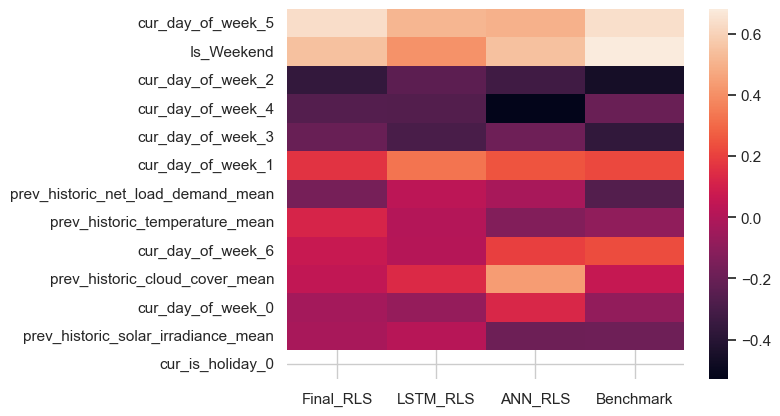

In [6]:
sns.heatmap(df_combined_corr)

--- Starting Analysis for Feeder: Ometa_Mall_MA2B4, Dataset: Test ---
Attempting to load Results: ..\Data\Clustering_Data\Daytime\Test_Results\Ometa_Mall_MA2B4_Test_Results.csv
Attempting to load Features: ..\Data\Clustering_Data\Daytime\Test_Features\Ometa_Mall_MA2B4_X_Test_Normalized.csv

--- Loading data ---
Data loaded successfully.
Input features shape: (29, 113)
Results shape: (435, 5)

--- Preparing results data (Calculating Daily MAE) ---

--- Merging daily MAEs with input features ---
Merge complete. Analysis DataFrame shape: (29, 117)

--- Feature Engineering ---
Created 'Is_Weekday' and 'Is_Weekend' columns.
Created 'Is_Holiday' column.
Time features for correlation: ['Is_Weekday', 'Is_Weekend']
Weather features for correlation: ['prev_historic_temperature_mean', 'prev_historic_solar_irradiance_mean', 'prev_historic_cloud_cover_mean', 'prev_historic_net_load_demand_mean']

--- Correlation Analysis ---

--- Analyzing Model: Final_RLS ---
Correlation: MAE (Final_RLS) vs. Time 

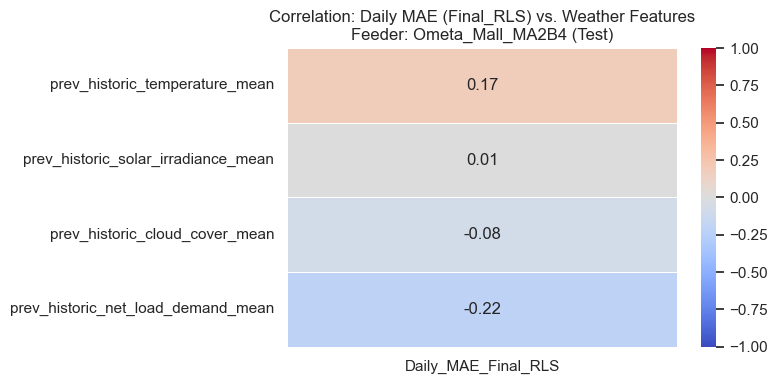


--- Analyzing Model: LSTM_RLS ---
Correlation: MAE (LSTM_RLS) vs. Time Features:
            Daily_MAE_LSTM_RLS
Is_Weekend               0.451
Is_Weekday              -0.451

Correlation: MAE (LSTM_RLS) vs. Weather Features:
                                     Daily_MAE_LSTM_RLS
prev_historic_temperature_mean                    0.234
prev_historic_solar_irradiance_mean               0.042
prev_historic_cloud_cover_mean                   -0.161
prev_historic_net_load_demand_mean               -0.319


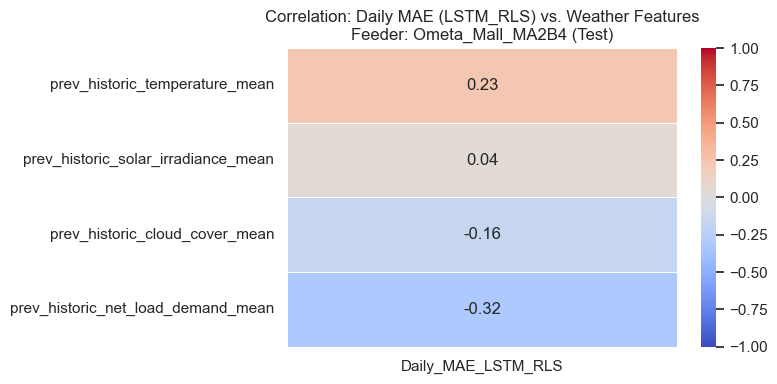


--- Analyzing Model: ANN_RLS ---
Correlation: MAE (ANN_RLS) vs. Time Features:
            Daily_MAE_ANN_RLS
Is_Weekend              0.358
Is_Weekday             -0.358

Correlation: MAE (ANN_RLS) vs. Weather Features:
                                     Daily_MAE_ANN_RLS
prev_historic_temperature_mean                   0.088
prev_historic_solar_irradiance_mean              0.050
prev_historic_cloud_cover_mean                  -0.166
prev_historic_net_load_demand_mean              -0.377


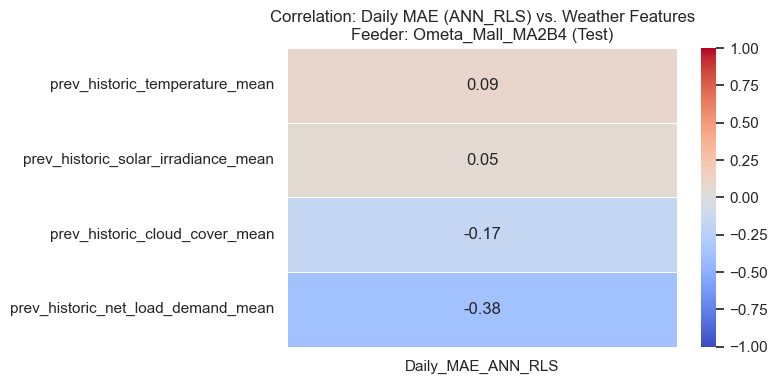


--- Analyzing Model: Benchmark ---
Correlation: MAE (Benchmark) vs. Time Features:
            Daily_MAE_Benchmark
Is_Weekend                0.139
Is_Weekday               -0.139

Correlation: MAE (Benchmark) vs. Weather Features:
                                     Daily_MAE_Benchmark
prev_historic_cloud_cover_mean                     0.023
prev_historic_temperature_mean                    -0.148
prev_historic_solar_irradiance_mean               -0.151
prev_historic_net_load_demand_mean                -0.613


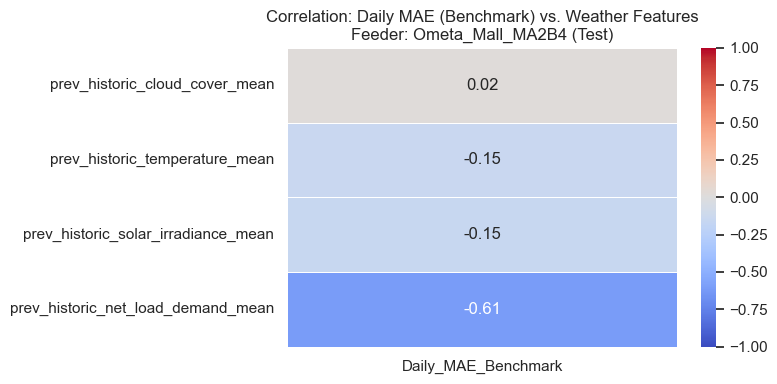


==================== Combined Correlation Table (Features vs. Daily MAE) ====================
                                     Final_RLS  LSTM_RLS  ANN_RLS  Benchmark
prev_historic_net_load_demand_mean      -0.217    -0.319   -0.377     -0.613
Is_Weekday                              -0.473    -0.451   -0.358     -0.139
Is_Weekend                               0.473     0.451    0.358      0.139
prev_historic_temperature_mean           0.173     0.234    0.088     -0.148
prev_historic_cloud_cover_mean          -0.083    -0.161   -0.166      0.023
prev_historic_solar_irradiance_mean      0.007     0.042    0.050     -0.151

==================== Combined Weekend vs. Weekday Analysis ====================


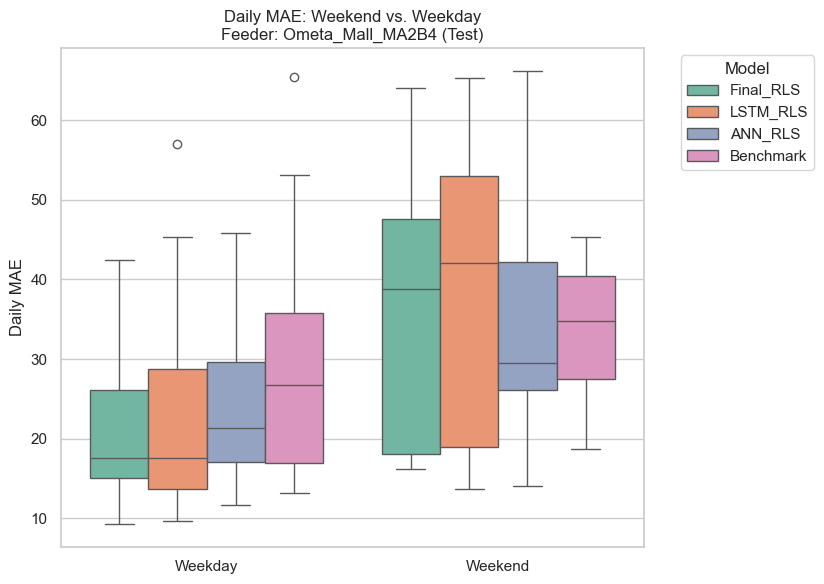


--- Analysis Complete for Feeder: Ometa_Mall_MA2B4, Dataset: Test ---

--- Accessing Results ---
Correlation Table Head:
                                    Final_RLS  LSTM_RLS   ANN_RLS  Benchmark
prev_historic_net_load_demand_mean  -0.216653 -0.318803 -0.377374  -0.613440
Is_Weekday                          -0.472664 -0.451271 -0.357573  -0.138906
Is_Weekend                           0.472664  0.451271  0.357573   0.138906
prev_historic_temperature_mean       0.173309  0.233923  0.088074  -0.148037
prev_historic_cloud_cover_mean      -0.083451 -0.161374 -0.165896   0.023390

Top 3 Negative Correlations for Final_RLS:
Is_Weekday                           -0.472664
prev_historic_net_load_demand_mean   -0.216653
prev_historic_cloud_cover_mean       -0.083451
Name: Final_RLS, dtype: float64

Top 3 Positive Correlations for Final_RLS:
prev_historic_solar_irradiance_mean    0.007104
prev_historic_temperature_mean         0.173309
Is_Weekend                             0.472664
Name: Final

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Ignore simple warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

# --- Define Base Paths (Adjust if your script is located elsewhere) ---
# Assuming the script is run from a directory level with 'Data' and 'Results' as subdirs
# Or adjust the relative path (e.g., Path(__file__).parent.parent / 'Data') if needed
BASE_PROJECT_PATH = Path("./../Data/Clustering_Data") # Path relative to the script location
DATA_PATH = BASE_PROJECT_PATH / "Daytime"
RESULTS_PATH = BASE_PROJECT_PATH / "Daytime" # Or wherever your results are

def analyze_feeder_correlations(
    feeder_name: str,
    dataset_type: str, # Should be "Validation" or "Test"
    models_to_analyze: list = ["Final_RLS", "LSTM_RLS", "ANN_RLS", "Benchmark"],
    actual_col_name: str = "Actual"
):
    """
    Analyzes correlations between Daily MAE of specified models and key features.

    Args:
        feeder_name (str): The name of the feeder (e.g., "Arch_Hall_ST2B13").
        dataset_type (str): The type of dataset ("Validation" or "Test").
        models_to_analyze (list): List of model column names in the results file.
        actual_col_name (str): Column name for the actual values in the results file.

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: The combined analysis dataframe with features and MAEs.
            - pd.DataFrame: The combined correlation table (Features vs. Daily MAE).
            Returns (None, None) if data loading or processing fails.
    """
    print(f"--- Starting Analysis for Feeder: {feeder_name}, Dataset: {dataset_type} ---")

    # --- 1. Construct Paths ---
    try:
        results_folder = RESULTS_PATH / f"{dataset_type}_Results"
        features_folder = DATA_PATH / f"{dataset_type}_Features" # Path corrected based on user info

        results_path = results_folder / f"{feeder_name}_{dataset_type}_Results.csv"
        inputs_path = features_folder / f"{feeder_name}_X_{dataset_type}_Normalized.csv"

        print(f"Attempting to load Results: {results_path}")
        print(f"Attempting to load Features: {inputs_path}")

        # Check if files exist before attempting to load
        if not results_path.is_file():
            print(f"Error: Results file not found at {results_path}")
            return None, None
        if not inputs_path.is_file():
            print(f"Error: Input features file not found at {inputs_path}")
            return None, None

    except Exception as e:
        print(f"Error constructing file paths: {e}")
        return None, None

    # --- 2. Load Data ---
    print("\n--- Loading data ---")
    try:
        df_results = pd.read_csv(results_path, index_col=0, parse_dates=True)
        df_inputs = pd.read_csv(inputs_path, index_col=0, parse_dates=True)

        if df_results.index.name is None: df_results.index.name = "timestamp"
        if df_inputs.index.name is None: df_inputs.index.name = "timestamp"

        print("Data loaded successfully.")
        print(f"Input features shape: {df_inputs.shape}")
        print(f"Results shape: {df_results.shape}")

        required_cols = models_to_analyze + [actual_col_name]
        missing_cols = [col for col in required_cols if col not in df_results.columns]
        if missing_cols:
            print(f"Error: Missing required columns in results file: {missing_cols}")
            return None, None

    except FileNotFoundError as e: # Should be caught by is_file() check, but keep as fallback
        print(f"Error loading files: {e}")
        return None, None
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return None, None

    # --- 3. Prepare Results Data (Calculate Daily MAE) ---
    print("\n--- Preparing results data (Calculating Daily MAE) ---")
    daily_mae_dfs = {}
    df_results["date_only"] = df_results.index.date
    for model_name in models_to_analyze:
        abs_error_col = f"AbsError_{model_name}"
        daily_mae_col = f"Daily_MAE_{model_name}"
        df_results[abs_error_col] = (df_results[actual_col_name] - df_results[model_name]).abs()

        numeric_cols = df_results.select_dtypes(include=np.number).columns
        if abs_error_col in numeric_cols:
            daily_mae = df_results.groupby("date_only")[abs_error_col].mean().reset_index()
            daily_mae.rename(columns={abs_error_col: daily_mae_col, "date_only": "date"}, inplace=True)
            daily_mae["date"] = pd.to_datetime(daily_mae["date"])
            daily_mae_dfs[model_name] = daily_mae
            # print(f"Calculated Daily MAE for {model_name}.") # Less verbose
        else:
            print(f"Warning: Column {abs_error_col} not found or not numeric for {model_name}.")

    # --- 4. Merge Data ---
    print("\n--- Merging daily MAEs with input features ---")
    df_analysis = df_inputs.copy()
    df_analysis.index = df_analysis.index.normalize() # Ensure index is date only

    merged_mae_df = None
    for model_name in models_to_analyze:
        if model_name in daily_mae_dfs:
            current_mae_df = daily_mae_dfs[model_name].set_index("date")
            if merged_mae_df is None:
                merged_mae_df = current_mae_df
            else:
                merged_mae_df = merged_mae_df.join(current_mae_df, how="outer")

    if merged_mae_df is None:
        print("Error: No daily MAE data was successfully processed for merging.")
        return None, None

    df_analysis = df_analysis.join(merged_mae_df, how="inner")
    mae_cols_to_check = [f"Daily_MAE_{m}" for m in models_to_analyze if f"Daily_MAE_{m}" in df_analysis.columns]
    df_analysis.dropna(subset=mae_cols_to_check, inplace=True) # Drop days missing MAE for any model

    if df_analysis.empty:
        print("Error: Analysis DataFrame is empty after merging. Check date alignment.")
        return None, None
    print("Merge complete. Analysis DataFrame shape:", df_analysis.shape)

    # --- 5. Feature Engineering ---
    print("\n--- Feature Engineering ---")
    # Calculate daily means for weather features
    feature_prefixes = [
        "prev_historic_temperature", "cur_forecsated_temperature",
        "prev_historic_solar_irradiance", "cur_forecsated_solar_irradiance",
        "prev_historic_cloud_cover", "cur_forecsated_cloud_cover",
        # Add other relevant weather prefixes if needed
        "prev_historic_net_load_demand" # Keep load demand if relevant
    ]
    weather_feature_means = []
    for prefix in feature_prefixes:
        cols = [col for col in df_analysis.columns if col.startswith(prefix) and not col.endswith("_mean")]
        mean_col_name = f"{prefix}_mean"
        if cols:
            if mean_col_name not in df_analysis.columns:
                df_analysis[mean_col_name] = df_analysis[cols].mean(axis=1)
                # print(f"Calculated {mean_col_name}") # Less verbose
            weather_feature_means.append(mean_col_name)
        # else: print(f"Warning: No columns found for prefix '{prefix}'") # Less verbose

    # Create Time Features: Is_Weekend, Is_Weekday, Is_Holiday
    time_features = []
    # Is_Weekend / Is_Weekday
    dow_5_exists = "cur_day_of_week_5" in df_analysis.columns
    dow_6_exists = "cur_day_of_week_6" in df_analysis.columns
    if dow_5_exists and dow_6_exists:
        df_analysis["Is_Weekend"] = ((df_analysis["cur_day_of_week_5"] == 1) | (df_analysis["cur_day_of_week_6"] == 1)).astype(int)
        df_analysis["Is_Weekday"] = 1 - df_analysis["Is_Weekend"]
        time_features.extend(["Is_Weekday", "Is_Weekend"])
        print("Created 'Is_Weekday' and 'Is_Weekend' columns.")
    else:
        print("Warning: Day of week 5/6 columns not found. Cannot create Is_Weekday/Is_Weekend.")
        # Add columns as 0 if needed for consistency downstream, though correlation won't work
        if "Is_Weekend" not in df_analysis.columns: df_analysis["Is_Weekend"] = 0
        if "Is_Weekday" not in df_analysis.columns: df_analysis["Is_Weekday"] = 0


    # Is_Holiday
    holiday_col_orig = "cur_is_holiday_0"
    if holiday_col_orig in df_analysis.columns:
        df_analysis["Is_Holiday"] = df_analysis[holiday_col_orig].astype(int)
        time_features.append("Is_Holiday")
        print("Created 'Is_Holiday' column.")
    else:
        print(f"Warning: Original holiday column '{holiday_col_orig}' not found.")
        if "Is_Holiday" not in df_analysis.columns: df_analysis["Is_Holiday"] = 0


    # Final check on existing features
    time_features = [tf for tf in time_features if df_analysis[tf].nunique() > 1] # Keep only if variation exists
    weather_feature_means = [wf for wf in weather_feature_means if wf in df_analysis.columns and df_analysis[wf].nunique() > 1]

    print(f"Time features for correlation: {time_features}")
    print(f"Weather features for correlation: {weather_feature_means}")

    # --- 6. Correlation Analysis ---
    print("\n--- Correlation Analysis ---")
    sns.set(style="whitegrid")
    all_correlation_results = {}

    for model_name in models_to_analyze:
        print(f"\n--- Analyzing Model: {model_name} ---")
        mae_col = f"Daily_MAE_{model_name}"
        if mae_col not in df_analysis.columns: continue

        model_correlations = {}

        # Correlation: MAE vs. Time Features
        print(f"Correlation: MAE ({model_name}) vs. Time Features:")
        if time_features:
            time_corr_cols = [mae_col] + time_features
            correlation_matrix_time = df_analysis[time_corr_cols].corr()
            mae_corr_time = correlation_matrix_time[[mae_col]].drop(mae_col, axis=0).sort_values(by=mae_col, ascending=False)
            print(mae_corr_time.fillna("N/A").round(3))
            model_correlations.update(mae_corr_time[mae_col].to_dict())
        else:
            print("No time features with variance available.")

        # Correlation: MAE vs. Weather Features
        print(f"\nCorrelation: MAE ({model_name}) vs. Weather Features:")
        if weather_feature_means:
            weather_corr_cols = [mae_col] + weather_feature_means
            correlation_matrix_weather = df_analysis[weather_corr_cols].corr()
            mae_corr_weather = correlation_matrix_weather[[mae_col]].drop(mae_col, axis=0).sort_values(by=mae_col, ascending=False)
            print(mae_corr_weather.fillna("N/A").round(3))
            model_correlations.update(mae_corr_weather[mae_col].to_dict())

            # Plot heatmap for weather correlations
            plt.figure(figsize=(8, max(4, len(weather_feature_means)*0.4))) # Dynamic height
            sns.heatmap(mae_corr_weather, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True, vmin=-1, vmax=1)
            plt.title(f"Correlation: Daily MAE ({model_name}) vs. Weather Features\nFeeder: {feeder_name} ({dataset_type})")
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()
        else:
            print("No weather features with variance available.")

        all_correlation_results[model_name] = model_correlations

    # --- 7. Combined Correlation Table ---
    print(f"\n{'='*20} Combined Correlation Table (Features vs. Daily MAE) {'='*20}")
    df_combined_corr = pd.DataFrame() # Initialize empty dataframe
    if all_correlation_results:
        df_combined_corr = pd.DataFrame(all_correlation_results)
        # Sort rows by the average absolute correlation across models
        if not df_combined_corr.empty:
             df_combined_corr = df_combined_corr.reindex(df_combined_corr.abs().mean(axis=1).sort_values(ascending=False).index)
        print(df_combined_corr.round(3).fillna("N/A"))
    else:
        print("No correlation results were calculated.")

    # --- 8. Optional: Combined Weekend vs. Weekday Boxplot ---
    # Kept as it's often useful context, but can be commented out if not needed
    print(f"\n{'='*20} Combined Weekend vs. Weekday Analysis {'='*20}")
    if "Is_Weekend" in df_analysis.columns and df_analysis["Is_Weekend"].nunique() > 1:
        mae_cols = [f"Daily_MAE_{m}" for m in models_to_analyze if f"Daily_MAE_{m}" in df_analysis.columns]
        df_melted = df_analysis.reset_index()[['Is_Weekend'] + mae_cols].copy()
        rename_dict = {mae_col: mae_col.replace('Daily_MAE_', '') for mae_col in mae_cols}
        df_melted.rename(columns=rename_dict, inplace=True)
        melted_mae_cols = list(rename_dict.values())
        df_melted = pd.melt(df_melted, id_vars=['Is_Weekend'], value_vars=melted_mae_cols,
                            var_name='Model', value_name='Daily MAE')

        plt.figure(figsize=(10, 6))
        sns.boxplot(x="Is_Weekend", y="Daily MAE", hue="Model", data=df_melted, palette="Set2")
        plt.title(f"Daily MAE: Weekend vs. Weekday\nFeeder: {feeder_name} ({dataset_type})")
        plt.xlabel("") # Remove x-label for clarity with ticks
        plt.ylabel("Daily MAE")
        plt.xticks([0, 1], ["Weekday", "Weekend"])
        plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()
    else:
        print("Skipping combined Weekend/Weekday plot ('Is_Weekend' column missing or has no variance).")


    print(f"\n--- Analysis Complete for Feeder: {feeder_name}, Dataset: {dataset_type} ---")
    return df_analysis, df_combined_corr

# --- How to Use the Function ---
if __name__ == "__main__":
    # Example usage:
    feeder = "Ometa_Mall_MA2B4"
    d_type = "Test" # Or "Test"

    analysis_df, correlation_table = analyze_feeder_correlations(feeder, d_type)

    if correlation_table is not None and not correlation_table.empty:
        print("\n--- Accessing Results ---")
        print("Correlation Table Head:")
        print(correlation_table.head())

        # Example: Get top 3 positive/negative correlations for Final_RLS
        model_to_focus = "Final_RLS"
        if model_to_focus in correlation_table.columns:
            corrs = correlation_table[model_to_focus].dropna().sort_values()
            print(f"\nTop 3 Negative Correlations for {model_to_focus}:")
            print(corrs.head(3))
            print(f"\nTop 3 Positive Correlations for {model_to_focus}:")
            print(corrs.tail(3))
        else:
            print(f"Model {model_to_focus} not found in correlation table.")

    else:
        print(f"\nAnalysis failed for Feeder: {feeder}, Dataset: {d_type}")

In [20]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

# Ignore simple warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

# --- Define Base Paths (Adjust if your script is located elsewhere) ---
BASE_PROJECT_PATH = Path("./../") # Path relative to the script location
DATA_PATH = BASE_PROJECT_PATH / "Data" / "Clustering_Data" / "Daytime"
RESULTS_PATH = DATA_PATH # Results are also under Data/Clustering_Data/Daytime/ according to user

# --- Feeder Capacities (Based on your image) ---
# Using a dictionary for easy lookup
FEEDER_CAPACITIES = {
    "Arch_Hall_ST2B13": 5594,
    "Chapel_Street_TY2B4": 100,
    "Dukes_ST2B15": 2409,
    "Fontabelle_1_TY2B7": 3099,
    "Green_Hill_WA2B6": 7816,
    "Hanson_(Belmont)_BE2B1": 546,
    "Marhill_St._TY2B8": 208,
    "Ometa_Mall_MA2B4": 455,
    "Sam_Lords_HA2B5": 4179,
    "Sunbury_HA2B2": 4648,
    "Swan_Street_TY2B6": 14,
    "Welches_WA2B2": 1211
}

# --- Capacity Threshold ---
# Define what constitutes 'High Capacity'. Feeders <= threshold are 'Low Capacity'.
HIGH_CAPACITY_THRESHOLD = 1000 # Example threshold in kVA (adjust as needed)

# --- Helper Function to Load and Preprocess Data ---
def load_preprocess_feeder_data(feeder_name, dataset_type, models_to_analyze, actual_col_name="Actual"):
    """Loads features and results, calculates daily MAE for one feeder."""
    print(f"  Processing Feeder: {feeder_name}, Type: {dataset_type}...")

    results_folder = RESULTS_PATH / f"{dataset_type}_Results"
    features_folder = DATA_PATH / f"{dataset_type}_Features"

    results_path = results_folder / f"{feeder_name}_{dataset_type}_Results.csv"
    inputs_path = features_folder / f"{feeder_name}_X_{dataset_type}_Normalized.csv"

    if not results_path.is_file():
        print(f"    Warning: Results file not found: {results_path}")
        return None
    if not inputs_path.is_file():
        print(f"    Warning: Input features file not found: {inputs_path}")
        return None

    try:
        df_results = pd.read_csv(results_path, index_col=0, parse_dates=True)
        df_inputs = pd.read_csv(inputs_path, index_col=0, parse_dates=True)

        if df_results.index.name is None: df_results.index.name = "timestamp"
        if df_inputs.index.name is None: df_inputs.index.name = "timestamp"

        # Basic check for required columns in results
        required_cols = models_to_analyze + [actual_col_name]
        missing_cols = [col for col in required_cols if col not in df_results.columns]
        if missing_cols:
            print(f"    Warning: Missing required columns in results file {results_path}: {missing_cols}")
            return None

        # --- Calculate Daily MAE ---
        df_results["date_only"] = df_results.index.date
        daily_mae_list = []
        for model_name in models_to_analyze:
            abs_error_col = f"AbsError_{model_name}"
            daily_mae_col = f"Daily_MAE_{model_name}"
            df_results[abs_error_col] = (df_results[actual_col_name] - df_results[model_name]).abs()

            numeric_cols = df_results.select_dtypes(include=np.number).columns
            if abs_error_col in numeric_cols:
                daily_mae = df_results.groupby("date_only")[abs_error_col].mean().reset_index()
                daily_mae.rename(columns={abs_error_col: daily_mae_col, "date_only": "date"}, inplace=True)
                daily_mae["date"] = pd.to_datetime(daily_mae["date"])
                daily_mae_list.append(daily_mae.set_index("date"))
            else:
                 print(f"    Warning: AbsError column {abs_error_col} not numeric for {model_name}.")


        if not daily_mae_list:
            print("    Warning: No Daily MAE could be calculated.")
            return None

        # Merge all daily MAEs for this feeder
        merged_mae_df = pd.concat(daily_mae_list, axis=1) # concat handles different date ranges better if needed

        # --- Merge with Features ---
        df_analysis = df_inputs.copy()
        df_analysis.index = df_analysis.index.normalize() # Ensure index is date only

        df_analysis = df_analysis.join(merged_mae_df, how="inner") # Inner join keeps only matching days

        # Drop days where any MAE is missing (e.g., if one model failed)
        mae_cols_to_check = [f"Daily_MAE_{m}" for m in models_to_analyze if f"Daily_MAE_{m}" in df_analysis.columns]
        df_analysis.dropna(subset=mae_cols_to_check, inplace=True)

        if df_analysis.empty:
            print("    Warning: Analysis DataFrame empty after merging features and MAE.")
            return None

        return df_analysis

    except Exception as e:
        print(f"    Error processing {feeder_name} ({dataset_type}): {e}")
        return None


# --- Main Function ---
def generate_top_feature_tables(
    feeder_list: list,
    feeder_capacities: dict,
    mode: str, # "Validation", "Test", or "Combined"
    models_to_analyze: list = ["Final_RLS", "LSTM_RLS", "ANN_RLS", "Benchmark"],
    actual_col_name: str = "Actual",
    capacity_threshold: int = HIGH_CAPACITY_THRESHOLD
):
    """
    Generates tables of top 3 positively correlated features with Daily MAE.

    Args:
        feeder_list (list): List of feeder names to process.
        feeder_capacities (dict): Dictionary mapping feeder names to capacities.
        mode (str): Analysis mode: "Validation", "Test", or "Combined".
        models_to_analyze (list): List of model names.
        actual_col_name (str): Name of the actual value column.
        capacity_threshold (int): Threshold (kVA) to separate high/low capacity.

    Returns:
        dict: A dictionary containing the generated tables, keyed by
              model name and then by capacity type ('High Capacity', 'Low Capacity').
              e.g., tables['ANN_RLS']['High Capacity'] -> DataFrame
    """
    print(f"--- Generating Top Feature Tables --- Mode: {mode} ---")
    all_feeder_top_features = {model: {} for model in models_to_analyze} # {model: {feeder: [top3_features]}}

    for feeder_name in feeder_list:
        if feeder_name not in feeder_capacities:
             print(f"Warning: Capacity not defined for feeder '{feeder_name}'. Skipping.")
             continue

        df_combined = pd.DataFrame()

        # --- 1. Load Data based on Mode ---
        if mode == "Validation" or mode == "Combined":
            df_val = load_preprocess_feeder_data(feeder_name, "Validation", models_to_analyze, actual_col_name)
            # print(df_val)
            if df_val is not None:
                df_combined = pd.concat([df_combined, df_val], axis=0)

        if mode == "Test" or mode == "Combined":
            df_test = load_preprocess_feeder_data(feeder_name, "Test", models_to_analyze, actual_col_name)
            if df_test is not None:
                df_combined = pd.concat([df_combined, df_test], axis=0)

        if df_combined.empty:
            print(f"  Skipping {feeder_name} due to data loading/processing issues.")
            continue

        # Ensure index is unique if combined (daily aggregation should handle this, but check)
        df_combined = df_combined[~df_combined.index.duplicated(keep='first')]
        df_analysis = df_combined.copy()


        # --- 2. Feature Engineering (on daily aggregated data) ---
        # Calculate daily means for weather features
        feature_prefixes = [
            "prev_historic_temperature", "cur_forecasted_temperature", # Corrected typo
            "prev_historic_solar_irradiance", "cur_forecasted_solar_irradiance", # Corrected typo
            "prev_historic_cloud_cover", "cur_forecasted_cloud_cover", # Corrected typo
            "prev_historic_net_load_demand"
        ]
        weather_feature_means = []
        for prefix in feature_prefixes:
            cols = [col for col in df_analysis.columns if col.startswith(prefix) and not col.endswith("_mean")]
            mean_col_name = f"{prefix}_mean"
            if cols:
                if mean_col_name not in df_analysis.columns:
                    df_analysis[mean_col_name] = df_analysis[cols].mean(axis=1)
                weather_feature_means.append(mean_col_name)

        # Create Time Features: Is_Weekend, Is_Weekday, Is_Holiday
        time_features = []
        dow_5_exists = "cur_day_of_week_5" in df_analysis.columns
        dow_6_exists = "cur_day_of_week_6" in df_analysis.columns
        if dow_5_exists and dow_6_exists:
            df_analysis["Is_Weekend"] = ((df_analysis["cur_day_of_week_5"] == 1) | (df_analysis["cur_day_of_week_6"] == 1)).astype(int)
            df_analysis["Is_Weekday"] = 1 - df_analysis["Is_Weekend"]
            time_features.extend(["Is_Weekday", "Is_Weekend"])
        else: # Add columns as 0 if needed for consistency
            if "Is_Weekend" not in df_analysis.columns: df_analysis["Is_Weekend"] = 0
            if "Is_Weekday" not in df_analysis.columns: df_analysis["Is_Weekday"] = 0

        holiday_col_orig = "cur_is_holiday_0"
        if holiday_col_orig in df_analysis.columns:
            df_analysis["Is_Holiday"] = df_analysis[holiday_col_orig].astype(int)
            time_features.append("Is_Holiday")
        else:
             if "Is_Holiday" not in df_analysis.columns: df_analysis["Is_Holiday"] = 0

        # Final list of features for correlation
        features_for_corr = [tf for tf in time_features if df_analysis[tf].nunique() > 1] + \
                            [wf for wf in weather_feature_means if wf in df_analysis.columns and df_analysis[wf].nunique() > 1]

        if not features_for_corr:
             print(f"  Warning: No features with variance found for correlation for feeder {feeder_name}.")
             continue

        # --- 3. Calculate Correlations and Find Top 3 Positive ---
        for model_name in models_to_analyze:
            mae_col = f"Daily_MAE_{model_name}"
            if mae_col not in df_analysis.columns:
                continue

            corr_cols = [mae_col] + features_for_corr
            try:
                correlation_matrix = df_analysis[corr_cols].corr()
                # Get correlations with MAE, drop MAE's self-correlation, handle NaNs
                mae_correlations = correlation_matrix[mae_col].drop(mae_col, axis=0).dropna()

                # Get top 3 POSITIVE correlations
                top_3_positive = mae_correlations[mae_correlations > 0].nlargest(3)

                # Store feature names (or placeholder if less than 3 positive)
                top_features_list = list(top_3_positive.index)
                while len(top_features_list) < 3:
                    top_features_list.append("N/A") # Pad if fewer than 3 positive correlations found

                all_feeder_top_features[model_name][feeder_name] = top_features_list

            except Exception as e:
                print(f"    Error calculating correlation for {feeder_name}, {model_name}: {e}")


    # --- 4. Organize into High/Low Capacity Tables ---
    output_tables = {model: {"High Capacity": [], "Low Capacity": []} for model in models_to_analyze}

    for model_name in models_to_analyze:
        for feeder_name, top_features in all_feeder_top_features[model_name].items():
            capacity = feeder_capacities.get(feeder_name, -1) # Get capacity, default to -1 if missing
            row_data = {"Feeder Name": feeder_name, "Feature #1": top_features[0], "Feature #2": top_features[1], "Feature #3": top_features[2]}

            if capacity > capacity_threshold:
                output_tables[model_name]["High Capacity"].append(row_data)
            elif capacity >= 0: # Only include if capacity is known and not high
                 output_tables[model_name]["Low Capacity"].append(row_data)

        # Convert lists of dicts to DataFrames
        output_tables[model_name]["High Capacity"] = pd.DataFrame(output_tables[model_name]["High Capacity"])
        output_tables[model_name]["Low Capacity"] = pd.DataFrame(output_tables[model_name]["Low Capacity"])

    print("\n--- Table Generation Complete ---")
    return output_tables

# --- Main Execution Block ---
if __name__ == "__main__":

    # Get the list of feeders from the capacities dictionary
    all_feeders = list(FEEDER_CAPACITIES.keys())

    # --- Run the analysis ---
    # Choose mode: "Validation", "Test", or "Combined"
    analysis_mode = "Validation"
    generated_tables = generate_top_feature_tables(
        feeder_list=all_feeders,
        feeder_capacities=FEEDER_CAPACITIES,
        mode=analysis_mode,
        models_to_analyze=["ANN_RLS", "LSTM_RLS", "Final_RLS", "Benchmark"] # Specify models
    )

    # --- Display Sample Output for ANN_RLS (Combined Mode) ---
    target_model = "ANN_RLS"
    print(f"\n\n--- Top 3 Positively Correlated Features for Model: {target_model} (Mode: {analysis_mode}) ---")

    if target_model in generated_tables:
        print("\nHigh Capacity Feeders:")
        if not generated_tables[target_model]["High Capacity"].empty:
            print(generated_tables[target_model]["High Capacity"].to_string(index=False))
        else:
            print("No high capacity feeders processed or found.")

        print("\nLow Capacity Feeders:")
        if not generated_tables[target_model]["Low Capacity"].empty:
            print(generated_tables[target_model]["Low Capacity"].to_string(index=False))
        else:
            print("No low capacity feeders processed or found.")
    else:
        print(f"No results found for model {target_model}.")

--- Generating Top Feature Tables --- Mode: Validation ---
  Processing Feeder: Arch_Hall_ST2B13, Type: Validation...
  Processing Feeder: Chapel_Street_TY2B4, Type: Validation...
  Processing Feeder: Dukes_ST2B15, Type: Validation...
  Processing Feeder: Fontabelle_1_TY2B7, Type: Validation...
  Processing Feeder: Green_Hill_WA2B6, Type: Validation...
  Processing Feeder: Hanson_(Belmont)_BE2B1, Type: Validation...
  Processing Feeder: Marhill_St._TY2B8, Type: Validation...
  Processing Feeder: Ometa_Mall_MA2B4, Type: Validation...
  Processing Feeder: Sam_Lords_HA2B5, Type: Validation...
  Processing Feeder: Sunbury_HA2B2, Type: Validation...
  Processing Feeder: Swan_Street_TY2B6, Type: Validation...
  Processing Feeder: Welches_WA2B2, Type: Validation...

--- Table Generation Complete ---


--- Top 3 Positively Correlated Features for Model: ANN_RLS (Mode: Validation) ---

High Capacity Feeders:
       Feeder Name                           Feature #1                         Feature

--- Generating Top Feature Tables --- Mode: Combined ---
  Processing Feeder: Arch_Hall_ST2B13, Type: Validation...
  Processing Feeder: Arch_Hall_ST2B13, Type: Test...
  Feature Engineering for Arch_Hall_ST2B13...
    Features for correlation (16): ['Is_Weekday', 'Is_Weekend', 'prev_historic_temperature_mean', 'cur_forecasted_temperature_mean', 'prev_historic_solar_irradiance_mean', 'cur_forecasted_solar_irradiance_mean', 'prev_historic_cloud_cover_mean', 'cur_forecasted_cloud_cover_mean', 'prev_historic_net_load_demand_mean', 'prev_historic_temperature_std', 'cur_forecasted_temperature_std', 'prev_historic_solar_irradiance_std', 'cur_forecasted_solar_irradiance_std', 'prev_historic_cloud_cover_std', 'cur_forecasted_cloud_cover_std', 'prev_historic_net_load_demand_std']
  Processing Feeder: Chapel_Street_TY2B4, Type: Validation...
  Processing Feeder: Chapel_Street_TY2B4, Type: Test...
  Feature Engineering for Chapel_Street_TY2B4...
    Features for correlation (16): ['Is_Weekday', '

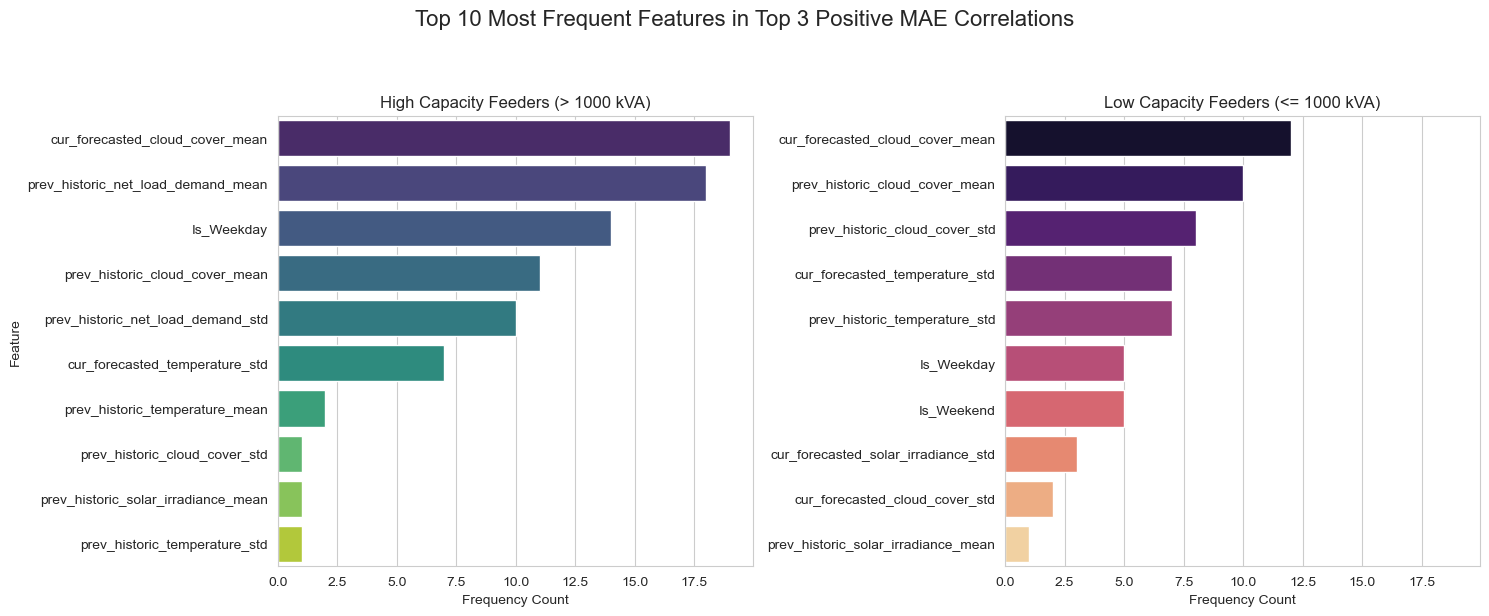

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter # For counting feature frequency

# Ignore simple warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

# --- Define Base Paths (Adjust if your script is located elsewhere) ---
BASE_PROJECT_PATH = Path("./../") # Path relative to the script location
DATA_PATH = BASE_PROJECT_PATH / "Data" / "Clustering_Data" / "Daytime"
RESULTS_PATH = DATA_PATH # Results are also under Data/Clustering_Data/Daytime/ according to user

# --- Feeder Capacities (Using corrected names from user) ---
FEEDER_CAPACITIES = {
    "Arch_Hall_ST2B13": 5594,
    "Chapel_Street_TY2B4": 100,
    "Dukes_ST2B15": 2409,
    "Fontabelle_1_TY2B7": 3099,
    "Green_Hill_WA2B6": 7816,
    "Hanson_(Belmont)_BE2B1": 546,
    "Marhill_St._TY2B8": 208,
    "Ometa_Mall_MA2B4": 455,
    "Sam_Lords_HA2B5": 4179,
    "Sunbury_HA2B2": 4648,
    "Swan_Street_TY2B6": 14,
    "Welches_WA2B2": 1211
}

# --- Capacity Threshold ---
HIGH_CAPACITY_THRESHOLD = 1000 # Example threshold in kVA (adjust as needed)

# --- Helper Function to Load and Preprocess Data (Unchanged) ---
def load_preprocess_feeder_data(feeder_name, dataset_type, models_to_analyze, actual_col_name="Actual"):
    """Loads features and results, calculates daily MAE for one feeder."""
    print(f"  Processing Feeder: {feeder_name}, Type: {dataset_type}...")

    results_folder = RESULTS_PATH / f"{dataset_type}_Results"
    features_folder = DATA_PATH / f"{dataset_type}_Features"

    results_path = results_folder / f"{feeder_name}_{dataset_type}_Results.csv"
    inputs_path = features_folder / f"{feeder_name}_X_{dataset_type}_Normalized.csv"

    if not results_path.is_file():
        print(f"    Warning: Results file not found: {results_path}")
        return None
    if not inputs_path.is_file():
        print(f"    Warning: Input features file not found: {inputs_path}")
        return None

    try:
        df_results = pd.read_csv(results_path, index_col=0, parse_dates=True)
        df_inputs = pd.read_csv(inputs_path, index_col=0, parse_dates=True)

        if df_results.index.name is None: df_results.index.name = "timestamp"
        if df_inputs.index.name is None: df_inputs.index.name = "timestamp"

        required_cols = models_to_analyze + [actual_col_name]
        missing_cols = [col for col in required_cols if col not in df_results.columns]
        if missing_cols:
            print(f"    Warning: Missing required columns in results file {results_path}: {missing_cols}")
            return None

        df_results["date_only"] = df_results.index.date
        daily_mae_list = []
        for model_name in models_to_analyze:
            abs_error_col = f"AbsError_{model_name}"
            daily_mae_col = f"Daily_MAE_{model_name}"
            df_results[abs_error_col] = (df_results[actual_col_name] - df_results[model_name]).abs()

            numeric_cols = df_results.select_dtypes(include=np.number).columns
            if abs_error_col in numeric_cols:
                daily_mae = df_results.groupby("date_only")[abs_error_col].mean().reset_index()
                daily_mae.rename(columns={abs_error_col: daily_mae_col, "date_only": "date"}, inplace=True)
                daily_mae["date"] = pd.to_datetime(daily_mae["date"])
                daily_mae_list.append(daily_mae.set_index("date"))
            else:
                 print(f"    Warning: AbsError column {abs_error_col} not numeric for {model_name}.")

        if not daily_mae_list:
            print("    Warning: No Daily MAE could be calculated.")
            return None

        merged_mae_df = pd.concat(daily_mae_list, axis=1)

        df_analysis = df_inputs.copy()
        df_analysis.index = df_analysis.index.normalize()
        df_analysis = df_analysis.join(merged_mae_df, how="inner")

        mae_cols_to_check = [f"Daily_MAE_{m}" for m in models_to_analyze if f"Daily_MAE_{m}" in df_analysis.columns]
        df_analysis.dropna(subset=mae_cols_to_check, inplace=True)

        if df_analysis.empty:
            print("    Warning: Analysis DataFrame empty after merging features and MAE.")
            return None

        return df_analysis

    except Exception as e:
        print(f"    Error processing {feeder_name} ({dataset_type}): {e}")
        return None


# --- Main Function ---
def generate_top_feature_tables(
    feeder_list: list,
    feeder_capacities: dict,
    mode: str, # "Validation", "Test", or "Combined"
    models_to_analyze: list = ["Final_RLS", "LSTM_RLS", "ANN_RLS", "Benchmark"],
    actual_col_name: str = "Actual",
    capacity_threshold: int = HIGH_CAPACITY_THRESHOLD
):
    """
    Generates tables of top 3 positively correlated features with Daily MAE,
    including standard deviation features.
    """
    print(f"--- Generating Top Feature Tables --- Mode: {mode} ---")
    all_feeder_top_features = {model: {} for model in models_to_analyze}

    for feeder_name in feeder_list:
        if feeder_name not in feeder_capacities:
             print(f"Warning: Capacity not defined for feeder '{feeder_name}'. Skipping.")
             continue

        df_combined = pd.DataFrame()
        # --- 1. Load Data based on Mode ---
        if mode == "Validation" or mode == "Combined":
            df_val = load_preprocess_feeder_data(feeder_name, "Validation", models_to_analyze, actual_col_name)
            if df_val is not None: df_combined = pd.concat([df_combined, df_val], axis=0)
        if mode == "Test" or mode == "Combined":
            df_test = load_preprocess_feeder_data(feeder_name, "Test", models_to_analyze, actual_col_name)
            if df_test is not None: df_combined = pd.concat([df_combined, df_test], axis=0)

        if df_combined.empty:
            print(f"  Skipping {feeder_name} due to data loading/processing issues.")
            continue

        df_combined = df_combined[~df_combined.index.duplicated(keep='first')]
        df_analysis = df_combined.copy()

        # --- 2. Feature Engineering (Means and Standard Deviations) ---
        print(f"  Feature Engineering for {feeder_name}...")
        # Prefixes for weather/load features that have multiple time steps (0-14)
        feature_prefixes_multi_step = [
            "prev_historic_temperature", "cur_forecasted_temperature",
            "prev_historic_solar_irradiance", "cur_forecasted_solar_irradiance",
            "prev_historic_cloud_cover", "cur_forecasted_cloud_cover",
            "prev_historic_net_load_demand"
        ]
        weather_feature_means = []
        weather_feature_stds = [] # List to store std feature names

        for prefix in feature_prefixes_multi_step:
            cols = [col for col in df_analysis.columns if col.startswith(prefix) and not (col.endswith("_mean") or col.endswith("_std"))]
            if cols:
                # Calculate Mean
                mean_col_name = f"{prefix}_mean"
                if mean_col_name not in df_analysis.columns:
                    df_analysis[mean_col_name] = df_analysis[cols].mean(axis=1)
                weather_feature_means.append(mean_col_name)

                # Calculate Standard Deviation
                std_col_name = f"{prefix}_std"
                if std_col_name not in df_analysis.columns:
                    df_analysis[std_col_name] = df_analysis[cols].std(axis=1)
                weather_feature_stds.append(std_col_name) # Add std feature name

        # Create Time Features: Is_Weekend, Is_Weekday, Is_Holiday
        time_features = []
        dow_5_exists = "cur_day_of_week_5" in df_analysis.columns
        dow_6_exists = "cur_day_of_week_6" in df_analysis.columns
        if dow_5_exists and dow_6_exists:
            df_analysis["Is_Weekend"] = ((df_analysis["cur_day_of_week_5"] == 1) | (df_analysis["cur_day_of_week_6"] == 1)).astype(int)
            df_analysis["Is_Weekday"] = 1 - df_analysis["Is_Weekend"]
            time_features.extend(["Is_Weekday", "Is_Weekend"])
        else:
            if "Is_Weekend" not in df_analysis.columns: df_analysis["Is_Weekend"] = 0
            if "Is_Weekday" not in df_analysis.columns: df_analysis["Is_Weekday"] = 0

        holiday_col_orig = "cur_is_holiday_0"
        if holiday_col_orig in df_analysis.columns:
            df_analysis["Is_Holiday"] = df_analysis[holiday_col_orig].astype(int)
            time_features.append("Is_Holiday")
        else:
             if "Is_Holiday" not in df_analysis.columns: df_analysis["Is_Holiday"] = 0

        # Final list of features for correlation (including std dev)
        features_for_corr = [tf for tf in time_features if df_analysis[tf].nunique() > 1] + \
                            [wf for wf in weather_feature_means if wf in df_analysis.columns and df_analysis[wf].nunique() > 1] + \
                            [ws for ws in weather_feature_stds if ws in df_analysis.columns and df_analysis[ws].nunique() > 1] # Add std features

        if not features_for_corr:
             print(f"  Warning: No features with variance found for correlation for feeder {feeder_name}.")
             continue
        print(f"    Features for correlation ({len(features_for_corr)}): {features_for_corr}")

        # --- 3. Calculate Correlations and Find Top 3 Positive ---
        for model_name in models_to_analyze:
            mae_col = f"Daily_MAE_{model_name}"
            if mae_col not in df_analysis.columns: continue

            corr_cols = [mae_col] + features_for_corr
            try:
                # Fill potential NaNs in std columns (e.g., if only 1 data point for a day) before correlating
                df_corr_subset = df_analysis[corr_cols].fillna(0) # Fill NaNs in std with 0 for correlation
                correlation_matrix = df_corr_subset.corr()
                mae_correlations = correlation_matrix[mae_col].drop(mae_col, axis=0).dropna()
                top_3_positive = mae_correlations[mae_correlations > 0].nlargest(3)
                top_features_list = list(top_3_positive.index)
                while len(top_features_list) < 3: top_features_list.append("N/A")
                all_feeder_top_features[model_name][feeder_name] = top_features_list
            except Exception as e:
                print(f"    Error calculating correlation for {feeder_name}, {model_name}: {e}")

    # --- 4. Organize into High/Low Capacity Tables ---
    output_tables = {model: {"High Capacity": [], "Low Capacity": []} for model in models_to_analyze}
    for model_name in models_to_analyze:
        for feeder_name, top_features in all_feeder_top_features[model_name].items():
            capacity = feeder_capacities.get(feeder_name, -1)
            row_data = {"Feeder Name": feeder_name, "Feature #1": top_features[0], "Feature #2": top_features[1], "Feature #3": top_features[2]}
            if capacity > capacity_threshold:
                output_tables[model_name]["High Capacity"].append(row_data)
            elif capacity >= 0:
                 output_tables[model_name]["Low Capacity"].append(row_data)
        output_tables[model_name]["High Capacity"] = pd.DataFrame(output_tables[model_name]["High Capacity"])
        output_tables[model_name]["Low Capacity"] = pd.DataFrame(output_tables[model_name]["Low Capacity"])

    print("\n--- Table Generation Complete ---")
    return output_tables


# --- Function to Plot Most Significant Features ---
def plot_most_significant_features(generated_tables: dict, top_n: int = 7):
    """
    Calculates and plots the frequency of features appearing in the top 3
    positive correlations for high and low capacity feeders.

    Args:
        generated_tables (dict): The dictionary returned by generate_top_feature_tables.
        top_n (int): How many top features to display in the plot.
    """
    print(f"\n--- Calculating and Plotting Top {top_n} Most Frequent Features ---")
    sns.set_style("whitegrid")
    high_cap_all_features = []
    low_cap_all_features = []

    # Collect all features listed in the tables
    for model in generated_tables:
        for _, row in generated_tables[model]["High Capacity"].iterrows():
            high_cap_all_features.extend([row["Feature #1"], row["Feature #2"], row["Feature #3"]])
        for _, row in generated_tables[model]["Low Capacity"].iterrows():
            low_cap_all_features.extend([row["Feature #1"], row["Feature #2"], row["Feature #3"]])

    # Remove placeholders and count frequencies
    high_cap_counts = Counter(f for f in high_cap_all_features if f != "N/A")
    low_cap_counts = Counter(f for f in low_cap_all_features if f != "N/A")

    # Prepare data for plotting
    df_high_freq = pd.DataFrame(high_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])
    df_low_freq = pd.DataFrame(low_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])

    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(15, top_n * 0.6), sharex=True) # Adjust figsize
    fig.suptitle(f'Top {top_n} Most Frequent Features in Top 3 Positive MAE Correlations', fontsize=16, y=1.02)

    # High Capacity Plot
    if not df_high_freq.empty:
        sns.barplot(ax=axes[0], x='Frequency', y='Feature', data=df_high_freq, palette='viridis')
        axes[0].set_title(f'High Capacity Feeders (> {HIGH_CAPACITY_THRESHOLD} kVA)')
        axes[0].set_xlabel("Frequency Count")
        axes[0].set_ylabel("Feature")
    else:
        axes[0].set_title(f'High Capacity Feeders (> {HIGH_CAPACITY_THRESHOLD} kVA)\n(No features found)')
        axes[0].text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)


    # Low Capacity Plot
    if not df_low_freq.empty:
        sns.barplot(ax=axes[1], x='Frequency', y='Feature', data=df_low_freq, palette='magma')
        axes[1].set_title(f'Low Capacity Feeders (<= {HIGH_CAPACITY_THRESHOLD} kVA)')
        axes[1].set_xlabel("Frequency Count")
        axes[1].set_ylabel("") # Remove redundant y-label
    else:
        axes[1].set_title(f'Low Capacity Feeders (<= {HIGH_CAPACITY_THRESHOLD} kVA)\n(No features found)')
        axes[1].text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)


    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()


# --- Main Execution Block ---
if __name__ == "__main__":

    all_feeders = list(FEEDER_CAPACITIES.keys())
    analysis_mode = "Combined" # Choose "Validation", "Test", or "Combined"

    generated_tables = generate_top_feature_tables(
        feeder_list=all_feeders,
        feeder_capacities=FEEDER_CAPACITIES,
        mode=analysis_mode,
        models_to_analyze=["ANN_RLS", "LSTM_RLS", "Final_RLS", "Benchmark"]
    )

    # --- Display Sample Output for ANN_RLS ---
    target_model = "ANN_RLS"
    print(f"\n\n--- Top 3 Positively Correlated Features for Model: {target_model} (Mode: {analysis_mode}) ---")
    if target_model in generated_tables:
        print("\nHigh Capacity Feeders:")
        if not generated_tables[target_model]["High Capacity"].empty:
            print(generated_tables[target_model]["High Capacity"].to_string(index=False))
        else:
            print("No high capacity feeders processed or found.")
        print("\nLow Capacity Feeders:")
        if not generated_tables[target_model]["Low Capacity"].empty:
            print(generated_tables[target_model]["Low Capacity"].to_string(index=False))
        else:
            print("No low capacity feeders processed or found.")
    else:
        print(f"No results found for model {target_model}.")

    # --- Plot Overall Most Significant Features ---
    if generated_tables: # Check if any tables were generated
        plot_most_significant_features(generated_tables, top_n=10) # Plot top 10 features
    else:
        print("\nSkipping most significant feature plot as no tables were generated.")

--- Generating Top Feature Tables & Correlation Data --- Mode: Combined ---
  Processing Feeder: Arch_Hall_ST2B13, Type: Validation...
  Processing Feeder: Arch_Hall_ST2B13, Type: Test...
  Feature Engineering for Arch_Hall_ST2B13...
  Calculating correlations for Arch_Hall_ST2B13...
    Top 5 Negative Correlations (ANN_RLS @ Arch_Hall_ST2B13):
cur_forecasted_solar_irradiance_mean   -0.282
cur_forecasted_temperature_mean        -0.205
cur_forecasted_solar_irradiance_std    -0.128
prev_historic_net_load_demand_std      -0.105
Is_Weekend                             -0.084
Name: Daily_MAE_ANN_RLS, dtype: float64
    Top 5 Negative Correlations (LSTM_RLS @ Arch_Hall_ST2B13):
cur_forecasted_solar_irradiance_mean   -0.182
cur_forecasted_temperature_mean        -0.181
prev_historic_cloud_cover_mean         -0.111
Is_Weekend                             -0.064
cur_forecasted_solar_irradiance_std    -0.024
Name: Daily_MAE_LSTM_RLS, dtype: float64
    Top 5 Negative Correlations (Final_RLS @ Arch

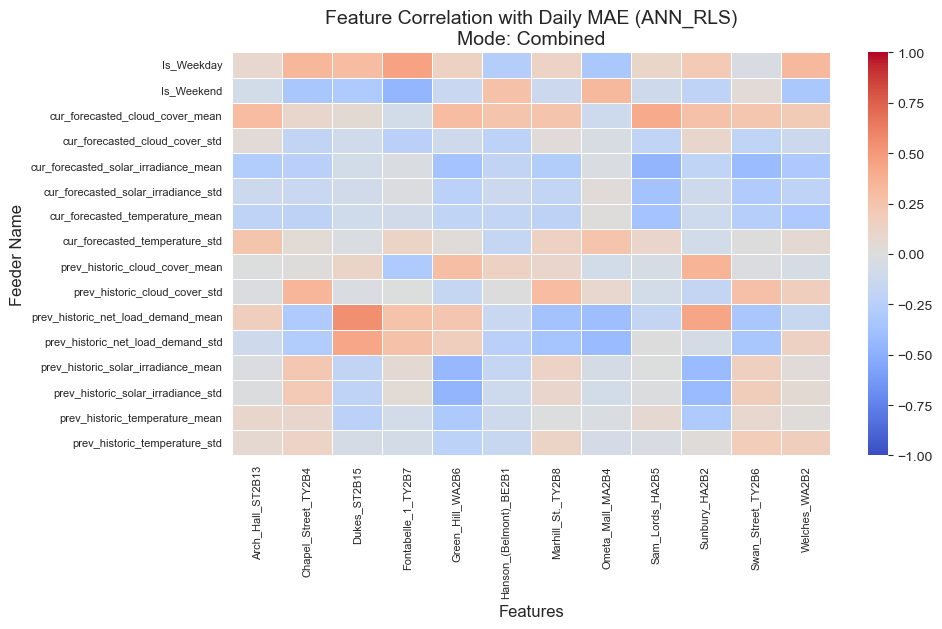

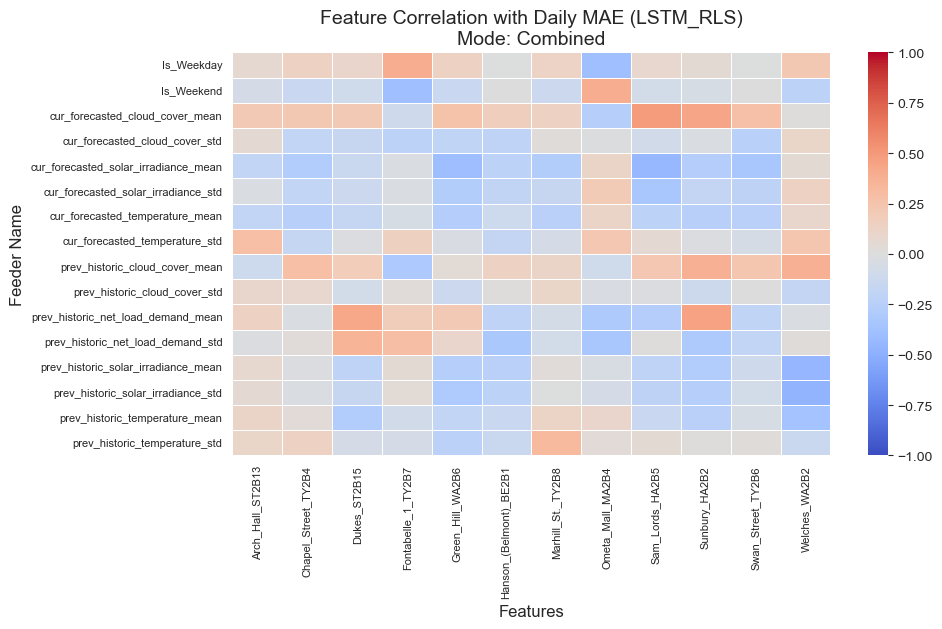

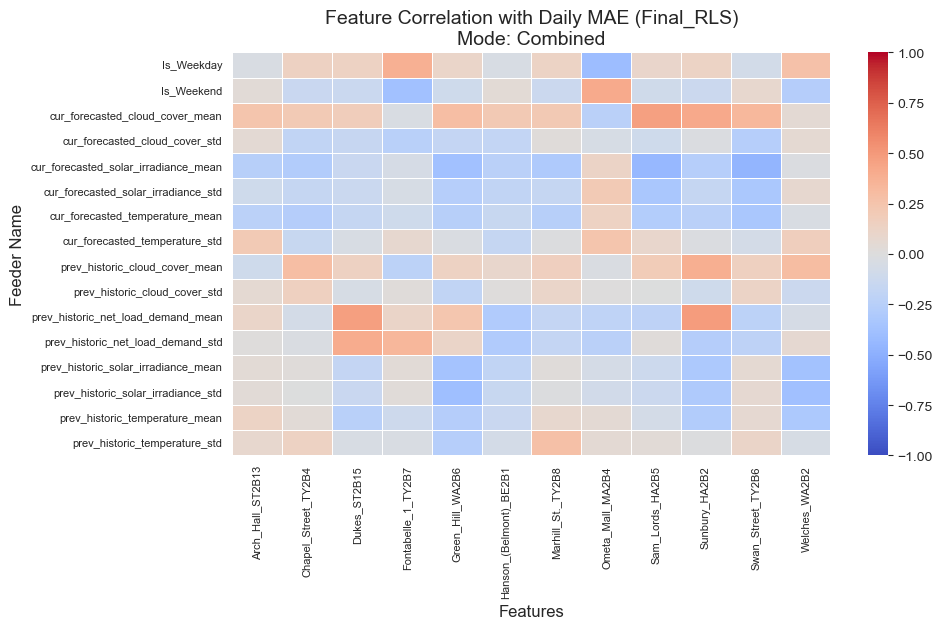

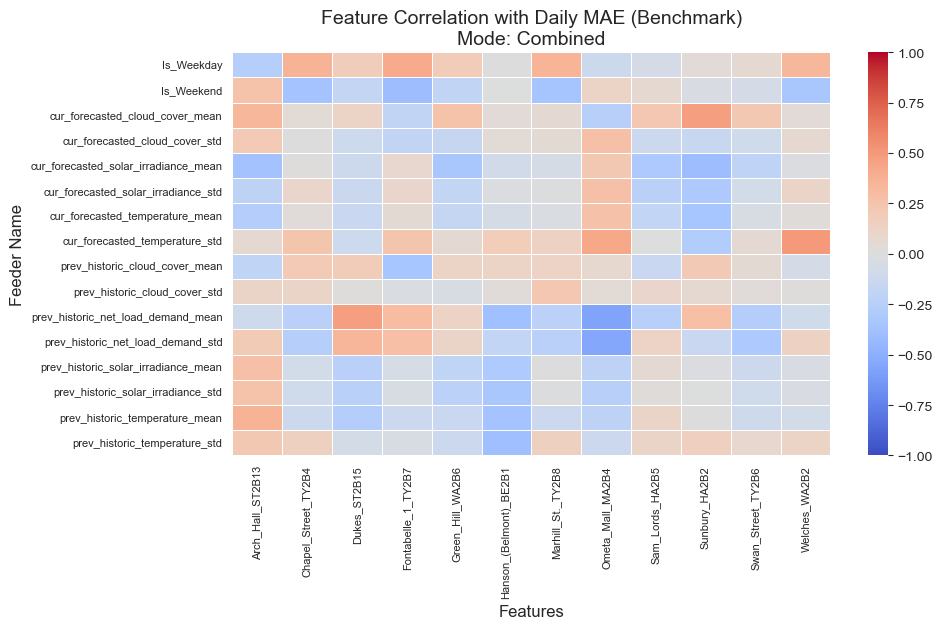


--- Table & Heatmap Generation Complete ---


--- Top 3 Positively Correlated Features for Model: ANN_RLS (Mode: Combined) ---

High Capacity Feeders:
       Feeder Name                         Feature #1                        Feature #2                         Feature #3
  Arch_Hall_ST2B13    cur_forecasted_cloud_cover_mean    cur_forecasted_temperature_std prev_historic_net_load_demand_mean
      Dukes_ST2B15 prev_historic_net_load_demand_mean prev_historic_net_load_demand_std                         Is_Weekday
Fontabelle_1_TY2B7                         Is_Weekday prev_historic_net_load_demand_std prev_historic_net_load_demand_mean
  Green_Hill_WA2B6    cur_forecasted_cloud_cover_mean    prev_historic_cloud_cover_mean prev_historic_net_load_demand_mean
   Sam_Lords_HA2B5    cur_forecasted_cloud_cover_mean                        Is_Weekday     cur_forecasted_temperature_std
     Sunbury_HA2B2 prev_historic_net_load_demand_mean    prev_historic_cloud_cover_mean    cur_forecasted_clou

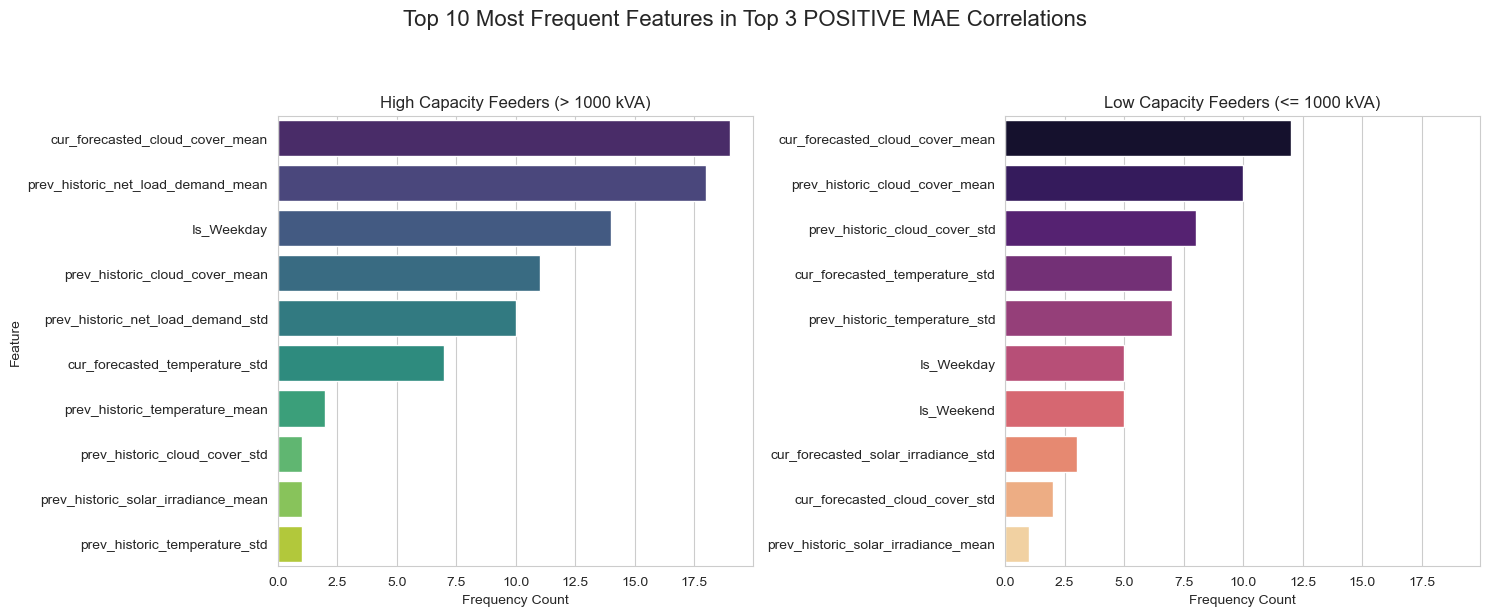


--- Calculating and Plotting Top 10 Most Frequent NEGATIVE Features ---


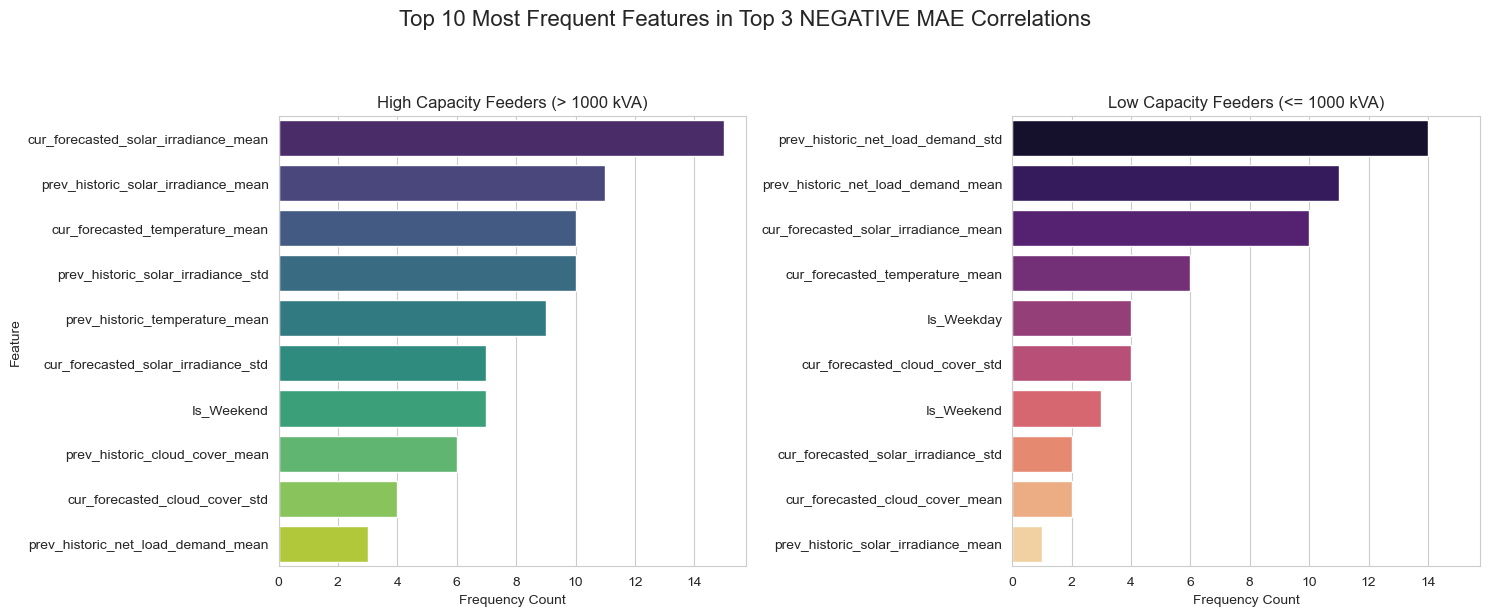

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter # For counting feature frequency

# Ignore simple warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

# --- Define Base Paths (Adjust if your script is located elsewhere) ---
BASE_PROJECT_PATH = Path("./../") # Path relative to the script location
DATA_PATH = BASE_PROJECT_PATH / "Data" / "Clustering_Data" / "Daytime"
RESULTS_PATH = DATA_PATH # Results are also under Data/Clustering_Data/Daytime/ according to user

# --- Feeder Capacities (Using corrected names from user) ---
FEEDER_CAPACITIES = {
    "Arch_Hall_ST2B13": 5594,
    "Chapel_Street_TY2B4": 100,
    "Dukes_ST2B15": 2409,
    "Fontabelle_1_TY2B7": 3099,
    "Green_Hill_WA2B6": 7816,
    "Hanson_(Belmont)_BE2B1": 546,
    "Marhill_St._TY2B8": 208,
    "Ometa_Mall_MA2B4": 455,
    "Sam_Lords_HA2B5": 4179,
    "Sunbury_HA2B2": 4648,
    "Swan_Street_TY2B6": 14,
    "Welches_WA2B2": 1211
}

# --- Capacity Threshold ---
HIGH_CAPACITY_THRESHOLD = 1000 # Example threshold in kVA (adjust as needed)

# --- Helper Function to Load and Preprocess Data (Unchanged) ---
def load_preprocess_feeder_data(feeder_name, dataset_type, models_to_analyze, actual_col_name="Actual"):
    """Loads features and results, calculates daily MAE for one feeder."""
    print(f"  Processing Feeder: {feeder_name}, Type: {dataset_type}...")

    results_folder = RESULTS_PATH / f"{dataset_type}_Results"
    features_folder = DATA_PATH / f"{dataset_type}_Features"

    results_path = results_folder / f"{feeder_name}_{dataset_type}_Results.csv"
    inputs_path = features_folder / f"{feeder_name}_X_{dataset_type}_Normalized.csv"

    if not results_path.is_file():
        print(f"    Warning: Results file not found: {results_path}")
        return None
    if not inputs_path.is_file():
        print(f"    Warning: Input features file not found: {inputs_path}")
        return None

    try:
        df_results = pd.read_csv(results_path, index_col=0, parse_dates=True)
        df_inputs = pd.read_csv(inputs_path, index_col=0, parse_dates=True)

        if df_results.index.name is None: df_results.index.name = "timestamp"
        if df_inputs.index.name is None: df_inputs.index.name = "timestamp"

        required_cols = models_to_analyze + [actual_col_name]
        missing_cols = [col for col in required_cols if col not in df_results.columns]
        if missing_cols:
            print(f"    Warning: Missing required columns in results file {results_path}: {missing_cols}")
            return None

        df_results["date_only"] = df_results.index.date
        daily_mae_list = []
        for model_name in models_to_analyze:
            abs_error_col = f"AbsError_{model_name}"
            daily_mae_col = f"Daily_MAE_{model_name}"
            df_results[abs_error_col] = (df_results[actual_col_name] - df_results[model_name]).abs()

            numeric_cols = df_results.select_dtypes(include=np.number).columns
            if abs_error_col in numeric_cols:
                daily_mae = df_results.groupby("date_only")[abs_error_col].mean().reset_index()
                daily_mae.rename(columns={abs_error_col: daily_mae_col, "date_only": "date"}, inplace=True)
                daily_mae["date"] = pd.to_datetime(daily_mae["date"])
                daily_mae_list.append(daily_mae.set_index("date"))
            else:
                 print(f"    Warning: AbsError column {abs_error_col} not numeric for {model_name}.")

        if not daily_mae_list:
            print("    Warning: No Daily MAE could be calculated.")
            return None

        merged_mae_df = pd.concat(daily_mae_list, axis=1)

        df_analysis = df_inputs.copy()
        df_analysis.index = df_analysis.index.normalize()
        df_analysis = df_analysis.join(merged_mae_df, how="inner")

        mae_cols_to_check = [f"Daily_MAE_{m}" for m in models_to_analyze if f"Daily_MAE_{m}" in df_analysis.columns]
        df_analysis.dropna(subset=mae_cols_to_check, inplace=True)

        if df_analysis.empty:
            print("    Warning: Analysis DataFrame empty after merging features and MAE.")
            return None

        return df_analysis

    except Exception as e:
        print(f"    Error processing {feeder_name} ({dataset_type}): {e}")
        return None


# --- Main Function ---
def generate_top_feature_tables(
    feeder_list: list,
    feeder_capacities: dict,
    mode: str, # "Validation", "Test", or "Combined"
    models_to_analyze: list = ["Final_RLS", "LSTM_RLS", "ANN_RLS", "Benchmark"],
    actual_col_name: str = "Actual",
    capacity_threshold: int = HIGH_CAPACITY_THRESHOLD
):
    """
    Generates tables of top 3 positively/negatively correlated features with Daily MAE,
    including standard deviation features, and collects data for heatmaps.
    """
    print(f"--- Generating Top Feature Tables & Correlation Data --- Mode: {mode} ---")
    all_feeder_top_positive_features = {model: {} for model in models_to_analyze} # {model: {feeder: [top3_pos]}}
    all_feeder_top_negative_features = {model: {} for model in models_to_analyze} # {model: {feeder: [top3_neg]}}
    per_feeder_correlations = {model: {} for model in models_to_analyze} # {model: {feeder: pd.Series(corr_vector)}}

    for feeder_name in feeder_list:
        if feeder_name not in feeder_capacities:
             print(f"Warning: Capacity not defined for feeder '{feeder_name}'. Skipping.")
             continue

        df_combined = pd.DataFrame()
        # --- 1. Load Data based on Mode ---
        if mode == "Validation" or mode == "Combined":
            df_val = load_preprocess_feeder_data(feeder_name, "Validation", models_to_analyze, actual_col_name)
            if df_val is not None: df_combined = pd.concat([df_combined, df_val], axis=0)
        if mode == "Test" or mode == "Combined":
            df_test = load_preprocess_feeder_data(feeder_name, "Test", models_to_analyze, actual_col_name)
            if df_test is not None: df_combined = pd.concat([df_combined, df_test], axis=0)

        if df_combined.empty:
            print(f"  Skipping {feeder_name} due to data loading/processing issues.")
            continue

        df_combined = df_combined[~df_combined.index.duplicated(keep='first')]
        df_analysis = df_combined.copy()

        # --- 2. Feature Engineering (Means and Standard Deviations) ---
        print(f"  Feature Engineering for {feeder_name}...")
        feature_prefixes_multi_step = [
            "prev_historic_temperature", "cur_forecasted_temperature",
            "prev_historic_solar_irradiance", "cur_forecasted_solar_irradiance",
            "prev_historic_cloud_cover", "cur_forecasted_cloud_cover",
            "prev_historic_net_load_demand"
        ]
        weather_feature_means = []
        weather_feature_stds = []

        for prefix in feature_prefixes_multi_step:
            cols = [col for col in df_analysis.columns if col.startswith(prefix) and not (col.endswith("_mean") or col.endswith("_std"))]
            if cols:
                mean_col_name = f"{prefix}_mean"
                std_col_name = f"{prefix}_std"
                if mean_col_name not in df_analysis.columns: df_analysis[mean_col_name] = df_analysis[cols].mean(axis=1)
                if std_col_name not in df_analysis.columns: df_analysis[std_col_name] = df_analysis[cols].std(axis=1)
                weather_feature_means.append(mean_col_name)
                weather_feature_stds.append(std_col_name)

        time_features = []
        dow_5_exists = "cur_day_of_week_5" in df_analysis.columns
        dow_6_exists = "cur_day_of_week_6" in df_analysis.columns
        if dow_5_exists and dow_6_exists:
            df_analysis["Is_Weekend"] = ((df_analysis["cur_day_of_week_5"] == 1) | (df_analysis["cur_day_of_week_6"] == 1)).astype(int)
            df_analysis["Is_Weekday"] = 1 - df_analysis["Is_Weekend"]
            time_features.extend(["Is_Weekday", "Is_Weekend"])
        else:
            if "Is_Weekend" not in df_analysis.columns: df_analysis["Is_Weekend"] = 0
            if "Is_Weekday" not in df_analysis.columns: df_analysis["Is_Weekday"] = 0

        holiday_col_orig = "cur_is_holiday_0"
        if holiday_col_orig in df_analysis.columns:
            df_analysis["Is_Holiday"] = df_analysis[holiday_col_orig].astype(int)
            time_features.append("Is_Holiday")
        else:
             if "Is_Holiday" not in df_analysis.columns: df_analysis["Is_Holiday"] = 0

        features_for_corr = [tf for tf in time_features if df_analysis[tf].nunique() > 1] + \
                            [wf for wf in weather_feature_means if wf in df_analysis.columns and df_analysis[wf].nunique() > 1] + \
                            [ws for ws in weather_feature_stds if ws in df_analysis.columns and df_analysis[ws].nunique() > 1]

        if not features_for_corr:
             print(f"  Warning: No features with variance found for correlation for feeder {feeder_name}.")
             continue
        # print(f"    Features for correlation ({len(features_for_corr)}): {features_for_corr}") # Optional verbose print

        # --- 3. Calculate Correlations, Find Top 3 Pos/Neg, Store Full Vector ---
        print(f"  Calculating correlations for {feeder_name}...")
        for model_name in models_to_analyze:
            mae_col = f"Daily_MAE_{model_name}"
            if mae_col not in df_analysis.columns: continue

            corr_cols = [mae_col] + features_for_corr
            try:
                df_corr_subset = df_analysis[corr_cols].fillna(0)
                correlation_matrix = df_corr_subset.corr()
                mae_correlations = correlation_matrix[mae_col].drop(mae_col, axis=0).dropna()

                # Store the full correlation vector for the heatmap
                per_feeder_correlations[model_name][feeder_name] = mae_correlations

                # --- Top 3 Positive ---
                top_3_positive = mae_correlations[mae_correlations > 0].nlargest(3)
                top_pos_list = list(top_3_positive.index)
                while len(top_pos_list) < 3: top_pos_list.append("N/A")
                all_feeder_top_positive_features[model_name][feeder_name] = top_pos_list

                # --- Top 3 Negative (for frequency plot) & Top 5 Negative (for printing) ---
                neg_corrs = mae_correlations[mae_correlations < 0].sort_values() # Sort ascending (most negative first)
                top_5_negative = neg_corrs.head(5)
                top_3_neg_list = list(neg_corrs.head(3).index) # Get names for frequency plot
                while len(top_3_neg_list) < 3: top_3_neg_list.append("N/A")
                all_feeder_top_negative_features[model_name][feeder_name] = top_3_neg_list

                # Print Top 5 Negative for this feeder/model
                print(f"    Top 5 Negative Correlations ({model_name} @ {feeder_name}):")
                if not top_5_negative.empty:
                    print(top_5_negative.round(3))
                else:
                    print("      None found.")

            except Exception as e:
                print(f"    Error calculating correlation for {feeder_name}, {model_name}: {e}")


    # --- 4. Organize into High/Low Capacity Tables (Top Positive Features) ---
    output_tables_pos = {model: {"High Capacity": [], "Low Capacity": []} for model in models_to_analyze}
    for model_name in models_to_analyze:
        for feeder_name, top_features in all_feeder_top_positive_features[model_name].items():
            capacity = feeder_capacities.get(feeder_name, -1)
            row_data = {"Feeder Name": feeder_name, "Feature #1": top_features[0], "Feature #2": top_features[1], "Feature #3": top_features[2]}
            if capacity > capacity_threshold: output_tables_pos[model_name]["High Capacity"].append(row_data)
            elif capacity >= 0: output_tables_pos[model_name]["Low Capacity"].append(row_data)
        output_tables_pos[model_name]["High Capacity"] = pd.DataFrame(output_tables_pos[model_name]["High Capacity"])
        output_tables_pos[model_name]["Low Capacity"] = pd.DataFrame(output_tables_pos[model_name]["Low Capacity"])

    # --- 5. Generate Correlation Heatmaps ---
    print("\n--- Generating Correlation Heatmaps per Model ---")
    sns.set_style("whitegrid")
    for model_name in models_to_analyze:
        if not per_feeder_correlations[model_name]: # Skip if no data for this model
            print(f"  Skipping heatmap for {model_name}: No correlation data collected.")
            continue

        # Create DataFrame for heatmap: Feeders (rows) vs Features (columns)
        heatmap_df = pd.DataFrame(per_feeder_correlations[model_name]).T # Transpose to get feeders as rows
        heatmap_df = heatmap_df.dropna(axis=1, how='all') # Drop feature columns if they are all NaN

        if heatmap_df.empty:
            print(f"  Skipping heatmap for {model_name}: DataFrame is empty after processing.")
            continue

        # Sort columns (features) alphabetically for consistency
        heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)
        # Sort rows (feeders) alphabetically
        heatmap_df = heatmap_df.sort_index()
        heatmap_df = heatmap_df.T


        # Determine appropriate figure size
        n_feeders = len(heatmap_df)
        n_features = len(heatmap_df.columns)
        # Adjust width based on number of features, height based on number of feeders
        fig_width = max(10, n_features * 0.5)
        fig_height = max(6, n_feeders * 0.4)

        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(heatmap_df, cmap="coolwarm", annot=False, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, cbar=True) # Annot=False for many features
        plt.title(f"Feature Correlation with Daily MAE ({model_name})\nMode: {mode}", fontsize=14)
        plt.xlabel("Features", fontsize=12)
        plt.ylabel("Feeder Name", fontsize=12)
        plt.xticks(rotation=90, fontsize=8) # Rotate feature names
        plt.yticks(rotation=0, fontsize=8)
        plt.tight_layout()
        plt.show()

    print("\n--- Table & Heatmap Generation Complete ---")
    # Return both positive and negative top features dicts, and the raw correlations
    return output_tables_pos, all_feeder_top_negative_features, per_feeder_correlations


# --- Function to Plot Most Significant Positive Features (Unchanged) ---
def plot_most_significant_features(generated_tables: dict, capacity_threshold: int, top_n: int = 7):
    """ Plots frequency of top 3 positive features for high/low capacity. """
    print(f"\n--- Calculating and Plotting Top {top_n} Most Frequent POSITIVE Features ---")
    sns.set_style("whitegrid")
    high_cap_all_features = []
    low_cap_all_features = []

    for model in generated_tables:
        for _, row in generated_tables[model]["High Capacity"].iterrows():
            high_cap_all_features.extend([row["Feature #1"], row["Feature #2"], row["Feature #3"]])
        for _, row in generated_tables[model]["Low Capacity"].iterrows():
            low_cap_all_features.extend([row["Feature #1"], row["Feature #2"], row["Feature #3"]])

    high_cap_counts = Counter(f for f in high_cap_all_features if f != "N/A")
    low_cap_counts = Counter(f for f in low_cap_all_features if f != "N/A")

    df_high_freq = pd.DataFrame(high_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])
    df_low_freq = pd.DataFrame(low_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])

    fig, axes = plt.subplots(1, 2, figsize=(15, max(5, top_n * 0.6)), sharex=True)
    fig.suptitle(f'Top {top_n} Most Frequent Features in Top 3 POSITIVE MAE Correlations', fontsize=16, y=1.02)

    if not df_high_freq.empty:
        sns.barplot(ax=axes[0], x='Frequency', y='Feature', data=df_high_freq, palette='viridis')
        axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)')
        axes[0].set_xlabel("Frequency Count"); axes[0].set_ylabel("Feature")
    else:
        axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)\n(No features found)')
        axes[0].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[0].transAxes)

    if not df_low_freq.empty:
        sns.barplot(ax=axes[1], x='Frequency', y='Feature', data=df_low_freq, palette='magma')
        axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)')
        axes[1].set_xlabel("Frequency Count"); axes[1].set_ylabel("")
    else:
        axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)\n(No features found)')
        axes[1].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[1].transAxes)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# --- Function to Plot Most Significant Negative Features ---
def plot_most_significant_negative_features(all_negative_features: dict, feeder_capacities: dict, capacity_threshold: int, top_n: int = 7):
    """
    Calculates and plots the frequency of features appearing in the top 3
    negative correlations for high and low capacity feeders.

    Args:
        all_negative_features (dict): Dict returned by generate_top_feature_tables (second element).
                                      Structure: {model: {feeder: [top3_neg_features]}}
        feeder_capacities (dict): Dictionary mapping feeder names to capacities.
        capacity_threshold (int): Threshold to separate high/low capacity.
        top_n (int): How many top features to display in the plot.
    """
    print(f"\n--- Calculating and Plotting Top {top_n} Most Frequent NEGATIVE Features ---")
    sns.set_style("whitegrid")
    high_cap_all_features = []
    low_cap_all_features = []

    # Collect all features listed
    for model in all_negative_features:
        for feeder_name, features in all_negative_features[model].items():
            capacity = feeder_capacities.get(feeder_name, -1)
            if capacity > capacity_threshold:
                high_cap_all_features.extend(features)
            elif capacity >= 0:
                low_cap_all_features.extend(features)

    # Remove placeholders and count frequencies
    high_cap_counts = Counter(f for f in high_cap_all_features if f != "N/A")
    low_cap_counts = Counter(f for f in low_cap_all_features if f != "N/A")

    # Prepare data for plotting
    df_high_freq = pd.DataFrame(high_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])
    df_low_freq = pd.DataFrame(low_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])

    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(15, max(5, top_n * 0.6)), sharex=True) # Adjust figsize
    fig.suptitle(f'Top {top_n} Most Frequent Features in Top 3 NEGATIVE MAE Correlations', fontsize=16, y=1.02)

    # High Capacity Plot
    if not df_high_freq.empty:
        sns.barplot(ax=axes[0], x='Frequency', y='Feature', data=df_high_freq, palette='viridis')
        axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)')
        axes[0].set_xlabel("Frequency Count")
        axes[0].set_ylabel("Feature")
    else:
        axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)\n(No features found)')
        axes[0].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[0].transAxes)

    # Low Capacity Plot
    if not df_low_freq.empty:
        sns.barplot(ax=axes[1], x='Frequency', y='Feature', data=df_low_freq, palette='magma')
        axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)')
        axes[1].set_xlabel("Frequency Count")
        axes[1].set_ylabel("") # Remove redundant y-label
    else:
        axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)\n(No features found)')
        axes[1].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[1].transAxes)

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()


# --- Main Execution Block ---
if __name__ == "__main__":

    all_feeders = list(FEEDER_CAPACITIES.keys())
    analysis_mode = "Combined" # Choose "Validation", "Test", or "Combined"

    # Generate tables and collect correlation data
    output_tables_pos, all_neg_features, _ = generate_top_feature_tables( # Ignore raw correlations for now
        feeder_list=all_feeders,
        feeder_capacities=FEEDER_CAPACITIES,
        mode=analysis_mode,
        models_to_analyze=["ANN_RLS", "LSTM_RLS", "Final_RLS", "Benchmark"]
    )

    # --- Display Sample Output Table for ANN_RLS (Top Positive) ---
    target_model = "ANN_RLS"
    print(f"\n\n--- Top 3 Positively Correlated Features for Model: {target_model} (Mode: {analysis_mode}) ---")
    if target_model in output_tables_pos:
        print("\nHigh Capacity Feeders:")
        if not output_tables_pos[target_model]["High Capacity"].empty:
            print(output_tables_pos[target_model]["High Capacity"].to_string(index=False))
        else: print("No high capacity feeders processed or found.")
        print("\nLow Capacity Feeders:")
        if not output_tables_pos[target_model]["Low Capacity"].empty:
            print(output_tables_pos[target_model]["Low Capacity"].to_string(index=False))
        else: print("No low capacity feeders processed or found.")
    else: print(f"No results found for model {target_model}.")

    # --- Plot Overall Most Significant Features (Positive and Negative) ---
    if output_tables_pos: # Check if positive tables were generated
        plot_most_significant_features(output_tables_pos, HIGH_CAPACITY_THRESHOLD, top_n=10)
    else: print("\nSkipping most significant positive feature plot as no tables were generated.")

    if all_neg_features: # Check if negative feature data was collected
        plot_most_significant_negative_features(all_neg_features, FEEDER_CAPACITIES, HIGH_CAPACITY_THRESHOLD, top_n=10)
    else: print("\nSkipping most significant negative feature plot as no data was collected.")

--- Generating Top Feature Tables & Correlation Data --- Mode: Combined ---
  Processing Feeder: Arch_Hall_ST2B13, Type: Validation...
  Processing Feeder: Arch_Hall_ST2B13, Type: Test...
  Feature Engineering for Arch_Hall_ST2B13...
  Calculating correlations for Arch_Hall_ST2B13...
    Top 5 Negative Correlations (ANN_RLS @ Arch_Hall_ST2B13):
Forecast Solar (Mean)      -0.282
Forecast Temp (Mean)       -0.205
Forecast Solar (Std Dev)   -0.128
Prev Day Load (Std Dev)    -0.105
Is Weekend                 -0.084
Name: Daily_MAE_ANN_RLS, dtype: float64
    Top 5 Negative Correlations (LSTM_RLS @ Arch_Hall_ST2B13):
Forecast Solar (Mean)      -0.182
Forecast Temp (Mean)       -0.181
Prev Day Cloud (Mean)      -0.111
Is Weekend                 -0.064
Forecast Solar (Std Dev)   -0.024
Name: Daily_MAE_LSTM_RLS, dtype: float64
    Top 5 Negative Correlations (Final_RLS @ Arch_Hall_ST2B13):
Forecast Solar (Mean)      -0.256
Forecast Temp (Mean)       -0.228
Prev Day Cloud (Mean)      -0.107
For

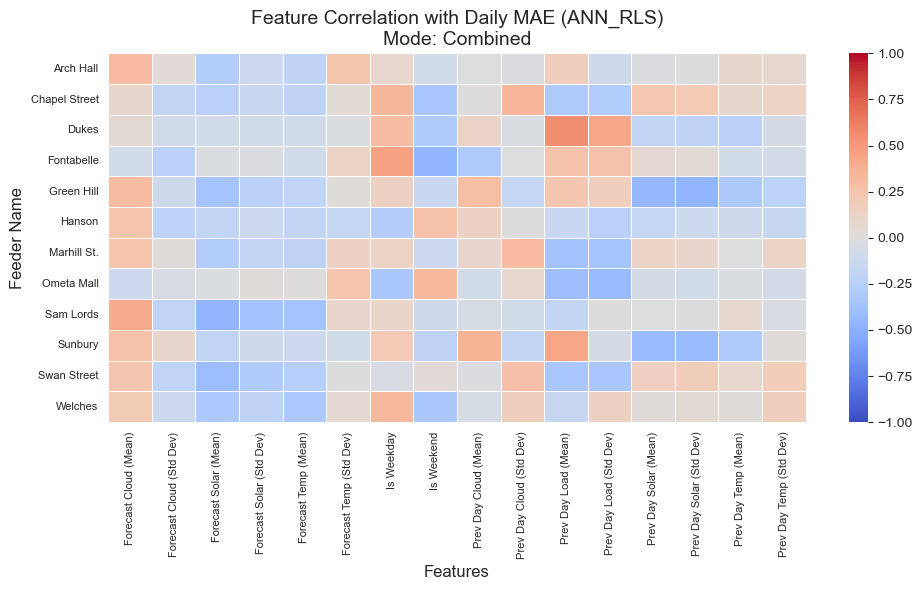

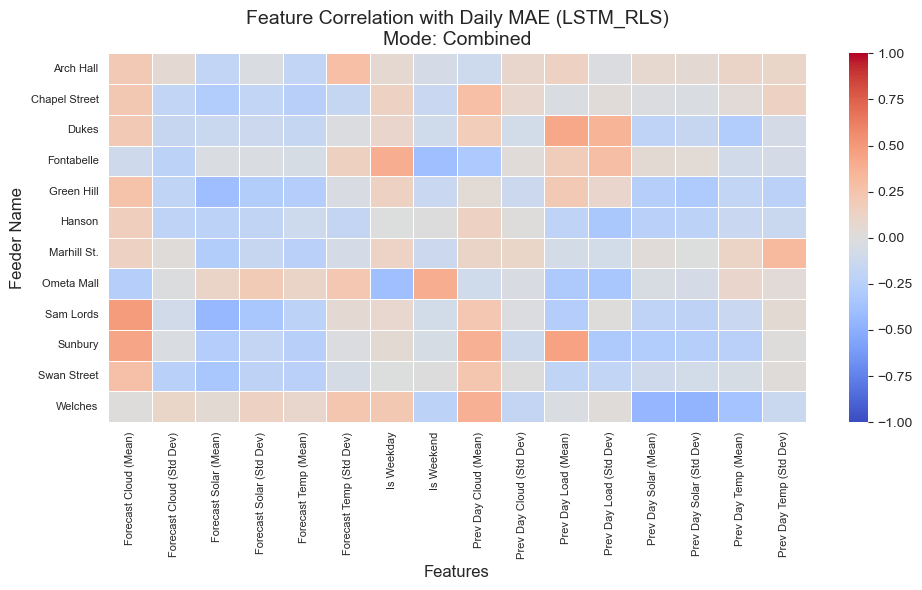

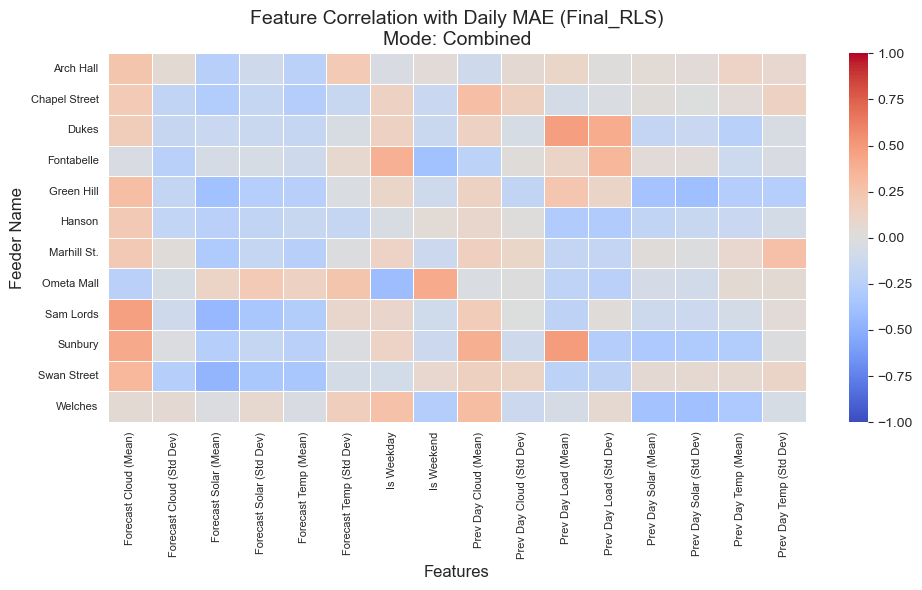

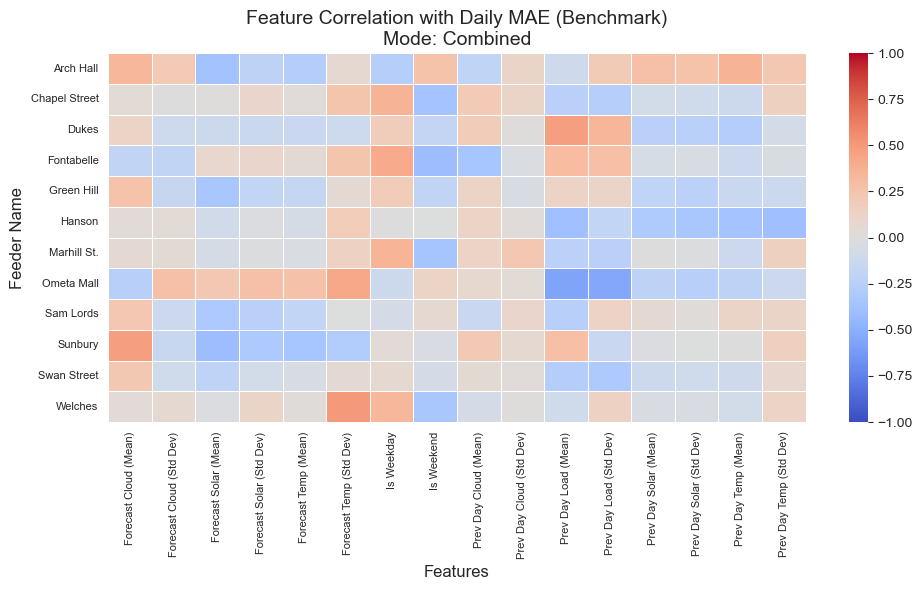


--- Table & Heatmap Generation Complete ---


--- Top 3 Positively Correlated Features for Model: ANN_RLS (Mode: Combined) ---

High Capacity Feeders:
Feeder Name            Feature #1              Feature #2               Feature #3
  Arch Hall Forecast Cloud (Mean) Forecast Temp (Std Dev)     Prev Day Load (Mean)
      Dukes  Prev Day Load (Mean) Prev Day Load (Std Dev)               Is Weekday
 Fontabelle            Is Weekday Prev Day Load (Std Dev)     Prev Day Load (Mean)
 Green Hill Forecast Cloud (Mean)   Prev Day Cloud (Mean)     Prev Day Load (Mean)
  Sam Lords Forecast Cloud (Mean)              Is Weekday  Forecast Temp (Std Dev)
    Sunbury  Prev Day Load (Mean)   Prev Day Cloud (Mean)    Forecast Cloud (Mean)
    Welches            Is Weekday   Forecast Cloud (Mean) Prev Day Cloud (Std Dev)

Low Capacity Feeders:
  Feeder Name               Feature #1              Feature #2               Feature #3
Chapel Street Prev Day Cloud (Std Dev)              Is Weekday    Prev Da

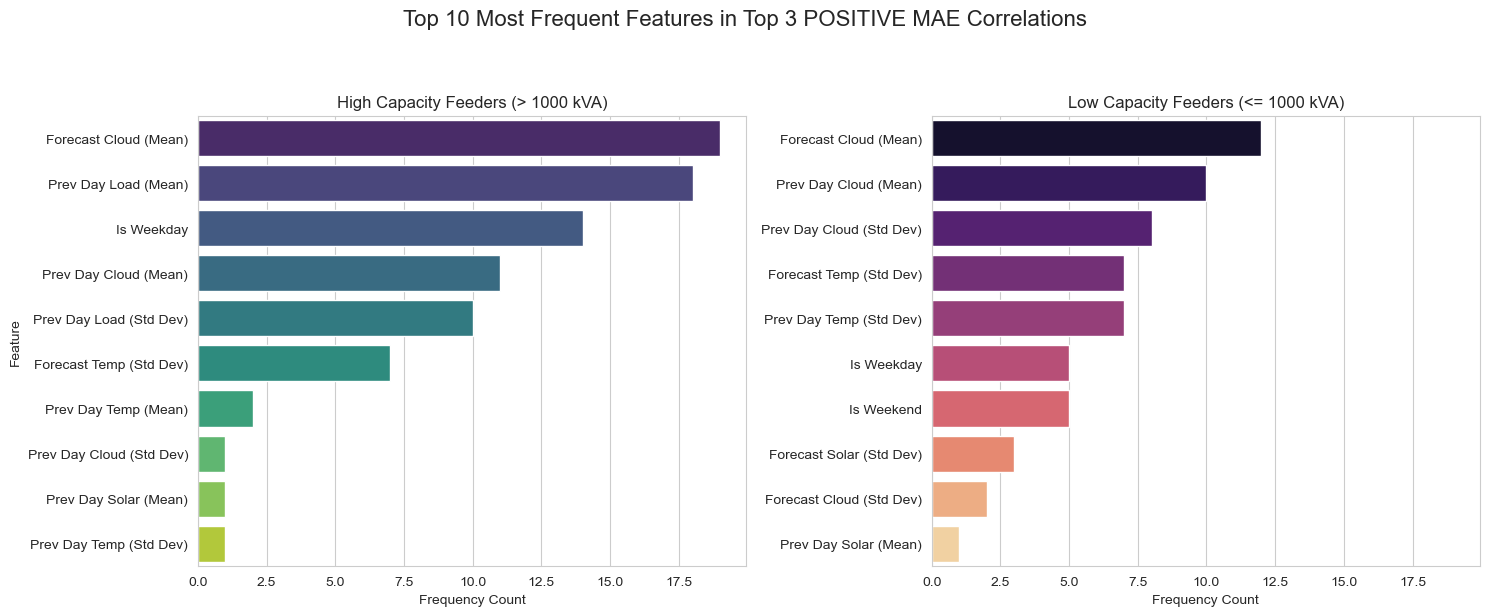


--- Calculating and Plotting Top 10 Most Frequent NEGATIVE Features ---


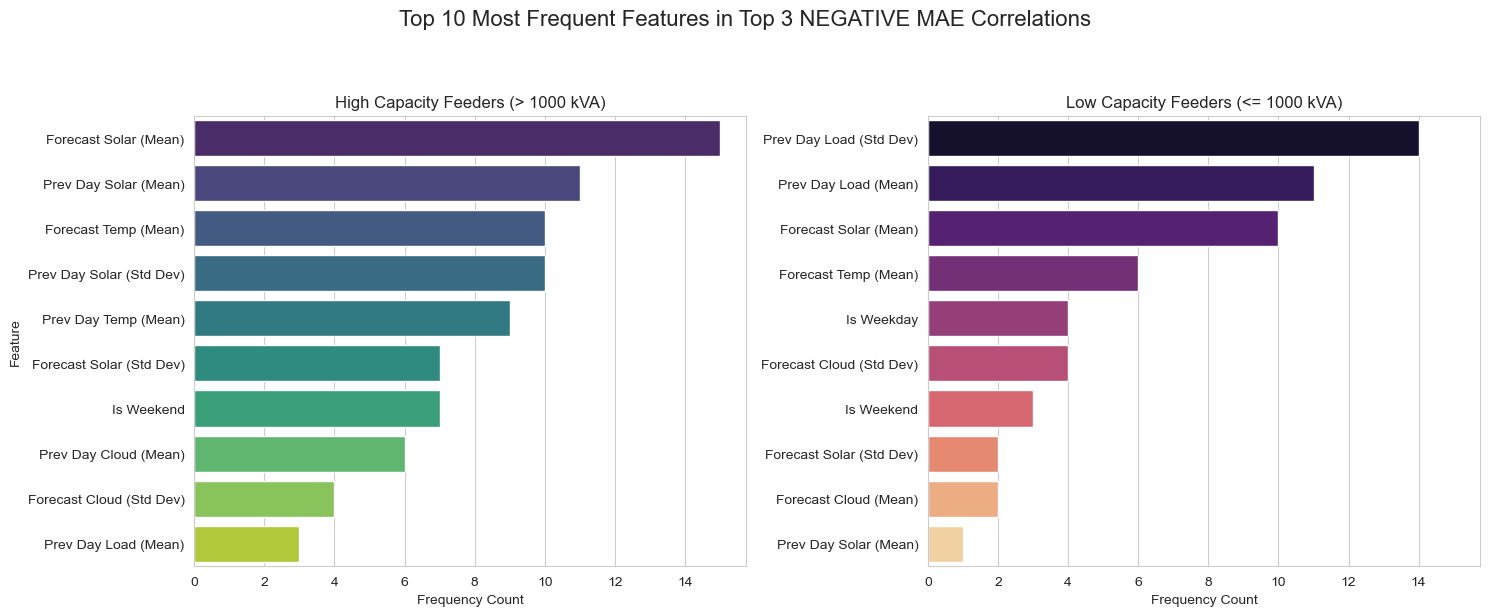

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter # For counting feature frequency

# Ignore simple warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

# --- Define Base Paths (Adjust if your script is located elsewhere) ---
BASE_PROJECT_PATH = Path("./../") # Path relative to the script location
DATA_PATH = BASE_PROJECT_PATH / "Data" / "Clustering_Data" / "Daytime"
RESULTS_PATH = DATA_PATH # Results are also under Data/Clustering_Data/Daytime/ according to user

# --- Feeder Capacities ---
FEEDER_CAPACITIES = {
    "Arch_Hall_ST2B13": 5594,
    "Chapel_Street_TY2B4": 100,
    "Dukes_ST2B15": 2409,
    "Fontabelle_1_TY2B7": 3099,
    "Green_Hill_WA2B6": 7816,
    "Hanson_(Belmont)_BE2B1": 546,
    "Marhill_St._TY2B8": 208,
    "Ometa_Mall_MA2B4": 455,
    "Sam_Lords_HA2B5": 4179,
    "Sunbury_HA2B2": 4648,
    "Swan_Street_TY2B6": 14,
    "Welches_WA2B2": 1211
}

# --- Feeder Name Mapping for Presentation ---
FEEDER_NAME_MAPPING = {
    "Arch_Hall_ST2B13": "Arch Hall",
    "Chapel_Street_TY2B4": "Chapel Street",
    "Dukes_ST2B15": "Dukes",
    "Fontabelle_1_TY2B7": "Fontabelle",
    "Green_Hill_WA2B6": "Green Hill",
    "Hanson_(Belmont)_BE2B1": "Hanson",
    "Marhill_St._TY2B8": "Marhill St.",
    "Ometa_Mall_MA2B4": "Ometa Mall",
    "Sam_Lords_HA2B5": "Sam Lords",
    "Sunbury_HA2B2": "Sunbury",
    "Swan_Street_TY2B6": "Swan Street",
    "Welches_WA2B2": "Welches"
}

# --- Feature Name Mapping for Presentation ---
FEATURE_NAME_MAPPING = {
    # Means
    "prev_historic_temperature_mean": "Prev Day Temp (Mean)",
    "cur_forecasted_temperature_mean": "Forecast Temp (Mean)",
    "prev_historic_solar_irradiance_mean": "Prev Day Solar (Mean)",
    "cur_forecasted_solar_irradiance_mean": "Forecast Solar (Mean)",
    "prev_historic_cloud_cover_mean": "Prev Day Cloud (Mean)",
    "cur_forecasted_cloud_cover_mean": "Forecast Cloud (Mean)",
    "prev_historic_net_load_demand_mean": "Prev Day Load (Mean)",
    # Standard Deviations
    "prev_historic_temperature_std": "Prev Day Temp (Std Dev)",
    "cur_forecasted_temperature_std": "Forecast Temp (Std Dev)",
    "prev_historic_solar_irradiance_std": "Prev Day Solar (Std Dev)",
    "cur_forecasted_solar_irradiance_std": "Forecast Solar (Std Dev)",
    "prev_historic_cloud_cover_std": "Prev Day Cloud (Std Dev)",
    "cur_forecasted_cloud_cover_std": "Forecast Cloud (Std Dev)",
    "prev_historic_net_load_demand_std": "Prev Day Load (Std Dev)",
    # Time Features
    "Is_Weekday": "Is Weekday",
    "Is_Weekend": "Is Weekend",
    "Is_Holiday": "Is Holiday"
}


# --- Capacity Threshold ---
HIGH_CAPACITY_THRESHOLD = 1000 # Example threshold in kVA (adjust as needed)

# --- Helper Function to Load and Preprocess Data (Unchanged) ---
def load_preprocess_feeder_data(feeder_name, dataset_type, models_to_analyze, actual_col_name="Actual"):
    """Loads features and results, calculates daily MAE for one feeder."""
    print(f"  Processing Feeder: {feeder_name}, Type: {dataset_type}...")

    results_folder = RESULTS_PATH / f"{dataset_type}_Results"
    features_folder = DATA_PATH / f"{dataset_type}_Features"

    results_path = results_folder / f"{feeder_name}_{dataset_type}_Results.csv"
    inputs_path = features_folder / f"{feeder_name}_X_{dataset_type}_Normalized.csv"

    if not results_path.is_file():
        print(f"    Warning: Results file not found: {results_path}")
        return None
    if not inputs_path.is_file():
        print(f"    Warning: Input features file not found: {inputs_path}")
        return None

    try:
        df_results = pd.read_csv(results_path, index_col=0, parse_dates=True)
        df_inputs = pd.read_csv(inputs_path, index_col=0, parse_dates=True)

        if df_results.index.name is None: df_results.index.name = "timestamp"
        if df_inputs.index.name is None: df_inputs.index.name = "timestamp"

        required_cols = models_to_analyze + [actual_col_name]
        missing_cols = [col for col in required_cols if col not in df_results.columns]
        if missing_cols:
            print(f"    Warning: Missing required columns in results file {results_path}: {missing_cols}")
            return None

        df_results["date_only"] = df_results.index.date
        daily_mae_list = []
        for model_name in models_to_analyze:
            abs_error_col = f"AbsError_{model_name}"
            daily_mae_col = f"Daily_MAE_{model_name}"
            df_results[abs_error_col] = (df_results[actual_col_name] - df_results[model_name]).abs()

            numeric_cols = df_results.select_dtypes(include=np.number).columns
            if abs_error_col in numeric_cols:
                daily_mae = df_results.groupby("date_only")[abs_error_col].mean().reset_index()
                daily_mae.rename(columns={abs_error_col: daily_mae_col, "date_only": "date"}, inplace=True)
                daily_mae["date"] = pd.to_datetime(daily_mae["date"])
                daily_mae_list.append(daily_mae.set_index("date"))
            else:
                 print(f"    Warning: AbsError column {abs_error_col} not numeric for {model_name}.")

        if not daily_mae_list:
            print("    Warning: No Daily MAE could be calculated.")
            return None

        merged_mae_df = pd.concat(daily_mae_list, axis=1)

        df_analysis = df_inputs.copy()
        df_analysis.index = df_analysis.index.normalize()
        df_analysis = df_analysis.join(merged_mae_df, how="inner")

        mae_cols_to_check = [f"Daily_MAE_{m}" for m in models_to_analyze if f"Daily_MAE_{m}" in df_analysis.columns]
        df_analysis.dropna(subset=mae_cols_to_check, inplace=True)

        if df_analysis.empty:
            print("    Warning: Analysis DataFrame empty after merging features and MAE.")
            return None

        return df_analysis

    except Exception as e:
        print(f"    Error processing {feeder_name} ({dataset_type}): {e}")
        return None


# --- Main Function ---
def generate_top_feature_tables(
    feeder_list: list,
    feeder_capacities: dict,
    feeder_name_mapping: dict, # Added feeder mapping
    feature_name_mapping: dict, # Added feature mapping
    mode: str, # "Validation", "Test", or "Combined"
    models_to_analyze: list = ["Final_RLS", "LSTM_RLS", "ANN_RLS", "Benchmark"],
    actual_col_name: str = "Actual",
    capacity_threshold: int = HIGH_CAPACITY_THRESHOLD
):
    """
    Generates tables of top 3 positively/negatively correlated features with Daily MAE,
    using presentation-friendly names and collecting data for heatmaps.
    """
    print(f"--- Generating Top Feature Tables & Correlation Data --- Mode: {mode} ---")
    all_feeder_top_positive_features = {model: {} for model in models_to_analyze}
    all_feeder_top_negative_features = {model: {} for model in models_to_analyze}
    per_feeder_correlations = {model: {} for model in models_to_analyze}

    for feeder_name in feeder_list:
        if feeder_name not in feeder_capacities:
             print(f"Warning: Capacity not defined for feeder '{feeder_name}'. Skipping.")
             continue

        df_combined = pd.DataFrame()
        # --- 1. Load Data based on Mode ---
        if mode == "Validation" or mode == "Combined":
            df_val = load_preprocess_feeder_data(feeder_name, "Validation", models_to_analyze, actual_col_name)
            if df_val is not None: df_combined = pd.concat([df_combined, df_val], axis=0)
        if mode == "Test" or mode == "Combined":
            df_test = load_preprocess_feeder_data(feeder_name, "Test", models_to_analyze, actual_col_name)
            if df_test is not None: df_combined = pd.concat([df_combined, df_test], axis=0)

        if df_combined.empty:
            print(f"  Skipping {feeder_name} due to data loading/processing issues.")
            continue

        df_combined = df_combined[~df_combined.index.duplicated(keep='first')]
        df_analysis = df_combined.copy()

        # --- 2. Feature Engineering (Means and Standard Deviations) ---
        print(f"  Feature Engineering for {feeder_name}...")
        feature_prefixes_multi_step = [
            "prev_historic_temperature", "cur_forecasted_temperature",
            "prev_historic_solar_irradiance", "cur_forecasted_solar_irradiance",
            "prev_historic_cloud_cover", "cur_forecasted_cloud_cover",
            "prev_historic_net_load_demand"
        ]
        weather_feature_means = []
        weather_feature_stds = []

        for prefix in feature_prefixes_multi_step:
            cols = [col for col in df_analysis.columns if col.startswith(prefix) and not (col.endswith("_mean") or col.endswith("_std"))]
            if cols:
                mean_col_name = f"{prefix}_mean"
                std_col_name = f"{prefix}_std"
                if mean_col_name not in df_analysis.columns: df_analysis[mean_col_name] = df_analysis[cols].mean(axis=1)
                if std_col_name not in df_analysis.columns: df_analysis[std_col_name] = df_analysis[cols].std(axis=1)
                weather_feature_means.append(mean_col_name)
                weather_feature_stds.append(std_col_name)

        time_features = []
        dow_5_exists = "cur_day_of_week_5" in df_analysis.columns
        dow_6_exists = "cur_day_of_week_6" in df_analysis.columns
        if dow_5_exists and dow_6_exists:
            df_analysis["Is_Weekend"] = ((df_analysis["cur_day_of_week_5"] == 1) | (df_analysis["cur_day_of_week_6"] == 1)).astype(int)
            df_analysis["Is_Weekday"] = 1 - df_analysis["Is_Weekend"]
            time_features.extend(["Is_Weekday", "Is_Weekend"])
        else:
            if "Is_Weekend" not in df_analysis.columns: df_analysis["Is_Weekend"] = 0
            if "Is_Weekday" not in df_analysis.columns: df_analysis["Is_Weekday"] = 0

        holiday_col_orig = "cur_is_holiday_0"
        if holiday_col_orig in df_analysis.columns:
            df_analysis["Is_Holiday"] = df_analysis[holiday_col_orig].astype(int)
            time_features.append("Is_Holiday") # Add 'Is_Holiday' to the list
        else:
             if "Is_Holiday" not in df_analysis.columns: df_analysis["Is_Holiday"] = 0

        # Final list of features for correlation (internal names)
        features_for_corr_internal = [tf for tf in time_features if df_analysis[tf].nunique() > 1] + \
                                     [wf for wf in weather_feature_means if wf in df_analysis.columns and df_analysis[wf].nunique() > 1] + \
                                     [ws for ws in weather_feature_stds if ws in df_analysis.columns and df_analysis[ws].nunique() > 1]

        if not features_for_corr_internal:
             print(f"  Warning: No features with variance found for correlation for feeder {feeder_name}.")
             continue

        # --- 3. Calculate Correlations, Find Top 3 Pos/Neg, Store Full Vector ---
        print(f"  Calculating correlations for {feeder_name}...")
        for model_name in models_to_analyze:
            mae_col = f"Daily_MAE_{model_name}"
            if mae_col not in df_analysis.columns: continue

            corr_cols = [mae_col] + features_for_corr_internal
            try:
                df_corr_subset = df_analysis[corr_cols].fillna(0)
                correlation_matrix = df_corr_subset.corr()
                mae_correlations = correlation_matrix[mae_col].drop(mae_col, axis=0).dropna()

                # Store the full correlation vector (using internal names for keys)
                per_feeder_correlations[model_name][feeder_name] = mae_correlations

                # --- Top 3 Positive ---
                top_3_positive = mae_correlations[mae_correlations > 0].nlargest(3)
                # RENAME features before storing
                top_pos_list = [feature_name_mapping.get(f, f) for f in top_3_positive.index] # Map names
                while len(top_pos_list) < 3: top_pos_list.append("N/A")
                all_feeder_top_positive_features[model_name][feeder_name] = top_pos_list

                # --- Top 3 Negative (for frequency plot) & Top 5 Negative (for printing) ---
                neg_corrs = mae_correlations[mae_correlations < 0].sort_values()
                top_5_negative = neg_corrs.head(5)
                # RENAME features before storing
                top_3_neg_list = [feature_name_mapping.get(f, f) for f in neg_corrs.head(3).index] # Map names
                while len(top_3_neg_list) < 3: top_3_neg_list.append("N/A")
                all_feeder_top_negative_features[model_name][feeder_name] = top_3_neg_list

                # Print Top 5 Negative for this feeder/model (using RENAMED features)
                print(f"    Top 5 Negative Correlations ({model_name} @ {feeder_name}):")
                if not top_5_negative.empty:
                    # Rename index for printing
                    renamed_top_5_neg = top_5_negative.rename(index=feature_name_mapping)
                    print(renamed_top_5_neg.round(3))
                else:
                    print("      None found.")

            except Exception as e:
                print(f"    Error calculating correlation for {feeder_name}, {model_name}: {e}")


    # --- 4. Organize into High/Low Capacity Tables (Top Positive Features) ---
    output_tables_pos = {model: {"High Capacity": [], "Low Capacity": []} for model in models_to_analyze}
    for model_name in models_to_analyze:
        for feeder_name_internal, top_features_renamed in all_feeder_top_positive_features[model_name].items():
            capacity = feeder_capacities.get(feeder_name_internal, -1)
            # RENAME feeder name for the table
            feeder_name_display = feeder_name_mapping.get(feeder_name_internal, feeder_name_internal)
            row_data = {"Feeder Name": feeder_name_display, "Feature #1": top_features_renamed[0], "Feature #2": top_features_renamed[1], "Feature #3": top_features_renamed[2]}
            if capacity > capacity_threshold: output_tables_pos[model_name]["High Capacity"].append(row_data)
            elif capacity >= 0: output_tables_pos[model_name]["Low Capacity"].append(row_data)
        output_tables_pos[model_name]["High Capacity"] = pd.DataFrame(output_tables_pos[model_name]["High Capacity"])
        output_tables_pos[model_name]["Low Capacity"] = pd.DataFrame(output_tables_pos[model_name]["Low Capacity"])

    # --- 5. Generate Correlation Heatmaps ---
    print("\n--- Generating Correlation Heatmaps per Model ---")
    sns.set_style("whitegrid")
    for model_name in models_to_analyze:
        if not per_feeder_correlations[model_name]:
            print(f"  Skipping heatmap for {model_name}: No correlation data collected.")
            continue

        heatmap_df = pd.DataFrame(per_feeder_correlations[model_name]).T
        heatmap_df = heatmap_df.dropna(axis=1, how='all')

        if heatmap_df.empty:
            print(f"  Skipping heatmap for {model_name}: DataFrame is empty after processing.")
            continue

        # RENAME columns (features) using the mapping
        heatmap_df.rename(columns=feature_name_mapping, inplace=True)
        # RENAME index (feeders) using the mapping
        heatmap_df.rename(index=feeder_name_mapping, inplace=True)

        # Sort columns (renamed features) alphabetically
        heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)
        # Sort rows (renamed feeders) alphabetically
        heatmap_df = heatmap_df.sort_index()

        n_feeders = len(heatmap_df)
        n_features = len(heatmap_df.columns)
        fig_width = max(10, n_features * 0.5)
        fig_height = max(6, n_feeders * 0.4)

        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(heatmap_df, cmap="coolwarm", annot=False, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, cbar=True)
        plt.title(f"Feature Correlation with Daily MAE ({model_name})\nMode: {mode}", fontsize=14)
        plt.xlabel("Features", fontsize=12)
        plt.ylabel("Feeder Name", fontsize=12)
        plt.xticks(rotation=90, fontsize=8)
        plt.yticks(rotation=0, fontsize=8)
        plt.tight_layout()
        plt.show()

    print("\n--- Table & Heatmap Generation Complete ---")
    return output_tables_pos, all_feeder_top_negative_features # Return negative features dict for plotting


# --- Function to Plot Most Significant Positive Features (Uses Renamed Features) ---
def plot_most_significant_features(generated_tables: dict, capacity_threshold: int, top_n: int = 7):
    """ Plots frequency of top 3 positive features (using renamed features) """
    print(f"\n--- Calculating and Plotting Top {top_n} Most Frequent POSITIVE Features ---")
    # ... (rest of the function remains the same as it uses the already renamed features from generated_tables) ...
    sns.set_style("whitegrid")
    high_cap_all_features = []
    low_cap_all_features = []

    for model in generated_tables:
        # Check if DataFrame is not empty before iterating
        if not generated_tables[model]["High Capacity"].empty:
            for _, row in generated_tables[model]["High Capacity"].iterrows():
                high_cap_all_features.extend([row["Feature #1"], row["Feature #2"], row["Feature #3"]])
        if not generated_tables[model]["Low Capacity"].empty:
            for _, row in generated_tables[model]["Low Capacity"].iterrows():
                low_cap_all_features.extend([row["Feature #1"], row["Feature #2"], row["Feature #3"]])

    high_cap_counts = Counter(f for f in high_cap_all_features if f != "N/A")
    low_cap_counts = Counter(f for f in low_cap_all_features if f != "N/A")

    df_high_freq = pd.DataFrame(high_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])
    df_low_freq = pd.DataFrame(low_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])

    fig, axes = plt.subplots(1, 2, figsize=(15, max(5, top_n * 0.6)), sharex=True)
    fig.suptitle(f'Top {top_n} Most Frequent Features in Top 3 POSITIVE MAE Correlations', fontsize=16, y=1.02)

    if not df_high_freq.empty:
        sns.barplot(ax=axes[0], x='Frequency', y='Feature', data=df_high_freq, palette='viridis')
        axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)')
        axes[0].set_xlabel("Frequency Count"); axes[0].set_ylabel("Feature")
    else:
        axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)\n(No features found)')
        axes[0].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[0].transAxes)

    if not df_low_freq.empty:
        sns.barplot(ax=axes[1], x='Frequency', y='Feature', data=df_low_freq, palette='magma')
        axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)')
        axes[1].set_xlabel("Frequency Count"); axes[1].set_ylabel("")
    else:
        axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)\n(No features found)')
        axes[1].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[1].transAxes)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# --- Function to Plot Most Significant Negative Features (Uses Renamed Features) ---
def plot_most_significant_negative_features(all_negative_features: dict, feeder_capacities: dict, feeder_name_mapping: dict, capacity_threshold: int, top_n: int = 7):
    """ Plots frequency of top 3 negative features (using renamed features) """
    print(f"\n--- Calculating and Plotting Top {top_n} Most Frequent NEGATIVE Features ---")
    # ... (rest of the function remains the same as it uses the already renamed features from all_negative_features) ...
    sns.set_style("whitegrid")
    high_cap_all_features = []
    low_cap_all_features = []

    for model in all_negative_features:
        for feeder_name_internal, features_renamed in all_negative_features[model].items():
            capacity = feeder_capacities.get(feeder_name_internal, -1)
            # Use internal name for capacity check, but features are already renamed
            if capacity > capacity_threshold:
                high_cap_all_features.extend(features_renamed)
            elif capacity >= 0:
                low_cap_all_features.extend(features_renamed)

    high_cap_counts = Counter(f for f in high_cap_all_features if f != "N/A")
    low_cap_counts = Counter(f for f in low_cap_all_features if f != "N/A")

    df_high_freq = pd.DataFrame(high_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])
    df_low_freq = pd.DataFrame(low_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])

    fig, axes = plt.subplots(1, 2, figsize=(15, max(5, top_n * 0.6)), sharex=True)
    fig.suptitle(f'Top {top_n} Most Frequent Features in Top 3 NEGATIVE MAE Correlations', fontsize=16, y=1.02)

    if not df_high_freq.empty:
        sns.barplot(ax=axes[0], x='Frequency', y='Feature', data=df_high_freq, palette='viridis')
        axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)')
        axes[0].set_xlabel("Frequency Count"); axes[0].set_ylabel("Feature")
    else:
        axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)\n(No features found)')
        axes[0].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[0].transAxes)

    if not df_low_freq.empty:
        sns.barplot(ax=axes[1], x='Frequency', y='Feature', data=df_low_freq, palette='magma')
        axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)')
        axes[1].set_xlabel("Frequency Count"); axes[1].set_ylabel("")
    else:
        axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)\n(No features found)')
        axes[1].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[1].transAxes)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# --- Main Execution Block ---
if __name__ == "__main__":

    all_feeders = list(FEEDER_CAPACITIES.keys())
    analysis_mode = "Combined" # Choose "Validation", "Test", or "Combined"

    # Generate tables and collect correlation data
    output_tables_pos, all_neg_features_dict = generate_top_feature_tables( # Unpack only needed return values
        feeder_list=all_feeders,
        feeder_capacities=FEEDER_CAPACITIES,
        feeder_name_mapping=FEEDER_NAME_MAPPING, # Pass mapping
        feature_name_mapping=FEATURE_NAME_MAPPING, # Pass mapping
        mode=analysis_mode,
        models_to_analyze=["ANN_RLS", "LSTM_RLS", "Final_RLS", "Benchmark"]
    )

    # --- Display Sample Output Table for ANN_RLS (Top Positive) ---
    target_model = "ANN_RLS"
    print(f"\n\n--- Top 3 Positively Correlated Features for Model: {target_model} (Mode: {analysis_mode}) ---")
    if target_model in output_tables_pos:
        print("\nHigh Capacity Feeders:")
        if not output_tables_pos[target_model]["High Capacity"].empty:
            print(output_tables_pos[target_model]["High Capacity"].to_string(index=False))
        else: print("No high capacity feeders processed or found.")
        print("\nLow Capacity Feeders:")
        if not output_tables_pos[target_model]["Low Capacity"].empty:
            print(output_tables_pos[target_model]["Low Capacity"].to_string(index=False))
        else: print("No low capacity feeders processed or found.")
    else: print(f"No results found for model {target_model}.")

    # --- Plot Overall Most Significant Features (Positive and Negative) ---
    if output_tables_pos:
        plot_most_significant_features(output_tables_pos, HIGH_CAPACITY_THRESHOLD, top_n=10)
    else: print("\nSkipping most significant positive feature plot as no tables were generated.")

    if all_neg_features_dict:
        plot_most_significant_negative_features(all_neg_features_dict, FEEDER_CAPACITIES, FEEDER_NAME_MAPPING, HIGH_CAPACITY_THRESHOLD, top_n=10)
    else: print("\nSkipping most significant negative feature plot as no data was collected.")

--- Generating Analysis Results --- Mode: Combined ---
  Processing Feeder: Arch_Hall_ST2B13, Type: Validation...
  Processing Feeder: Arch_Hall_ST2B13, Type: Test...
  Calculating correlations for Arch_Hall_ST2B13...
  Processing Feeder: Chapel_Street_TY2B4, Type: Validation...
  Processing Feeder: Chapel_Street_TY2B4, Type: Test...
  Calculating correlations for Chapel_Street_TY2B4...
  Processing Feeder: Dukes_ST2B15, Type: Validation...
  Processing Feeder: Dukes_ST2B15, Type: Test...
  Calculating correlations for Dukes_ST2B15...
  Processing Feeder: Fontabelle_1_TY2B7, Type: Validation...
  Processing Feeder: Fontabelle_1_TY2B7, Type: Test...
  Calculating correlations for Fontabelle_1_TY2B7...
  Processing Feeder: Green_Hill_WA2B6, Type: Validation...
  Processing Feeder: Green_Hill_WA2B6, Type: Test...
  Calculating correlations for Green_Hill_WA2B6...
  Processing Feeder: Hanson_(Belmont)_BE2B1, Type: Validation...
  Processing Feeder: Hanson_(Belmont)_BE2B1, Type: Test...
  C

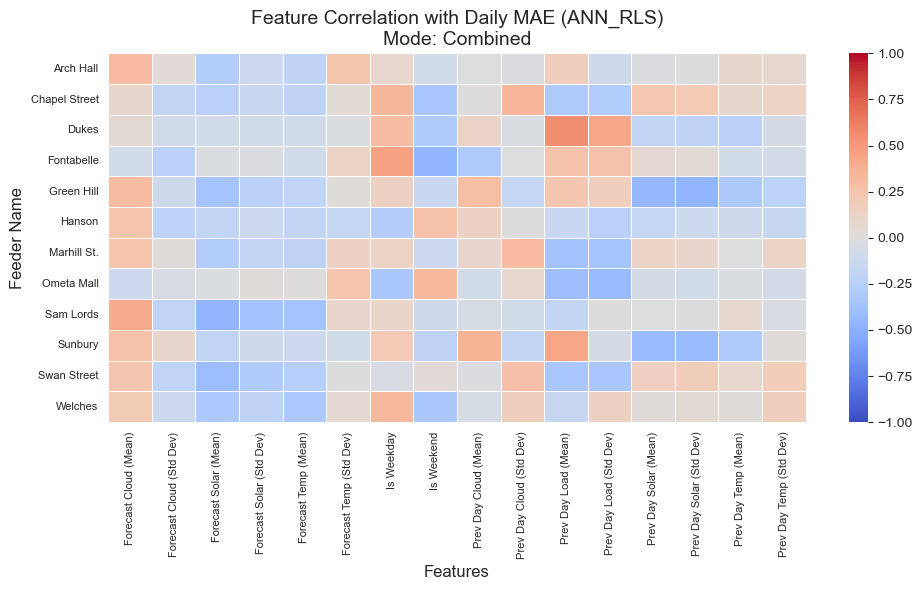

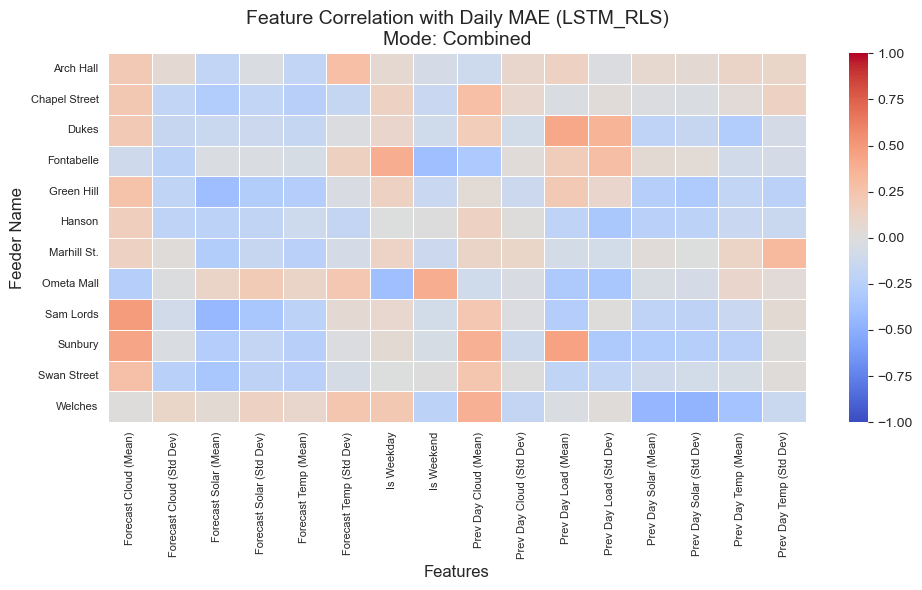

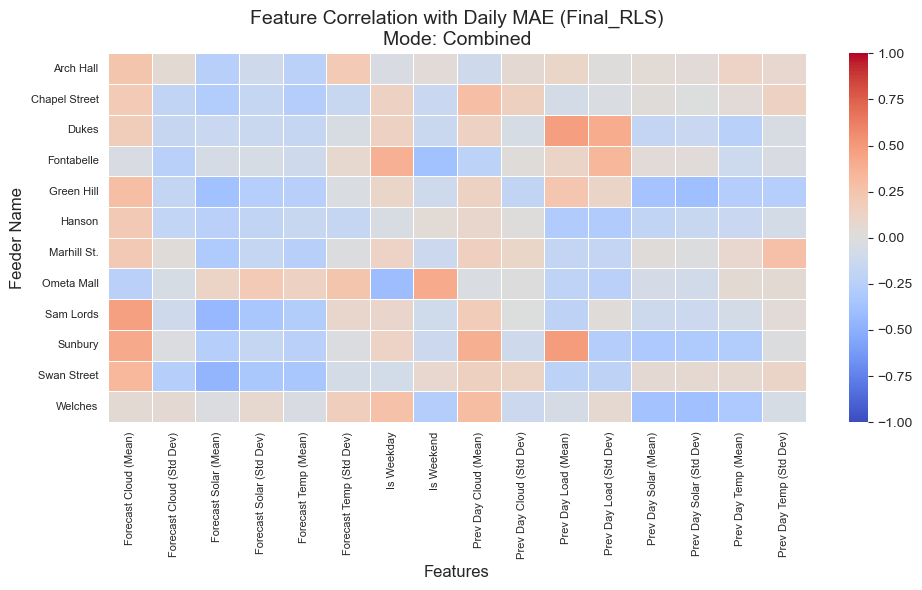

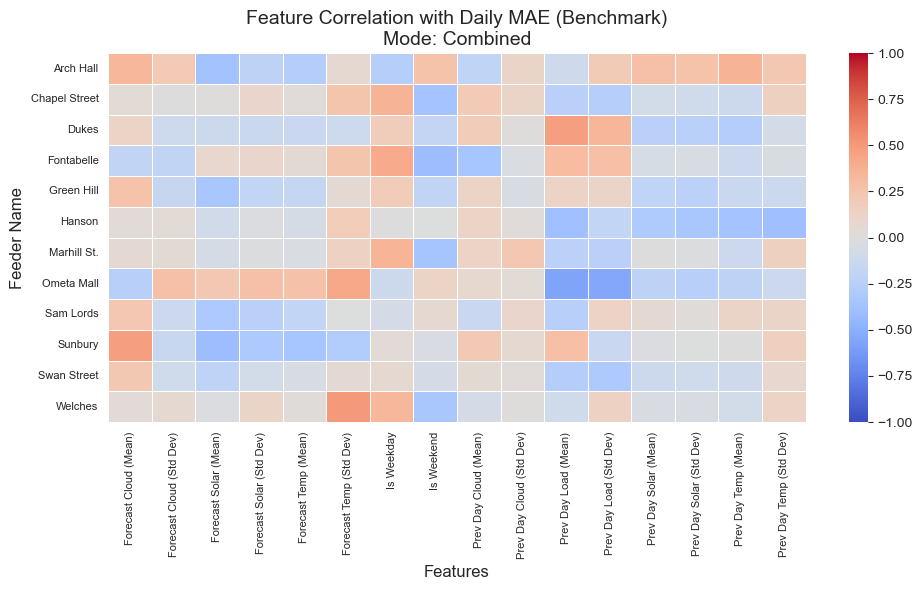


--- Analysis Function Complete ---


--- Top 3 Positively Correlated Features for Model: ANN_RLS (Mode: Combined) ---

High Capacity Feeders:
Feeder Name            Feature #1              Feature #2               Feature #3
  Arch Hall Forecast Cloud (Mean) Forecast Temp (Std Dev)     Prev Day Load (Mean)
      Dukes  Prev Day Load (Mean) Prev Day Load (Std Dev)               Is Weekday
 Fontabelle            Is Weekday Prev Day Load (Std Dev)     Prev Day Load (Mean)
 Green Hill Forecast Cloud (Mean)   Prev Day Cloud (Mean)     Prev Day Load (Mean)
  Sam Lords Forecast Cloud (Mean)              Is Weekday  Forecast Temp (Std Dev)
    Sunbury  Prev Day Load (Mean)   Prev Day Cloud (Mean)    Forecast Cloud (Mean)
    Welches            Is Weekday   Forecast Cloud (Mean) Prev Day Cloud (Std Dev)

Low Capacity Feeders:
  Feeder Name               Feature #1              Feature #2               Feature #3
Chapel Street Prev Day Cloud (Std Dev)              Is Weekday    Prev Day Solar (

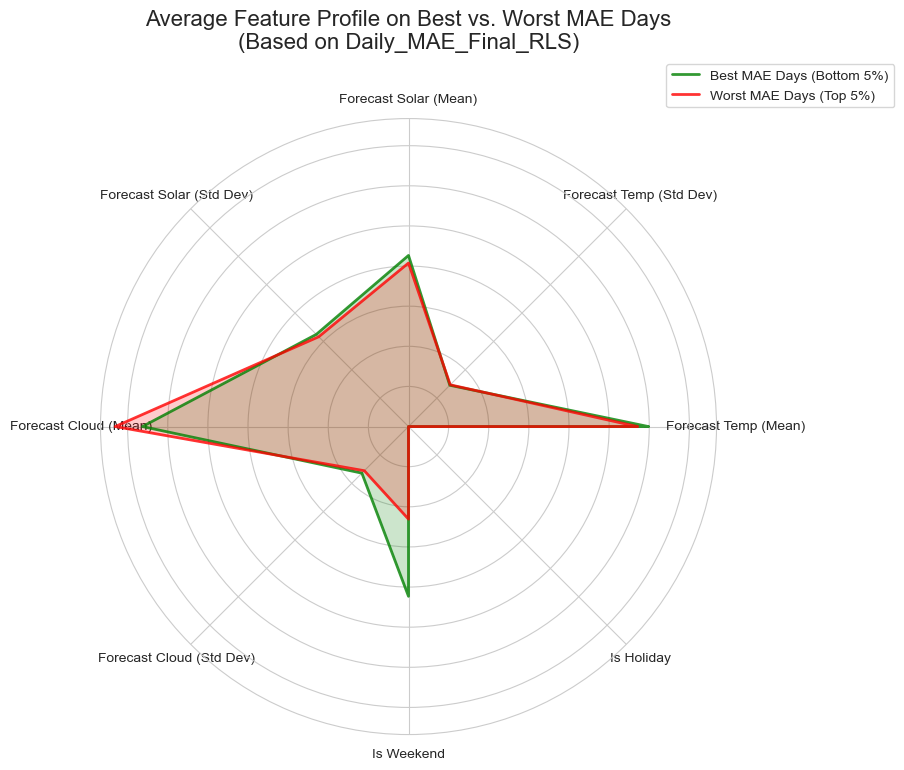

  Generating Boxplots...


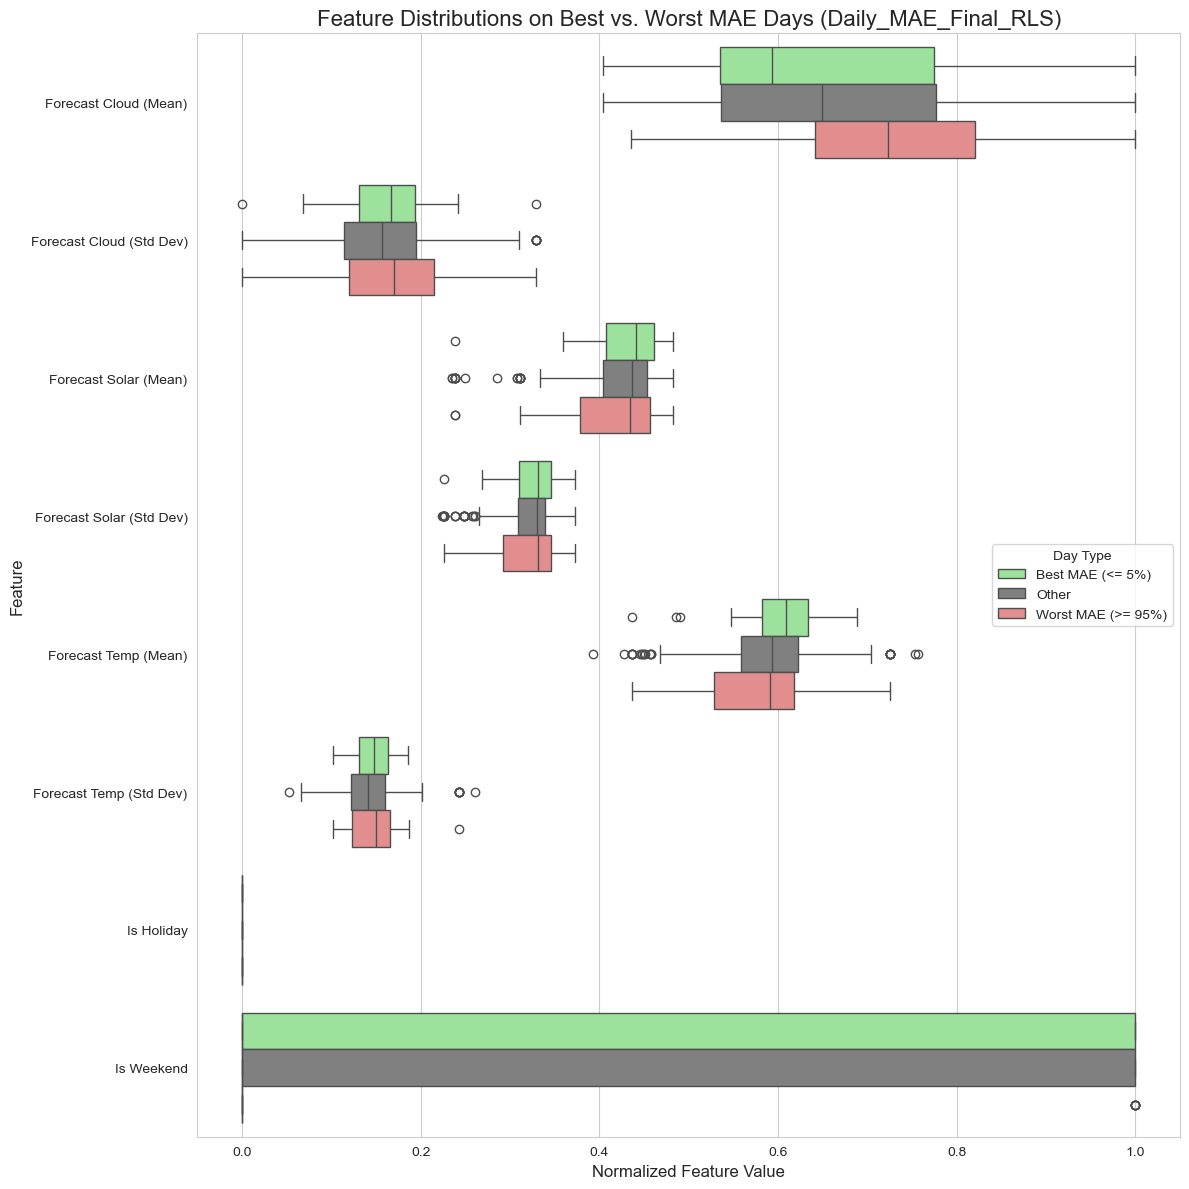


--- Calculating and Plotting Top 10 Most Frequent POSITIVE Features ---


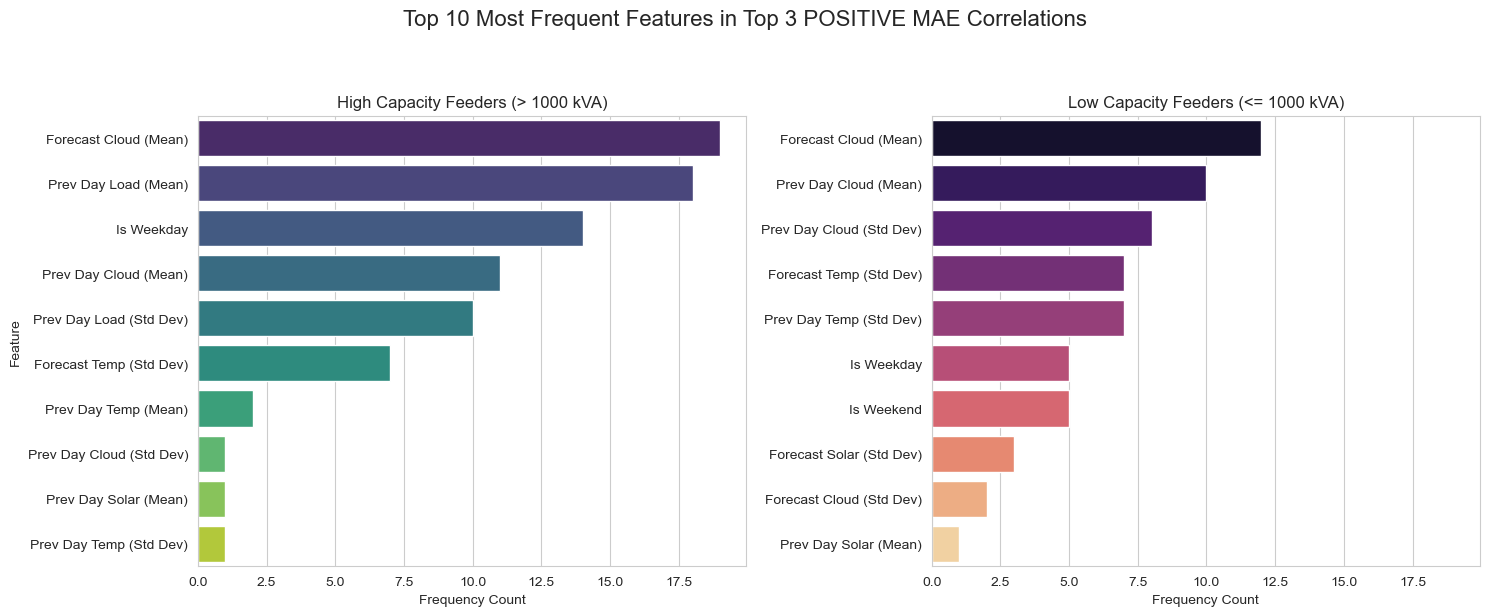


--- Calculating and Plotting Top 10 Most Frequent NEGATIVE Features ---


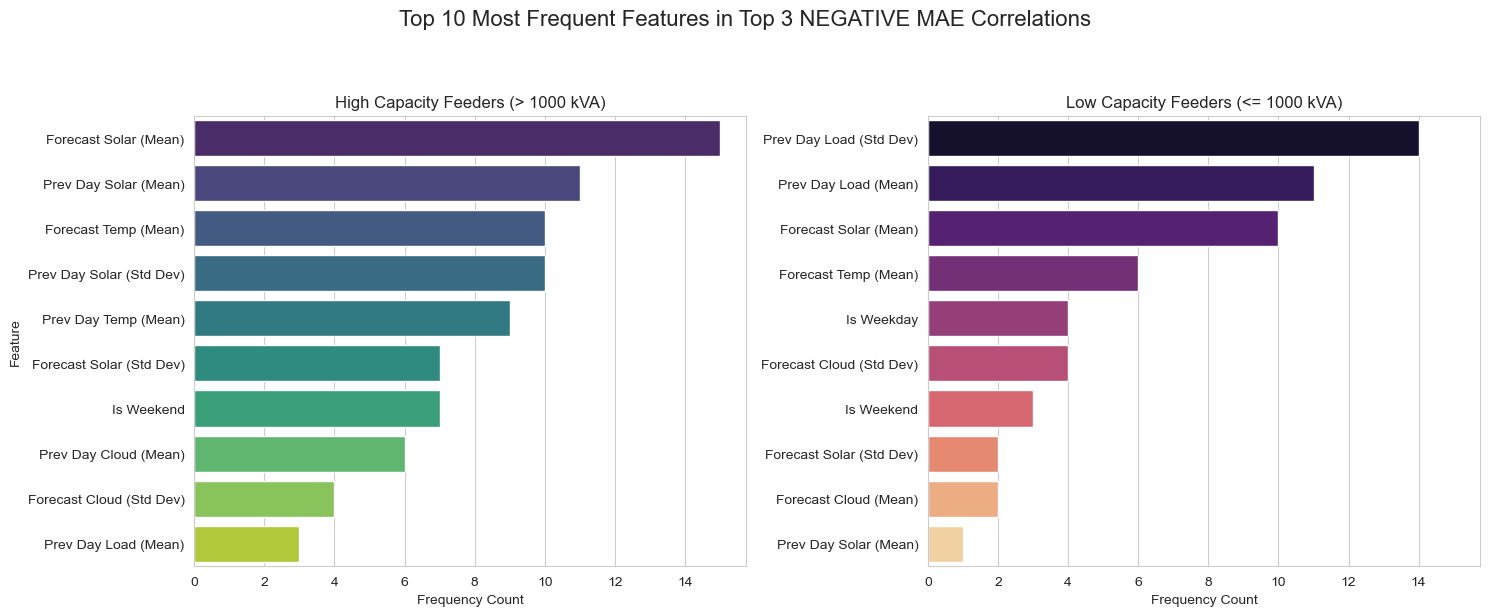

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math # Needed for radar chart

# --- (Keep previous setup: Paths, Capacities, Mappings, Threshold) ---
# --- Define Base Paths (Adjust if your script is located elsewhere) ---
BASE_PROJECT_PATH = Path("./../") # Path relative to the script location
DATA_PATH = BASE_PROJECT_PATH / "Data" / "Clustering_Data" / "Daytime"
RESULTS_PATH = DATA_PATH # Results are also under Data/Clustering_Data/Daytime/ according to user

# --- Feeder Capacities ---
FEEDER_CAPACITIES = {
    "Arch_Hall_ST2B13": 5594, "Chapel_Street_TY2B4": 100, "Dukes_ST2B15": 2409,
    "Fontabelle_1_TY2B7": 3099, "Green_Hill_WA2B6": 7816, "Hanson_(Belmont)_BE2B1": 546,
    "Marhill_St._TY2B8": 208, "Ometa_Mall_MA2B4": 455, "Sam_Lords_HA2B5": 4179,
    "Sunbury_HA2B2": 4648, "Swan_Street_TY2B6": 14, "Welches_WA2B2": 1211
}
# --- Feeder Name Mapping for Presentation ---
FEEDER_NAME_MAPPING = {
    "Arch_Hall_ST2B13": "Arch Hall", "Chapel_Street_TY2B4": "Chapel Street", "Dukes_ST2B15": "Dukes",
    "Fontabelle_1_TY2B7": "Fontabelle", "Green_Hill_WA2B6": "Green Hill", "Hanson_(Belmont)_BE2B1": "Hanson",
    "Marhill_St._TY2B8": "Marhill St.", "Ometa_Mall_MA2B4": "Ometa Mall", "Sam_Lords_HA2B5": "Sam Lords",
    "Sunbury_HA2B2": "Sunbury", "Swan_Street_TY2B6": "Swan Street", "Welches_WA2B2": "Welches"
}
# --- Feature Name Mapping for Presentation ---
FEATURE_NAME_MAPPING = {
    "prev_historic_temperature_mean": "Prev Day Temp (Mean)", "cur_forecasted_temperature_mean": "Forecast Temp (Mean)",
    "prev_historic_solar_irradiance_mean": "Prev Day Solar (Mean)", "cur_forecasted_solar_irradiance_mean": "Forecast Solar (Mean)",
    "prev_historic_cloud_cover_mean": "Prev Day Cloud (Mean)", "cur_forecasted_cloud_cover_mean": "Forecast Cloud (Mean)",
    "prev_historic_net_load_demand_mean": "Prev Day Load (Mean)",
    "prev_historic_temperature_std": "Prev Day Temp (Std Dev)", "cur_forecasted_temperature_std": "Forecast Temp (Std Dev)",
    "prev_historic_solar_irradiance_std": "Prev Day Solar (Std Dev)", "cur_forecasted_solar_irradiance_std": "Forecast Solar (Std Dev)",
    "prev_historic_cloud_cover_std": "Prev Day Cloud (Std Dev)", "cur_forecasted_cloud_cover_std": "Forecast Cloud (Std Dev)",
    "prev_historic_net_load_demand_std": "Prev Day Load (Std Dev)",
    "Is_Weekday": "Is Weekday", "Is_Weekend": "Is Weekend", "Is_Holiday": "Is Holiday"
}
# --- Capacity Threshold ---
HIGH_CAPACITY_THRESHOLD = 1000

# --- Helper Function load_preprocess_feeder_data (Unchanged) ---
# ... (Keep the function from the previous version) ...
def load_preprocess_feeder_data(feeder_name, dataset_type, models_to_analyze, actual_col_name="Actual"):
    """Loads features and results, calculates daily MAE for one feeder."""
    print(f"  Processing Feeder: {feeder_name}, Type: {dataset_type}...")

    results_folder = RESULTS_PATH / f"{dataset_type}_Results"
    features_folder = DATA_PATH / f"{dataset_type}_Features"

    results_path = results_folder / f"{feeder_name}_{dataset_type}_Results.csv"
    inputs_path = features_folder / f"{feeder_name}_X_{dataset_type}_Normalized.csv"

    if not results_path.is_file():
        print(f"    Warning: Results file not found: {results_path}")
        return None
    if not inputs_path.is_file():
        print(f"    Warning: Input features file not found: {inputs_path}")
        return None

    try:
        df_results = pd.read_csv(results_path, index_col=0, parse_dates=True)
        df_inputs = pd.read_csv(inputs_path, index_col=0, parse_dates=True)

        if df_results.index.name is None: df_results.index.name = "timestamp"
        if df_inputs.index.name is None: df_inputs.index.name = "timestamp"

        required_cols = models_to_analyze + [actual_col_name]
        missing_cols = [col for col in required_cols if col not in df_results.columns]
        if missing_cols:
            print(f"    Warning: Missing required columns in results file {results_path}: {missing_cols}")
            return None

        df_results["date_only"] = df_results.index.date
        daily_mae_list = []
        for model_name in models_to_analyze:
            abs_error_col = f"AbsError_{model_name}"
            daily_mae_col = f"Daily_MAE_{model_name}"
            df_results[abs_error_col] = (df_results[actual_col_name] - df_results[model_name]).abs()

            numeric_cols = df_results.select_dtypes(include=np.number).columns
            if abs_error_col in numeric_cols:
                daily_mae = df_results.groupby("date_only")[abs_error_col].mean().reset_index()
                daily_mae.rename(columns={abs_error_col: daily_mae_col, "date_only": "date"}, inplace=True)
                daily_mae["date"] = pd.to_datetime(daily_mae["date"])
                daily_mae_list.append(daily_mae.set_index("date"))
            else:
                 print(f"    Warning: AbsError column {abs_error_col} not numeric for {model_name}.")

        if not daily_mae_list:
            print("    Warning: No Daily MAE could be calculated.")
            return None

        merged_mae_df = pd.concat(daily_mae_list, axis=1)

        df_analysis = df_inputs.copy()
        df_analysis.index = df_analysis.index.normalize()
        df_analysis = df_analysis.join(merged_mae_df, how="inner")

        mae_cols_to_check = [f"Daily_MAE_{m}" for m in models_to_analyze if f"Daily_MAE_{m}" in df_analysis.columns]
        df_analysis.dropna(subset=mae_cols_to_check, inplace=True)

        if df_analysis.empty:
            print("    Warning: Analysis DataFrame empty after merging features and MAE.")
            return None

        # Add feeder name column for later aggregation
        df_analysis['FeederName_Internal'] = feeder_name
        return df_analysis

    except Exception as e:
        print(f"    Error processing {feeder_name} ({dataset_type}): {e}")
        return None


# --- Main Analysis Function ---
def generate_analysis_results( # Renamed function
    feeder_list: list,
    feeder_capacities: dict,
    feeder_name_mapping: dict,
    feature_name_mapping: dict,
    mode: str,
    models_to_analyze: list = ["Final_RLS", "LSTM_RLS", "ANN_RLS", "Benchmark"],
    actual_col_name: str = "Actual",
    capacity_threshold: int = HIGH_CAPACITY_THRESHOLD
):
    """
    Performs analysis: generates top feature tables, collects correlation data,
    and returns a combined dataframe for scenario analysis.
    """
    print(f"--- Generating Analysis Results --- Mode: {mode} ---")
    all_feeder_top_positive_features = {model: {} for model in models_to_analyze}
    all_feeder_top_negative_features = {model: {} for model in models_to_analyze}
    per_feeder_correlations = {model: {} for model in models_to_analyze}
    all_feeder_data_list = [] # List to store dataframes from each feeder

    for feeder_name in feeder_list:
        if feeder_name not in feeder_capacities:
             print(f"Warning: Capacity not defined for feeder '{feeder_name}'. Skipping.")
             continue

        df_feeder_combined = pd.DataFrame()
        # --- 1. Load Data based on Mode ---
        if mode == "Validation" or mode == "Combined":
            df_val = load_preprocess_feeder_data(feeder_name, "Validation", models_to_analyze, actual_col_name)
            if df_val is not None: df_feeder_combined = pd.concat([df_feeder_combined, df_val], axis=0)
        if mode == "Test" or mode == "Combined":
            df_test = load_preprocess_feeder_data(feeder_name, "Test", models_to_analyze, actual_col_name)
            if df_test is not None: df_feeder_combined = pd.concat([df_feeder_combined, df_test], axis=0)

        if df_feeder_combined.empty:
            print(f"  Skipping {feeder_name} due to data loading/processing issues.")
            continue

        df_feeder_combined = df_feeder_combined[~df_feeder_combined.index.duplicated(keep='first')]
        df_analysis = df_feeder_combined.copy() # Use data for this specific feeder now

        # --- 2. Feature Engineering (for this feeder) ---
        # (Same feature engineering logic as before)
        feature_prefixes_multi_step = [
            "prev_historic_temperature", "cur_forecasted_temperature",
            "prev_historic_solar_irradiance", "cur_forecasted_solar_irradiance",
            "prev_historic_cloud_cover", "cur_forecasted_cloud_cover",
            "prev_historic_net_load_demand"
        ]
        weather_feature_means = []
        weather_feature_stds = []
        for prefix in feature_prefixes_multi_step:
             cols = [col for col in df_analysis.columns if col.startswith(prefix) and not (col.endswith("_mean") or col.endswith("_std"))]
             if cols:
                 mean_col_name = f"{prefix}_mean"; std_col_name = f"{prefix}_std"
                 if mean_col_name not in df_analysis.columns: df_analysis[mean_col_name] = df_analysis[cols].mean(axis=1)
                 if std_col_name not in df_analysis.columns: df_analysis[std_col_name] = df_analysis[cols].std(axis=1)
                 weather_feature_means.append(mean_col_name); weather_feature_stds.append(std_col_name)
        time_features = []
        dow_5_exists = "cur_day_of_week_5" in df_analysis.columns; dow_6_exists = "cur_day_of_week_6" in df_analysis.columns
        if dow_5_exists and dow_6_exists:
             df_analysis["Is_Weekend"] = ((df_analysis["cur_day_of_week_5"] == 1) | (df_analysis["cur_day_of_week_6"] == 1)).astype(int)
             df_analysis["Is_Weekday"] = 1 - df_analysis["Is_Weekend"]; time_features.extend(["Is_Weekday", "Is_Weekend"])
        else:
             if "Is_Weekend" not in df_analysis.columns: df_analysis["Is_Weekend"] = 0
             if "Is_Weekday" not in df_analysis.columns: df_analysis["Is_Weekday"] = 0
        holiday_col_orig = "cur_is_holiday_0"
        if holiday_col_orig in df_analysis.columns:
             df_analysis["Is_Holiday"] = df_analysis[holiday_col_orig].astype(int); time_features.append("Is_Holiday")
        else:
             if "Is_Holiday" not in df_analysis.columns: df_analysis["Is_Holiday"] = 0
        features_for_corr_internal = [tf for tf in time_features if df_analysis[tf].nunique() > 1] + \
                                     [wf for wf in weather_feature_means if wf in df_analysis.columns and df_analysis[wf].nunique() > 1] + \
                                     [ws for ws in weather_feature_stds if ws in df_analysis.columns and df_analysis[ws].nunique() > 1]
        if not features_for_corr_internal: continue # Skip feeder if no features

        # Add the processed data for this feeder to the list for later combination
        all_feeder_data_list.append(df_analysis)

        # --- 3. Calculate Per-Feeder Correlations & Top Features ---
        print(f"  Calculating correlations for {feeder_name}...")
        for model_name in models_to_analyze:
            mae_col = f"Daily_MAE_{model_name}"
            if mae_col not in df_analysis.columns: continue
            corr_cols = [mae_col] + features_for_corr_internal
            try:
                df_corr_subset = df_analysis[corr_cols].fillna(0)
                correlation_matrix = df_corr_subset.corr()
                mae_correlations = correlation_matrix[mae_col].drop(mae_col, axis=0).dropna()
                per_feeder_correlations[model_name][feeder_name] = mae_correlations # Store raw correlations

                # Top 3 Positive (Store Renamed)
                top_3_positive = mae_correlations[mae_correlations > 0].nlargest(3)
                top_pos_list = [feature_name_mapping.get(f, f) for f in top_3_positive.index]
                while len(top_pos_list) < 3: top_pos_list.append("N/A")
                all_feeder_top_positive_features[model_name][feeder_name] = top_pos_list

                # Top 3 Negative (Store Renamed) & Print Top 5 Negative (Renamed)
                neg_corrs = mae_correlations[mae_correlations < 0].sort_values()
                top_5_negative = neg_corrs.head(5)
                top_3_neg_list = [feature_name_mapping.get(f, f) for f in neg_corrs.head(3).index]
                while len(top_3_neg_list) < 3: top_3_neg_list.append("N/A")
                all_feeder_top_negative_features[model_name][feeder_name] = top_3_neg_list
                # print(f"    Top 5 Negative Correlations ({model_name} @ {feeder_name}):") # Less verbose
                # if not top_5_negative.empty: print(top_5_negative.rename(index=feature_name_mapping).round(3))
                # else: print("      None found.")
            except Exception as e: print(f"    Error calculating correlation for {feeder_name}, {model_name}: {e}")

    # --- Combine data from all feeders ---
    if not all_feeder_data_list:
        print("Error: No feeder data was successfully processed. Cannot perform combined analysis.")
        return None, None, None, None # Return Nones if no data

    df_all_analysis = pd.concat(all_feeder_data_list, axis=0)
    print(f"\nCombined DataFrame shape for scenario analysis: {df_all_analysis.shape}")

    # --- 4. Organize into High/Low Capacity Tables (Top Positive Features) ---
    # (Same logic as before, using all_feeder_top_positive_features)
    output_tables_pos = {model: {"High Capacity": [], "Low Capacity": []} for model in models_to_analyze}
    for model_name in models_to_analyze:
        for feeder_name_internal, top_features_renamed in all_feeder_top_positive_features[model_name].items():
            capacity = feeder_capacities.get(feeder_name_internal, -1)
            feeder_name_display = feeder_name_mapping.get(feeder_name_internal, feeder_name_internal)
            row_data = {"Feeder Name": feeder_name_display, "Feature #1": top_features_renamed[0], "Feature #2": top_features_renamed[1], "Feature #3": top_features_renamed[2]}
            if capacity > capacity_threshold: output_tables_pos[model_name]["High Capacity"].append(row_data)
            elif capacity >= 0: output_tables_pos[model_name]["Low Capacity"].append(row_data)
        output_tables_pos[model_name]["High Capacity"] = pd.DataFrame(output_tables_pos[model_name]["High Capacity"])
        output_tables_pos[model_name]["Low Capacity"] = pd.DataFrame(output_tables_pos[model_name]["Low Capacity"])


    # --- 5. Generate Correlation Heatmaps (Per Feeder - Unchanged) ---
    # (Keep the heatmap generation logic from the previous version)
    print("\n--- Generating Correlation Heatmaps per Model ---")
    sns.set_style("whitegrid")
    for model_name in models_to_analyze:
        if not per_feeder_correlations[model_name]: continue
        heatmap_df = pd.DataFrame(per_feeder_correlations[model_name]).T
        heatmap_df = heatmap_df.dropna(axis=1, how='all')
        if heatmap_df.empty: continue

        heatmap_df.rename(columns=feature_name_mapping, inplace=True)
        heatmap_df.rename(index=feeder_name_mapping, inplace=True)
        heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)
        heatmap_df = heatmap_df.sort_index()

        n_feeders = len(heatmap_df); n_features = len(heatmap_df.columns)
        fig_width = max(10, n_features * 0.5); fig_height = max(6, n_feeders * 0.4)
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(heatmap_df, cmap="coolwarm", annot=False, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, cbar=True)
        plt.title(f"Feature Correlation with Daily MAE ({model_name})\nMode: {mode}", fontsize=14)
        plt.xlabel("Features", fontsize=12); plt.ylabel("Feeder Name", fontsize=12)
        plt.xticks(rotation=90, fontsize=8); plt.yticks(rotation=0, fontsize=8)
        plt.tight_layout(); plt.show()

    print("\n--- Analysis Function Complete ---")
    # Return tables, negative features dict, and the combined dataframe
    return output_tables_pos, all_feeder_top_negative_features, df_all_analysis


# --- Function for Scenario Analysis and Plotting ---
def analyze_and_plot_mae_scenarios(
    df_all_analysis: pd.DataFrame,
    target_mae_col: str, # e.g., "Daily_MAE_Final_RLS"
    feature_name_mapping: dict,
    worst_mae_quantile: float = 0.90, # Top 10% highest MAE
    best_mae_quantile: float = 0.10,  # Bottom 10% lowest MAE
    features_for_scenario: list = None # Optional: list of internal feature names
):
    """Analyzes and plots feature profiles for best/worst MAE days."""
    print(f"\n--- Analyzing Scenarios for Best/Worst MAE Days ({target_mae_col}) ---")
    sns.set_style("whitegrid")

    if target_mae_col not in df_all_analysis.columns:
        print(f"Error: Target MAE column '{target_mae_col}' not found in combined data.")
        return

    # --- Define Best/Worst Days ---
    mae_threshold_worst = df_all_analysis[target_mae_col].quantile(worst_mae_quantile)
    mae_threshold_best = df_all_analysis[target_mae_col].quantile(best_mae_quantile)

    worst_days_mask = df_all_analysis[target_mae_col] >= mae_threshold_worst
    best_days_mask = df_all_analysis[target_mae_col] <= mae_threshold_best
    other_days_mask = ~worst_days_mask & ~best_days_mask

    n_worst = worst_days_mask.sum()
    n_best = best_days_mask.sum()
    n_other = other_days_mask.sum()

    if n_worst == 0 or n_best == 0:
        print("Warning: Not enough data points to define distinct best/worst days based on quantiles. Skipping scenario analysis.")
        return

    print(f"  Identified: {n_best} Best MAE Days, {n_worst} Worst MAE Days, {n_other} Other Days")

    # --- Select Features for Scenario Visualization ---
    if features_for_scenario is None:
        # Default selection if none provided (adjust as needed)
        features_for_scenario = [
            "cur_forecasted_temperature_mean", "cur_forecasted_temperature_std",
            "cur_forecasted_solar_irradiance_mean", "cur_forecasted_solar_irradiance_std",
            "cur_forecasted_cloud_cover_mean", "cur_forecasted_cloud_cover_std",
            "Is_Weekend", "Is_Holiday"
        ]
        # Filter out features not actually present in the data
        features_for_scenario = [f for f in features_for_scenario if f in df_all_analysis.columns]

    if not features_for_scenario:
        print("Error: No valid features selected or available for scenario analysis.")
        return

    print(f"  Analyzing scenarios using features: {features_for_scenario}")

    # --- Calculate Average Profiles ---
    profile_best = df_all_analysis.loc[best_days_mask, features_for_scenario].mean()
    profile_worst = df_all_analysis.loc[worst_days_mask, features_for_scenario].mean()
    # profile_all = df_all_analysis[features_for_scenario].mean() # Optional: overall average

    # Rename features for plotting using the mapping
    profile_best.rename(index=feature_name_mapping, inplace=True)
    profile_worst.rename(index=feature_name_mapping, inplace=True)
    # profile_all.rename(index=feature_name_mapping, inplace=True)
    features_renamed = list(profile_best.index) # Get renamed features

    # --- Plot 1: Radar Chart ---
    print("  Generating Radar Chart...")
    labels = np.array(features_renamed)
    stats_best = profile_best.values
    stats_worst = profile_worst.values

    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()

    # Make the plot circular
    stats_best = np.concatenate((stats_best,[stats_best[0]]))
    stats_worst = np.concatenate((stats_worst,[stats_worst[0]]))
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.plot(angles, stats_best, linewidth=2, linestyle='solid', label=f'Best MAE Days (Bottom {best_mae_quantile*100:.0f}%)', color='green', alpha=0.8)
    ax.fill(angles, stats_best, 'green', alpha=0.2)
    ax.plot(angles, stats_worst, linewidth=2, linestyle='solid', label=f'Worst MAE Days (Top {(1-worst_mae_quantile)*100:.0f}%)', color='red', alpha=0.8)
    ax.fill(angles, stats_worst, 'red', alpha=0.2)

    ax.set_yticklabels([]) # Hide radial labels as features are normalized (0-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title(f'Average Feature Profile on Best vs. Worst MAE Days\n(Based on {target_mae_col})', size=16, y=1.1)
    plt.show()

    # --- Plot 2: Boxplots ---
    print("  Generating Boxplots...")
    df_plot = df_all_analysis[features_for_scenario + [target_mae_col]].copy()
    df_plot['Day Type'] = 'Other'
    df_plot.loc[best_days_mask, 'Day Type'] = f'Best MAE (<= {best_mae_quantile*100:.0f}%)'
    df_plot.loc[worst_days_mask, 'Day Type'] = f'Worst MAE (>= {worst_mae_quantile*100:.0f}%)'

    # Melt dataframe for easier plotting with seaborn
    df_melted = pd.melt(df_plot, id_vars=['Day Type'], value_vars=features_for_scenario,
                        var_name='Feature_Internal', value_name='Normalized Value')
    # Map internal feature names to display names
    df_melted['Feature'] = df_melted['Feature_Internal'].map(feature_name_mapping)


    n_features_plot = len(features_for_scenario)
    plt.figure(figsize=(12, n_features_plot * 1.5)) # Adjust height based on features
    sns.boxplot(y='Feature', x='Normalized Value', hue='Day Type', data=df_melted,
                order=sorted(df_melted['Feature'].unique()), # Sort features alphabetically
                hue_order=[f'Best MAE (<= {best_mae_quantile*100:.0f}%)', 'Other', f'Worst MAE (>= {worst_mae_quantile*100:.0f}%)'],
                palette={'Other': 'grey', f'Best MAE (<= {best_mae_quantile*100:.0f}%)': 'lightgreen', f'Worst MAE (>= {worst_mae_quantile*100:.0f}%)': 'lightcoral'})
    plt.title(f'Feature Distributions on Best vs. Worst MAE Days ({target_mae_col})', fontsize=16)
    plt.xlabel("Normalized Feature Value", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.legend(title='Day Type')
    plt.tight_layout()
    plt.show()


# --- Plotting Functions (Positive/Negative Frequency - Unchanged) ---
# ... (Keep plot_most_significant_features and plot_most_significant_negative_features) ...
def plot_most_significant_features(generated_tables: dict, capacity_threshold: int, top_n: int = 7):
    """ Plots frequency of top 3 positive features (using renamed features) """
    print(f"\n--- Calculating and Plotting Top {top_n} Most Frequent POSITIVE Features ---")
    sns.set_style("whitegrid")
    high_cap_all_features = []
    low_cap_all_features = []
    for model in generated_tables:
        if not generated_tables[model]["High Capacity"].empty:
            for _, row in generated_tables[model]["High Capacity"].iterrows(): high_cap_all_features.extend([row["Feature #1"], row["Feature #2"], row["Feature #3"]])
        if not generated_tables[model]["Low Capacity"].empty:
            for _, row in generated_tables[model]["Low Capacity"].iterrows(): low_cap_all_features.extend([row["Feature #1"], row["Feature #2"], row["Feature #3"]])
    high_cap_counts = Counter(f for f in high_cap_all_features if f != "N/A"); low_cap_counts = Counter(f for f in low_cap_all_features if f != "N/A")
    df_high_freq = pd.DataFrame(high_cap_counts.most_common(top_n), columns=['Feature', 'Frequency']); df_low_freq = pd.DataFrame(low_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])
    fig, axes = plt.subplots(1, 2, figsize=(15, max(5, top_n * 0.6)), sharex=True)
    fig.suptitle(f'Top {top_n} Most Frequent Features in Top 3 POSITIVE MAE Correlations', fontsize=16, y=1.02)
    if not df_high_freq.empty:
        sns.barplot(ax=axes[0], x='Frequency', y='Feature', data=df_high_freq, palette='viridis'); axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)'); axes[0].set_xlabel("Frequency Count"); axes[0].set_ylabel("Feature")
    else: axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)\n(No features found)'); axes[0].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[0].transAxes)
    if not df_low_freq.empty:
        sns.barplot(ax=axes[1], x='Frequency', y='Feature', data=df_low_freq, palette='magma'); axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)'); axes[1].set_xlabel("Frequency Count"); axes[1].set_ylabel("")
    else: axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)\n(No features found)'); axes[1].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[1].transAxes)
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

def plot_most_significant_negative_features(all_negative_features: dict, feeder_capacities: dict, feeder_name_mapping: dict, capacity_threshold: int, top_n: int = 7):
    """ Plots frequency of top 3 negative features (using renamed features) """
    print(f"\n--- Calculating and Plotting Top {top_n} Most Frequent NEGATIVE Features ---")
    sns.set_style("whitegrid")
    high_cap_all_features = []; low_cap_all_features = []
    for model in all_negative_features:
        for feeder_name_internal, features_renamed in all_negative_features[model].items():
            capacity = feeder_capacities.get(feeder_name_internal, -1)
            if capacity > capacity_threshold: high_cap_all_features.extend(features_renamed)
            elif capacity >= 0: low_cap_all_features.extend(features_renamed)
    high_cap_counts = Counter(f for f in high_cap_all_features if f != "N/A"); low_cap_counts = Counter(f for f in low_cap_all_features if f != "N/A")
    df_high_freq = pd.DataFrame(high_cap_counts.most_common(top_n), columns=['Feature', 'Frequency']); df_low_freq = pd.DataFrame(low_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])
    fig, axes = plt.subplots(1, 2, figsize=(15, max(5, top_n * 0.6)), sharex=True)
    fig.suptitle(f'Top {top_n} Most Frequent Features in Top 3 NEGATIVE MAE Correlations', fontsize=16, y=1.02)
    if not df_high_freq.empty:
        sns.barplot(ax=axes[0], x='Frequency', y='Feature', data=df_high_freq, palette='viridis'); axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)'); axes[0].set_xlabel("Frequency Count"); axes[0].set_ylabel("Feature")
    else: axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)\n(No features found)'); axes[0].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[0].transAxes)
    if not df_low_freq.empty:
        sns.barplot(ax=axes[1], x='Frequency', y='Feature', data=df_low_freq, palette='magma'); axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)'); axes[1].set_xlabel("Frequency Count"); axes[1].set_ylabel("")
    else: axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)\n(No features found)'); axes[1].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[1].transAxes)
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


# --- Main Execution Block ---
if __name__ == "__main__":

    all_feeders = list(FEEDER_CAPACITIES.keys())
    analysis_mode = "Combined" # Choose "Validation", "Test", or "Combined"
    target_model_for_scenarios = "Daily_MAE_Final_RLS" # Choose which model's MAE defines best/worst days

    # Generate tables, collect negative features, and get combined data
    output_tables_pos, all_neg_features_dict, df_all_combined_data = generate_analysis_results(
        feeder_list=all_feeders,
        feeder_capacities=FEEDER_CAPACITIES,
        feeder_name_mapping=FEEDER_NAME_MAPPING,
        feature_name_mapping=FEATURE_NAME_MAPPING,
        mode=analysis_mode,
        models_to_analyze=["ANN_RLS", "LSTM_RLS", "Final_RLS", "Benchmark"]
    )

    # --- Display Sample Output Table (Top Positive) ---
    target_model_display = "ANN_RLS" # Model for printing the table
    print(f"\n\n--- Top 3 Positively Correlated Features for Model: {target_model_display} (Mode: {analysis_mode}) ---")
    # ... (printing logic remains the same) ...
    if target_model_display in output_tables_pos:
        print("\nHigh Capacity Feeders:")
        if not output_tables_pos[target_model_display]["High Capacity"].empty: print(output_tables_pos[target_model_display]["High Capacity"].to_string(index=False))
        else: print("No high capacity feeders processed or found.")
        print("\nLow Capacity Feeders:")
        if not output_tables_pos[target_model_display]["Low Capacity"].empty: print(output_tables_pos[target_model_display]["Low Capacity"].to_string(index=False))
        else: print("No low capacity feeders processed or found.")
    else: print(f"No results found for model {target_model_display}.")


    # --- Perform Scenario Analysis on Combined Data ---
    if df_all_combined_data is not None and not df_all_combined_data.empty:
        # Define features for scenario plots (use internal names)
        scenario_features = [
            "cur_forecasted_temperature_mean", "cur_forecasted_temperature_std",
            "cur_forecasted_solar_irradiance_mean", "cur_forecasted_solar_irradiance_std",
            "cur_forecasted_cloud_cover_mean", "cur_forecasted_cloud_cover_std",
            "Is_Weekend", "Is_Holiday"
        ]
        # Filter list to only include features actually present in the combined data
        scenario_features = [f for f in scenario_features if f in df_all_combined_data.columns]

        analyze_and_plot_mae_scenarios(
            df_all_analysis=df_all_combined_data,
            target_mae_col=target_model_for_scenarios,
            feature_name_mapping=FEATURE_NAME_MAPPING,
            worst_mae_quantile=0.95, # Top 10%
            best_mae_quantile=0.05,  # Bottom 10%
            features_for_scenario=scenario_features
        )
    else:
        print("\nSkipping scenario analysis as combined data is not available.")


    # --- Plot Overall Most Significant Features (Positive and Negative) ---
    if output_tables_pos:
        plot_most_significant_features(output_tables_pos, HIGH_CAPACITY_THRESHOLD, top_n=10)
    else: print("\nSkipping most significant positive feature plot as no tables were generated.")

    if all_neg_features_dict:
        plot_most_significant_negative_features(all_neg_features_dict, FEEDER_CAPACITIES, FEEDER_NAME_MAPPING, HIGH_CAPACITY_THRESHOLD, top_n=10)
    else: print("\nSkipping most significant negative feature plot as no data was collected.")

--- Generating Analysis Results --- Mode: Combined ---
  Processing Feeder: Arch_Hall_ST2B13, Type: Validation...
  Processing Feeder: Arch_Hall_ST2B13, Type: Test...
  Processing Feeder: Chapel_Street_TY2B4, Type: Validation...
  Processing Feeder: Chapel_Street_TY2B4, Type: Test...
  Processing Feeder: Dukes_ST2B15, Type: Validation...
  Processing Feeder: Dukes_ST2B15, Type: Test...
  Processing Feeder: Fontabelle_1_TY2B7, Type: Validation...
  Processing Feeder: Fontabelle_1_TY2B7, Type: Test...
  Processing Feeder: Green_Hill_WA2B6, Type: Validation...
  Processing Feeder: Green_Hill_WA2B6, Type: Test...
  Processing Feeder: Hanson_(Belmont)_BE2B1, Type: Validation...
  Processing Feeder: Hanson_(Belmont)_BE2B1, Type: Test...
  Processing Feeder: Marhill_St._TY2B8, Type: Validation...
  Processing Feeder: Marhill_St._TY2B8, Type: Test...
  Processing Feeder: Ometa_Mall_MA2B4, Type: Validation...
  Processing Feeder: Ometa_Mall_MA2B4, Type: Test...
  Processing Feeder: Sam_Lords_HA

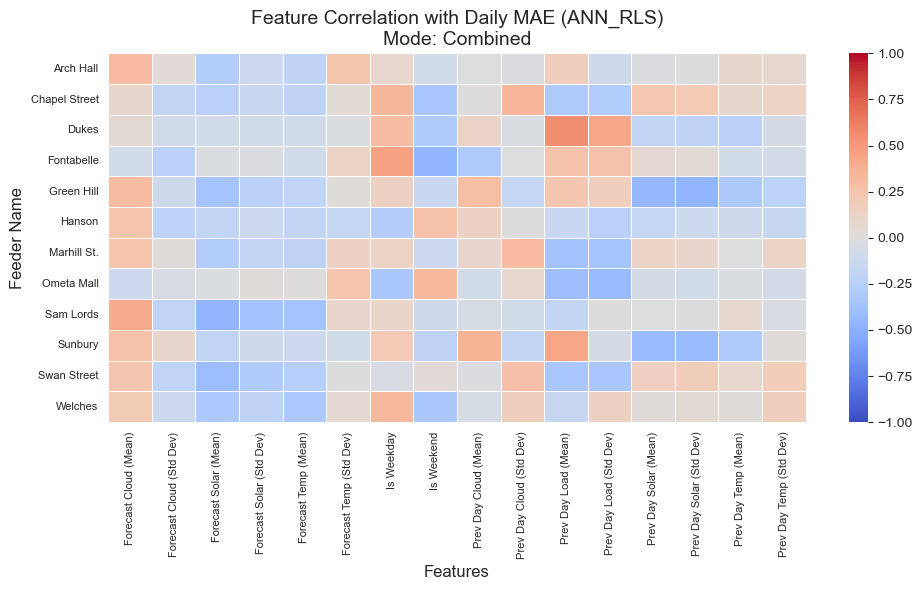

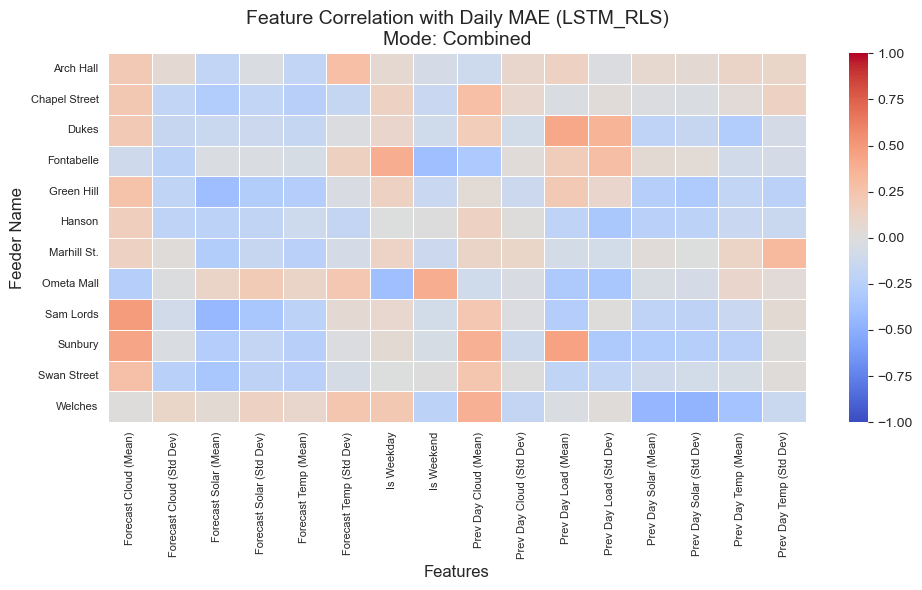

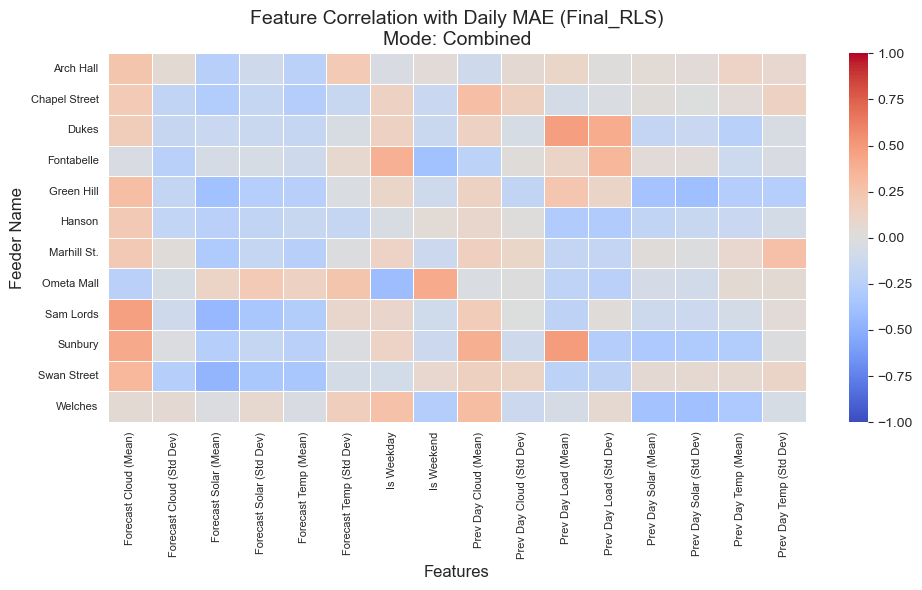

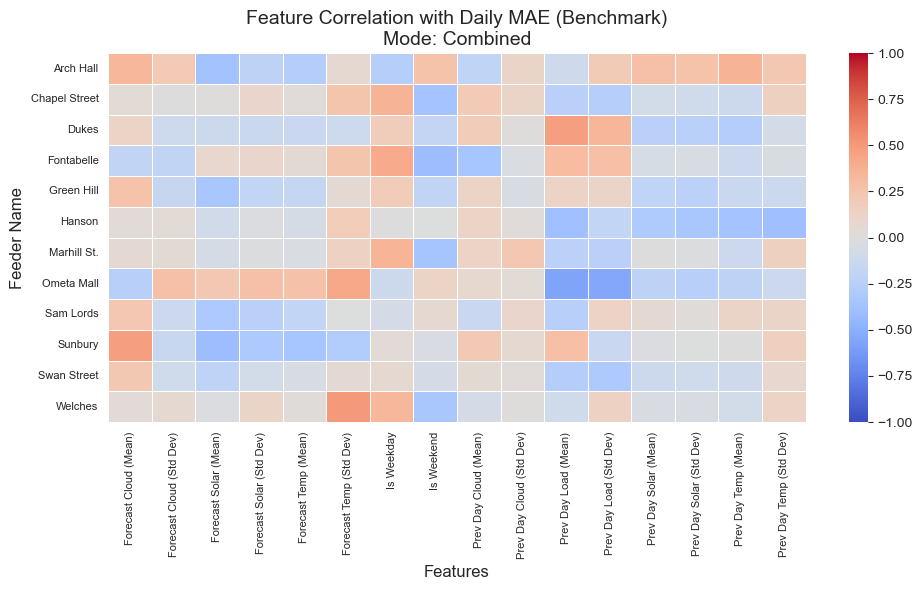


--- Analysis Function Complete ---


--- Top 3 Positively Correlated Features for Model: ANN_RLS (Mode: Combined) ---

High Capacity Feeders:
Feeder Name            Feature #1              Feature #2               Feature #3
  Arch Hall Forecast Cloud (Mean) Forecast Temp (Std Dev)     Prev Day Load (Mean)
      Dukes  Prev Day Load (Mean) Prev Day Load (Std Dev)               Is Weekday
 Fontabelle            Is Weekday Prev Day Load (Std Dev)     Prev Day Load (Mean)
 Green Hill Forecast Cloud (Mean)   Prev Day Cloud (Mean)     Prev Day Load (Mean)
  Sam Lords Forecast Cloud (Mean)              Is Weekday  Forecast Temp (Std Dev)
    Sunbury  Prev Day Load (Mean)   Prev Day Cloud (Mean)    Forecast Cloud (Mean)
    Welches            Is Weekday   Forecast Cloud (Mean) Prev Day Cloud (Std Dev)

Low Capacity Feeders:
  Feeder Name               Feature #1              Feature #2               Feature #3
Chapel Street Prev Day Cloud (Std Dev)              Is Weekday    Prev Day Solar (

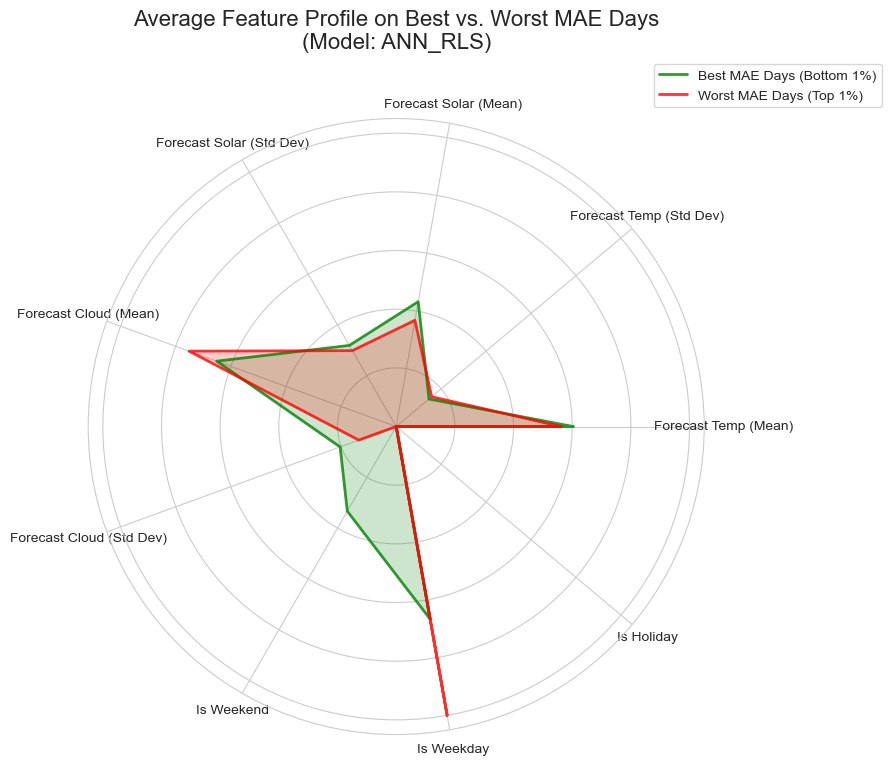

  (ANN_RLS) Generating Boxplots...


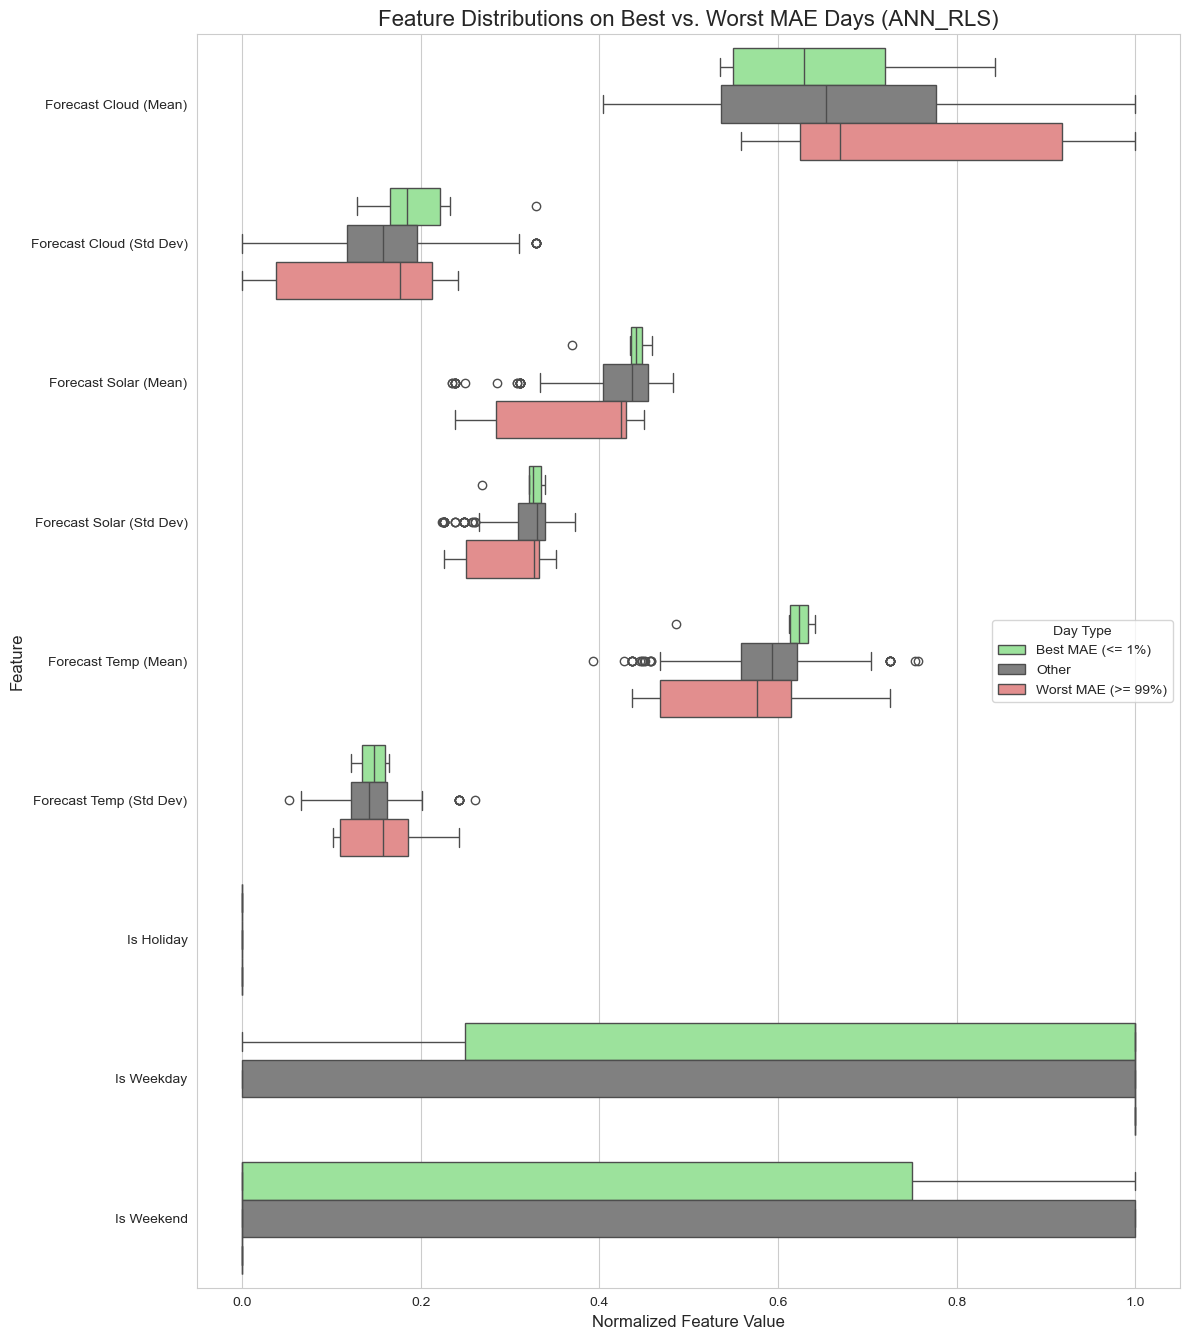


--- Analyzing Scenarios for Best/Worst MAE Days (LSTM_RLS) ---
  (LSTM_RLS) Identified: 6 Best MAE Days, 6 Worst MAE Days, 497 Other Days
+++++++++++++++++++++++++++++++++++++++++++++++ cur_forecasted_temperature_mean         0.588889
cur_forecasted_temperature_std          0.139909
cur_forecasted_solar_irradiance_mean    0.424823
cur_forecasted_solar_irradiance_std     0.315438
cur_forecasted_cloud_cover_mean         0.707333
cur_forecasted_cloud_cover_std          0.202741
Is_Weekend                              0.333333
Is_Weekday                              0.666667
Is_Holiday                              0.000000
dtype: float64
+++++++++++++++++++++++++++++++++++++++++++++++ cur_forecasted_temperature_mean         0.566378
cur_forecasted_temperature_std          0.152496
cur_forecasted_solar_irradiance_mean    0.397272
cur_forecasted_solar_irradiance_std     0.316677
cur_forecasted_cloud_cover_mean         0.728333
cur_forecasted_cloud_cover_std          0.172459
Is_Weekend     

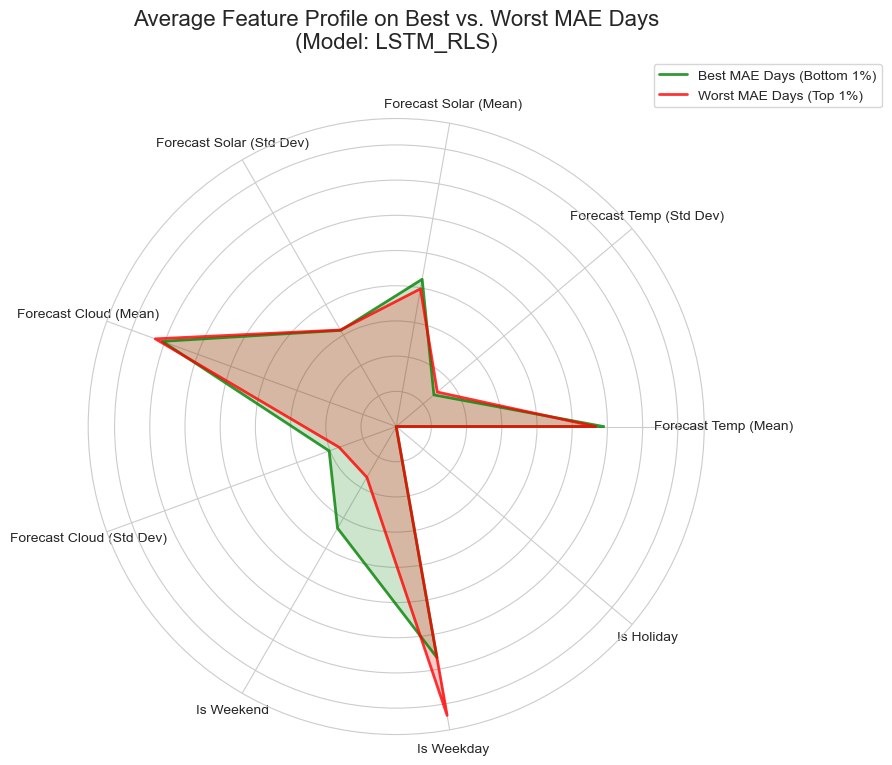

  (LSTM_RLS) Generating Boxplots...


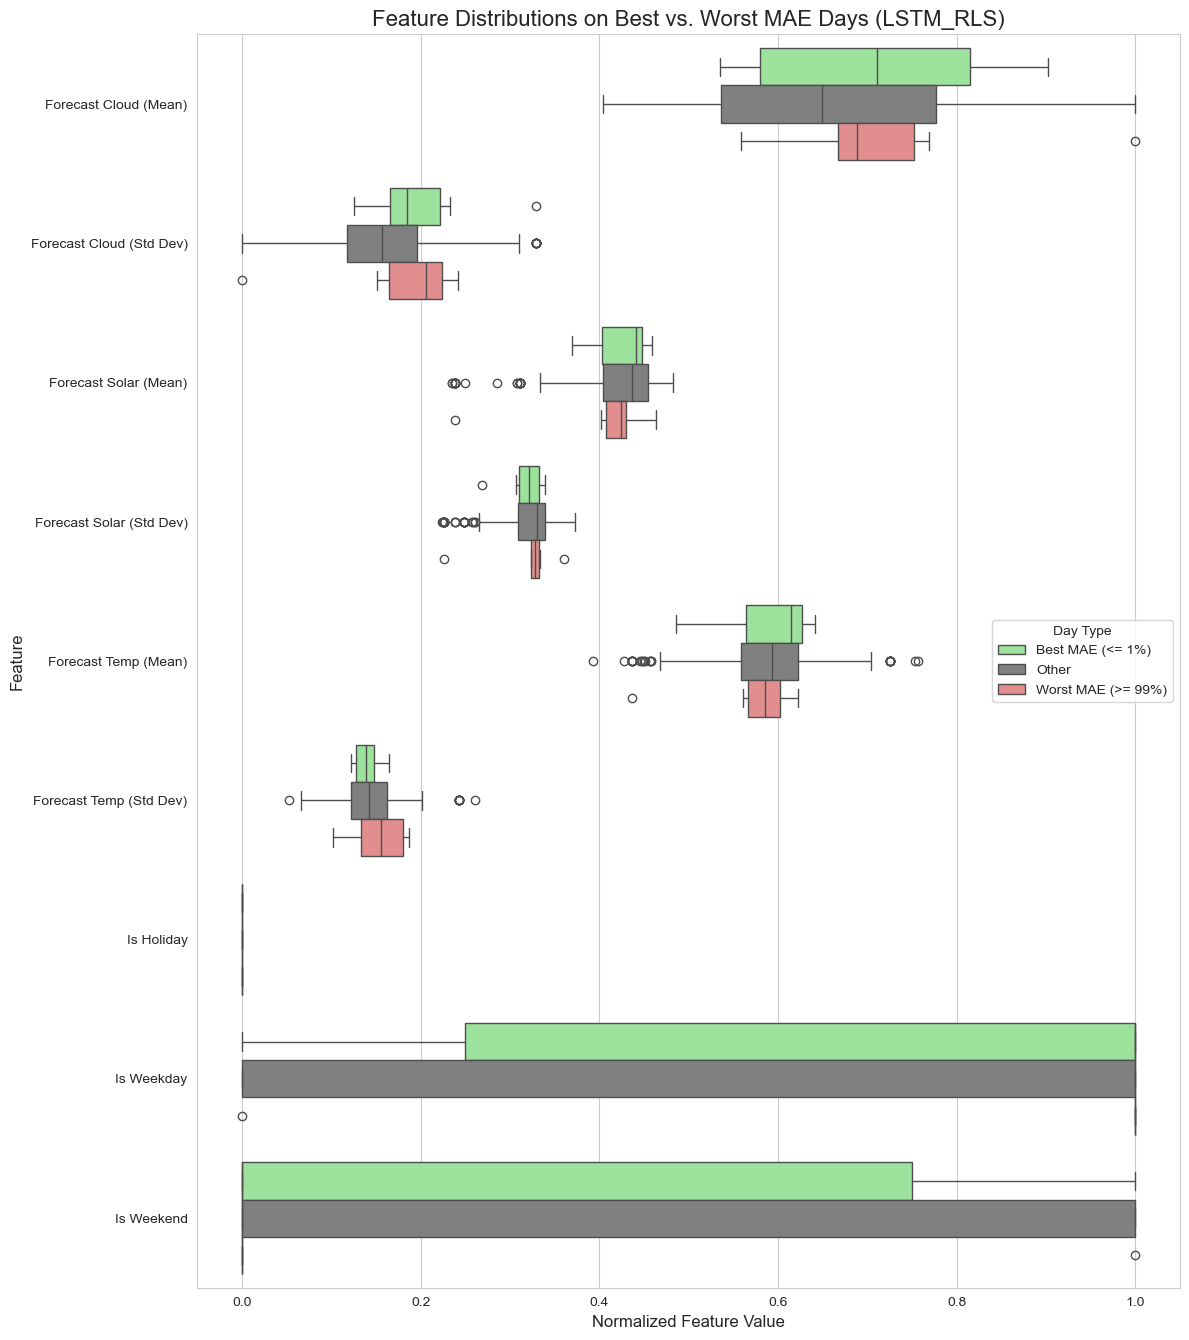


--- Analyzing Scenarios for Best/Worst MAE Days (Final_RLS) ---
  (Final_RLS) Identified: 6 Best MAE Days, 6 Worst MAE Days, 497 Other Days
+++++++++++++++++++++++++++++++++++++++++++++++ cur_forecasted_temperature_mean         0.595498
cur_forecasted_temperature_std          0.135994
cur_forecasted_solar_irradiance_mean    0.429256
cur_forecasted_solar_irradiance_std     0.314677
cur_forecasted_cloud_cover_mean         0.655111
cur_forecasted_cloud_cover_std          0.212044
Is_Weekend                              0.166667
Is_Weekday                              0.833333
Is_Holiday                              0.000000
dtype: float64
+++++++++++++++++++++++++++++++++++++++++++++++ cur_forecasted_temperature_mean         0.538132
cur_forecasted_temperature_std          0.140346
cur_forecasted_solar_irradiance_mean    0.359763
cur_forecasted_solar_irradiance_std     0.294324
cur_forecasted_cloud_cover_mean         0.777556
cur_forecasted_cloud_cover_std          0.134168
Is_Weekend   

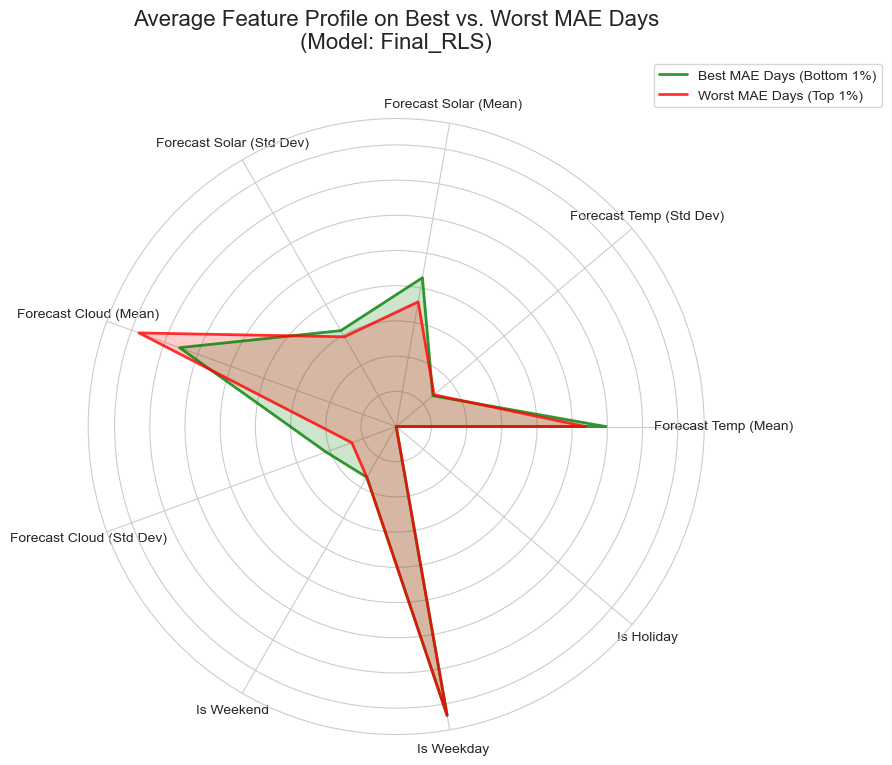

  (Final_RLS) Generating Boxplots...


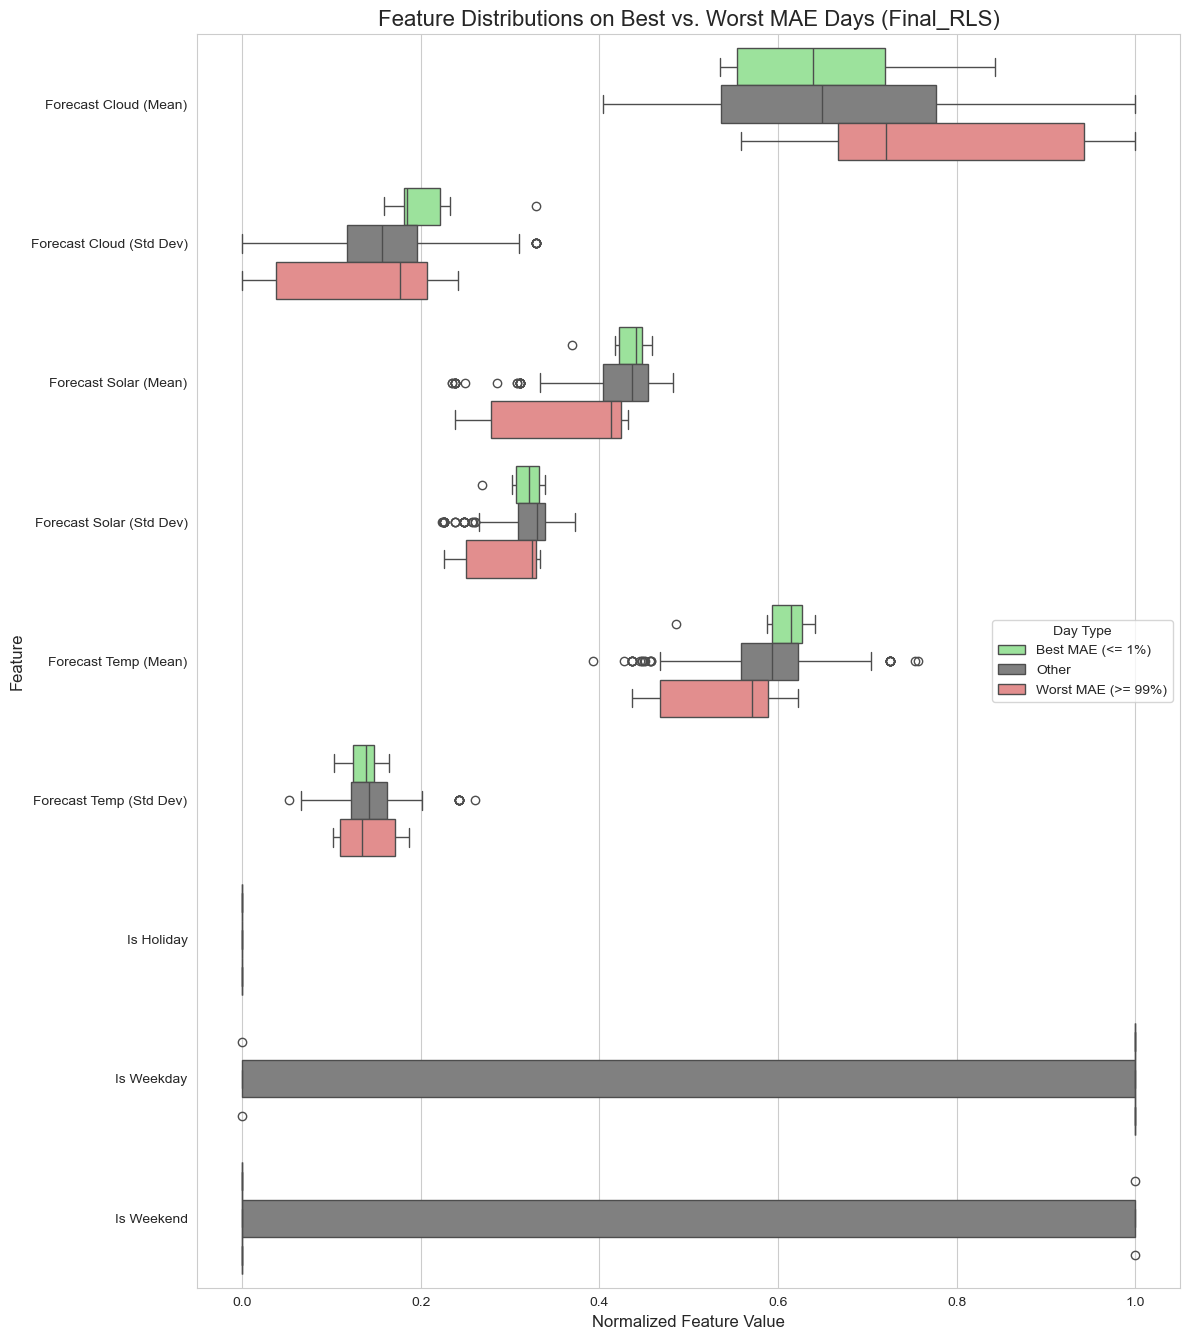


--- Analyzing Scenarios for Best/Worst MAE Days (Benchmark) ---
  (Benchmark) Identified: 6 Best MAE Days, 6 Worst MAE Days, 497 Other Days
+++++++++++++++++++++++++++++++++++++++++++++++ cur_forecasted_temperature_mean         0.598256
cur_forecasted_temperature_std          0.141453
cur_forecasted_solar_irradiance_mean    0.436136
cur_forecasted_solar_irradiance_std     0.320454
cur_forecasted_cloud_cover_mean         0.632000
cur_forecasted_cloud_cover_std          0.214700
Is_Weekend                              0.333333
Is_Weekday                              0.666667
Is_Holiday                              0.000000
dtype: float64
+++++++++++++++++++++++++++++++++++++++++++++++ cur_forecasted_temperature_mean         0.562678
cur_forecasted_temperature_std          0.156477
cur_forecasted_solar_irradiance_mean    0.369233
cur_forecasted_solar_irradiance_std     0.304062
cur_forecasted_cloud_cover_mean         0.773889
cur_forecasted_cloud_cover_std          0.149482
Is_Weekend   

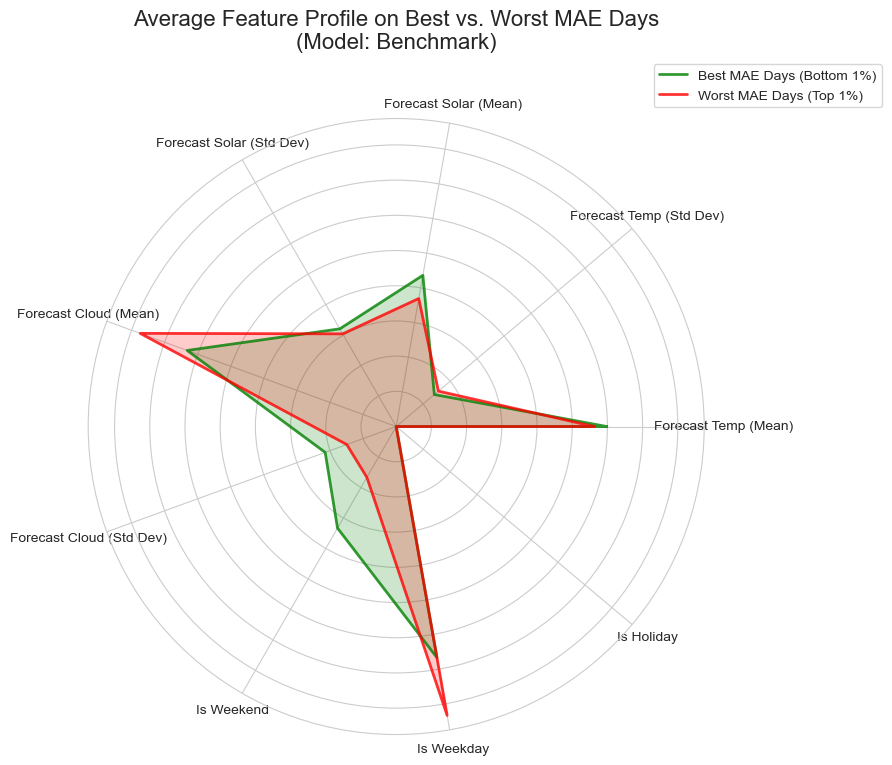

  (Benchmark) Generating Boxplots...


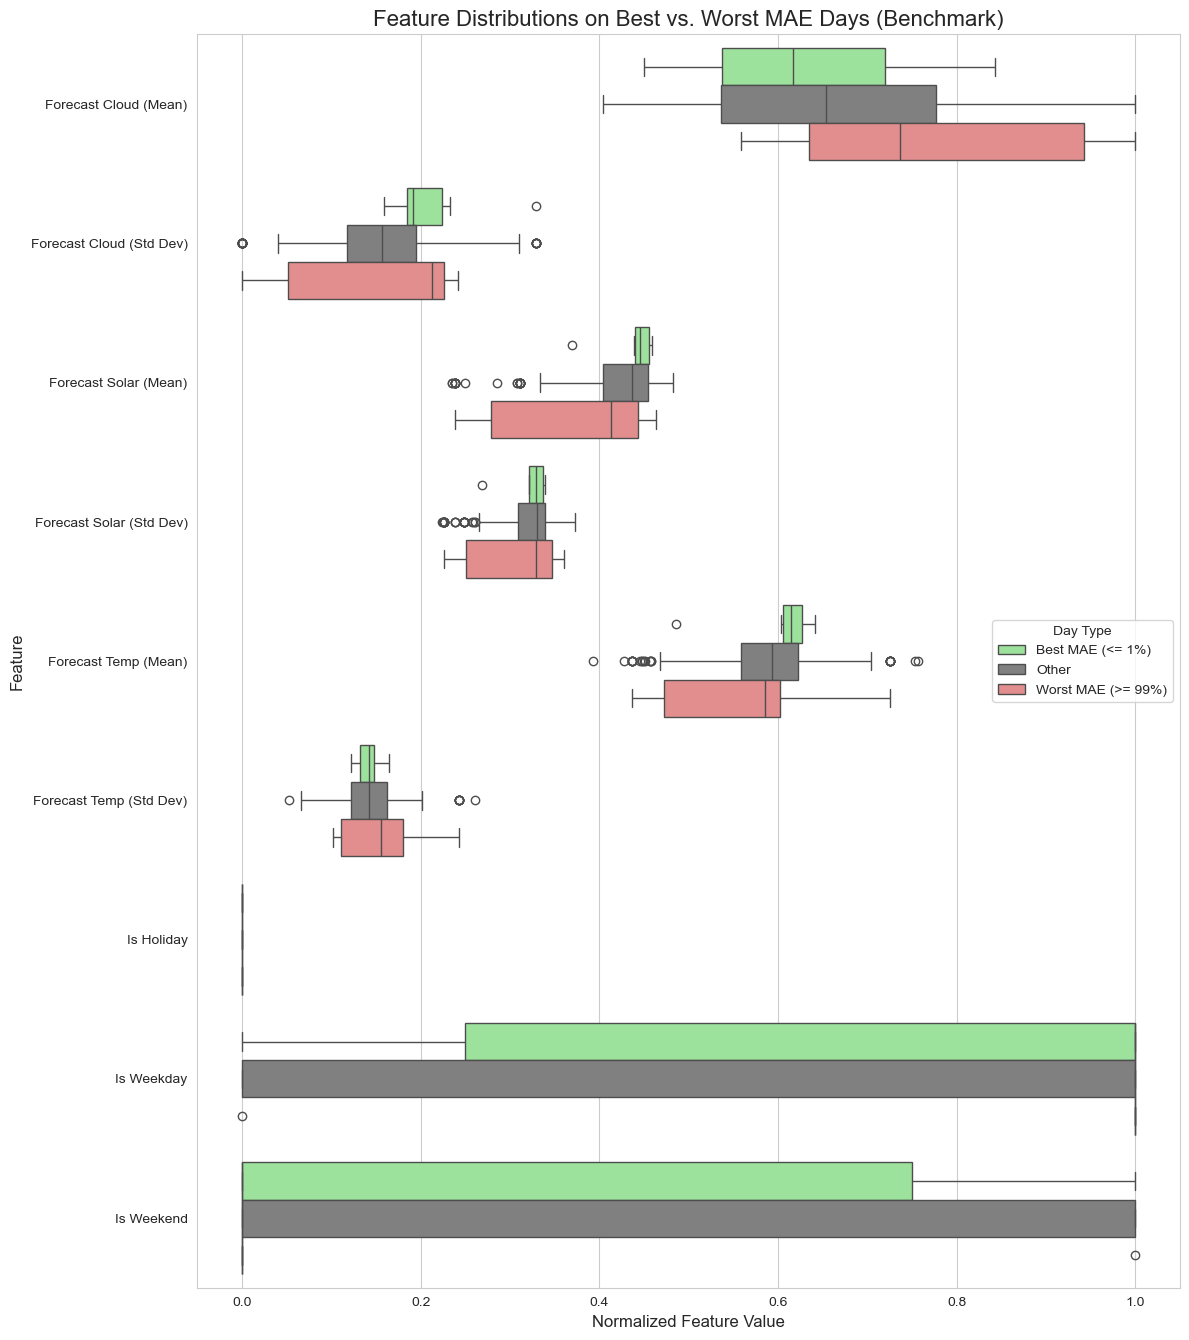


--- Calculating and Plotting Top 10 Most Frequent POSITIVE Features ---


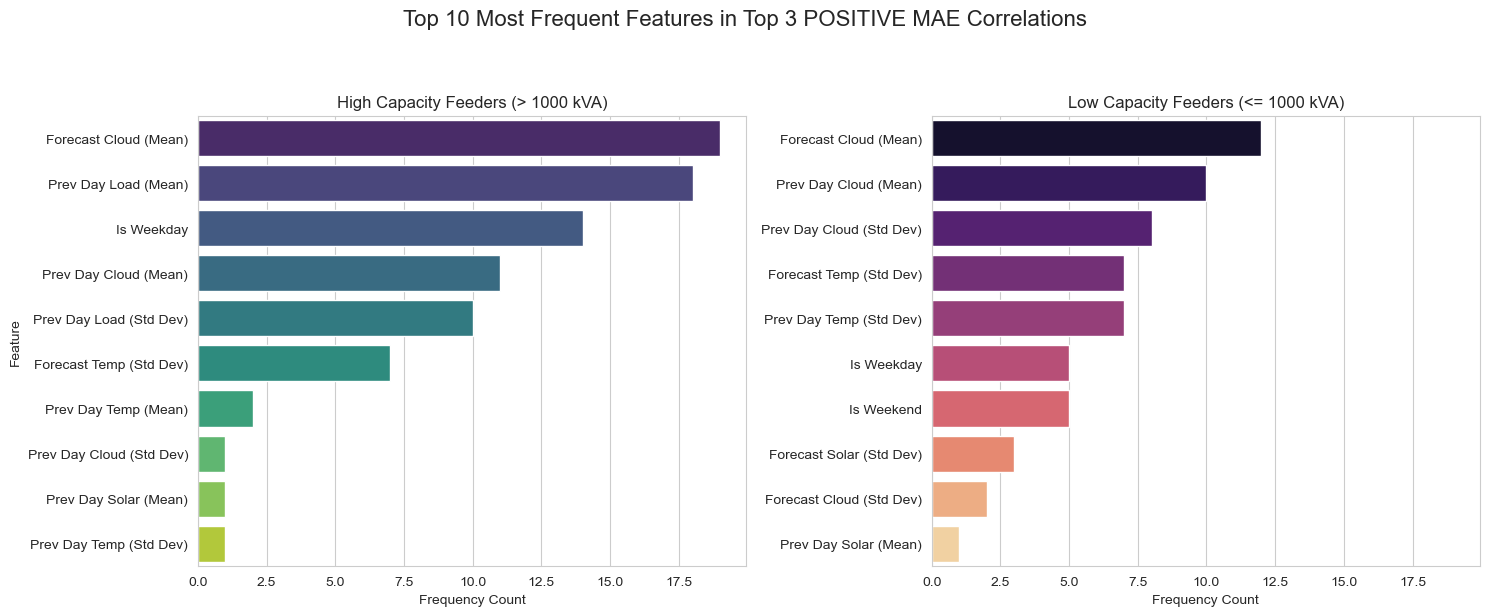


--- Calculating and Plotting Top 10 Most Frequent NEGATIVE Features ---


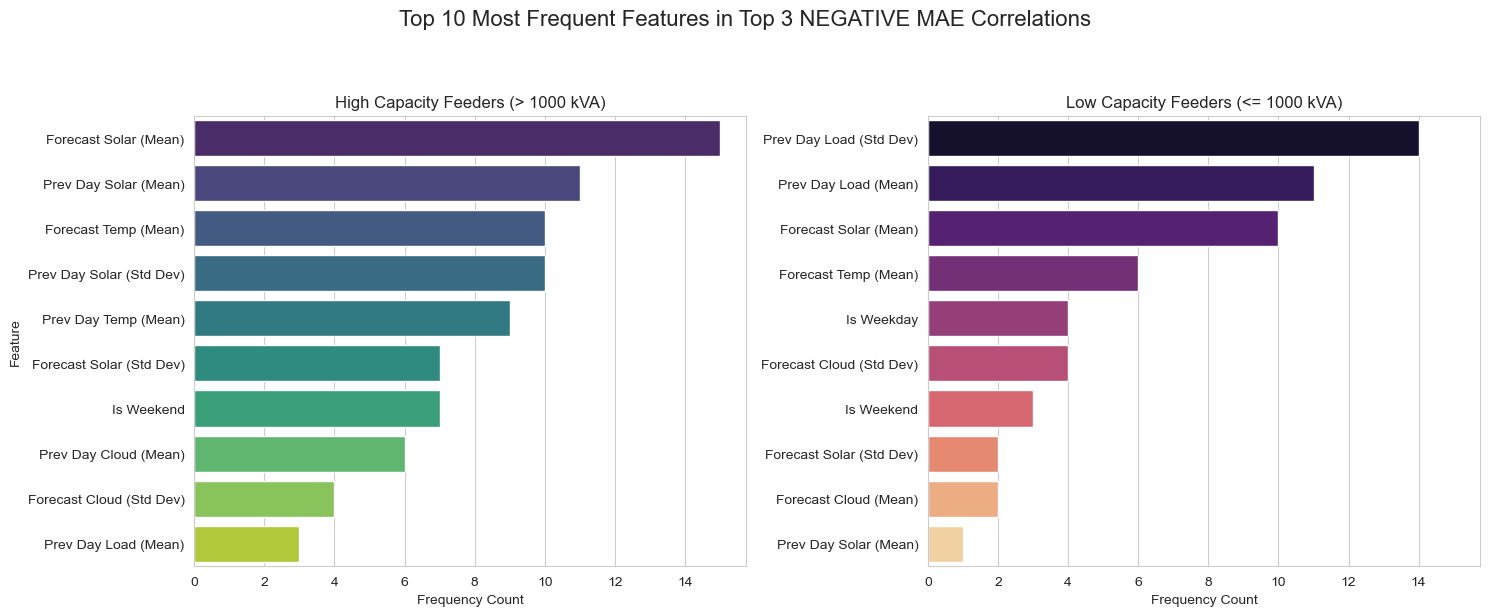

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math # Needed for radar chart

# Ignore simple warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

# --- Define Base Paths (Adjust if your script is located elsewhere) ---
BASE_PROJECT_PATH = Path("./../") # Path relative to the script location
DATA_PATH = BASE_PROJECT_PATH / "Data" / "Clustering_Data" / "Daytime"
RESULTS_PATH = DATA_PATH # Results are also under Data/Clustering_Data/Daytime/ according to user

# --- Feeder Capacities ---
FEEDER_CAPACITIES = {
    "Arch_Hall_ST2B13": 5594, "Chapel_Street_TY2B4": 100, "Dukes_ST2B15": 2409,
    "Fontabelle_1_TY2B7": 3099, "Green_Hill_WA2B6": 7816, "Hanson_(Belmont)_BE2B1": 546,
    "Marhill_St._TY2B8": 208, "Ometa_Mall_MA2B4": 455, "Sam_Lords_HA2B5": 4179,
    "Sunbury_HA2B2": 4648, "Swan_Street_TY2B6": 14, "Welches_WA2B2": 1211
}
# --- Feeder Name Mapping for Presentation ---
FEEDER_NAME_MAPPING = {
    "Arch_Hall_ST2B13": "Arch Hall", "Chapel_Street_TY2B4": "Chapel Street", "Dukes_ST2B15": "Dukes",
    "Fontabelle_1_TY2B7": "Fontabelle", "Green_Hill_WA2B6": "Green Hill", "Hanson_(Belmont)_BE2B1": "Hanson",
    "Marhill_St._TY2B8": "Marhill St.", "Ometa_Mall_MA2B4": "Ometa Mall", "Sam_Lords_HA2B5": "Sam Lords",
    "Sunbury_HA2B2": "Sunbury", "Swan_Street_TY2B6": "Swan Street", "Welches_WA2B2": "Welches"
}
# --- Feature Name Mapping for Presentation ---
FEATURE_NAME_MAPPING = {
    "prev_historic_temperature_mean": "Prev Day Temp (Mean)", "cur_forecasted_temperature_mean": "Forecast Temp (Mean)",
    "prev_historic_solar_irradiance_mean": "Prev Day Solar (Mean)", "cur_forecasted_solar_irradiance_mean": "Forecast Solar (Mean)",
    "prev_historic_cloud_cover_mean": "Prev Day Cloud (Mean)", "cur_forecasted_cloud_cover_mean": "Forecast Cloud (Mean)",
    "prev_historic_net_load_demand_mean": "Prev Day Load (Mean)",
    "prev_historic_temperature_std": "Prev Day Temp (Std Dev)", "cur_forecasted_temperature_std": "Forecast Temp (Std Dev)",
    "prev_historic_solar_irradiance_std": "Prev Day Solar (Std Dev)", "cur_forecasted_solar_irradiance_std": "Forecast Solar (Std Dev)",
    "prev_historic_cloud_cover_std": "Prev Day Cloud (Std Dev)", "cur_forecasted_cloud_cover_std": "Forecast Cloud (Std Dev)",
    "prev_historic_net_load_demand_std": "Prev Day Load (Std Dev)",
    "Is_Weekday": "Is Weekday", "Is_Weekend": "Is Weekend", "Is_Holiday": "Is Holiday"
}
# --- Capacity Threshold ---
HIGH_CAPACITY_THRESHOLD = 1000

# --- Helper Function load_preprocess_feeder_data (Unchanged) ---
def load_preprocess_feeder_data(feeder_name, dataset_type, models_to_analyze, actual_col_name="Actual"):
    """Loads features and results, calculates daily MAE for one feeder."""
    print(f"  Processing Feeder: {feeder_name}, Type: {dataset_type}...")
    results_folder = RESULTS_PATH / f"{dataset_type}_Results"
    features_folder = DATA_PATH / f"{dataset_type}_Features"
    results_path = results_folder / f"{feeder_name}_{dataset_type}_Results.csv"
    inputs_path = features_folder / f"{feeder_name}_X_{dataset_type}_Normalized.csv"
    if not results_path.is_file(): print(f"    Warning: Results file not found: {results_path}"); return None
    if not inputs_path.is_file(): print(f"    Warning: Input features file not found: {inputs_path}"); return None
    try:
        df_results = pd.read_csv(results_path, index_col=0, parse_dates=True)
        df_inputs = pd.read_csv(inputs_path, index_col=0, parse_dates=True)
        if df_results.index.name is None: df_results.index.name = "timestamp"
        if df_inputs.index.name is None: df_inputs.index.name = "timestamp"
        required_cols = models_to_analyze + [actual_col_name]
        missing_cols = [col for col in required_cols if col not in df_results.columns]
        if missing_cols: print(f"    Warning: Missing required columns in results file {results_path}: {missing_cols}"); return None
        df_results["date_only"] = df_results.index.date
        daily_mae_list = []
        for model_name in models_to_analyze:
            abs_error_col = f"AbsError_{model_name}"; daily_mae_col = f"Daily_MAE_{model_name}"
            df_results[abs_error_col] = (df_results[actual_col_name] - df_results[model_name]).abs()
            numeric_cols = df_results.select_dtypes(include=np.number).columns
            if abs_error_col in numeric_cols:
                daily_mae = df_results.groupby("date_only")[abs_error_col].mean().reset_index()
                daily_mae.rename(columns={abs_error_col: daily_mae_col, "date_only": "date"}, inplace=True)
                daily_mae["date"] = pd.to_datetime(daily_mae["date"]); daily_mae_list.append(daily_mae.set_index("date"))
            else: print(f"    Warning: AbsError column {abs_error_col} not numeric for {model_name}.")
        if not daily_mae_list: print("    Warning: No Daily MAE could be calculated."); return None
        merged_mae_df = pd.concat(daily_mae_list, axis=1)
        df_analysis = df_inputs.copy(); df_analysis.index = df_analysis.index.normalize()
        df_analysis = df_analysis.join(merged_mae_df, how="inner")
        mae_cols_to_check = [f"Daily_MAE_{m}" for m in models_to_analyze if f"Daily_MAE_{m}" in df_analysis.columns]
        df_analysis.dropna(subset=mae_cols_to_check, inplace=True)
        if df_analysis.empty: print("    Warning: Analysis DataFrame empty after merging features and MAE."); return None
        df_analysis['FeederName_Internal'] = feeder_name
        return df_analysis
    except Exception as e: print(f"    Error processing {feeder_name} ({dataset_type}): {e}"); return None

# --- Main Analysis Function ---
def generate_analysis_results(
    feeder_list: list,
    feeder_capacities: dict,
    feeder_name_mapping: dict,
    feature_name_mapping: dict,
    mode: str,
    models_to_analyze: list = ["Final_RLS", "LSTM_RLS", "ANN_RLS", "Benchmark"],
    actual_col_name: str = "Actual",
    capacity_threshold: int = HIGH_CAPACITY_THRESHOLD
):
    """
    Performs analysis: generates top feature tables, collects correlation data,
    and returns a combined dataframe for scenario analysis.
    """
    print(f"--- Generating Analysis Results --- Mode: {mode} ---")
    all_feeder_top_positive_features = {model: {} for model in models_to_analyze}
    all_feeder_top_negative_features = {model: {} for model in models_to_analyze}
    per_feeder_correlations = {model: {} for model in models_to_analyze}
    all_feeder_data_list = []

    for feeder_name in feeder_list:
        if feeder_name not in feeder_capacities: print(f"Warning: Capacity not defined for feeder '{feeder_name}'. Skipping."); continue
        df_feeder_combined = pd.DataFrame()
        if mode == "Validation" or mode == "Combined":
            df_val = load_preprocess_feeder_data(feeder_name, "Validation", models_to_analyze, actual_col_name)
            if df_val is not None: df_feeder_combined = pd.concat([df_feeder_combined, df_val], axis=0)
        if mode == "Test" or mode == "Combined":
            df_test = load_preprocess_feeder_data(feeder_name, "Test", models_to_analyze, actual_col_name)
            if df_test is not None: df_feeder_combined = pd.concat([df_feeder_combined, df_test], axis=0)
        if df_feeder_combined.empty: print(f"  Skipping {feeder_name} due to data loading/processing issues."); continue
        df_feeder_combined = df_feeder_combined[~df_feeder_combined.index.duplicated(keep='first')]
        df_analysis = df_feeder_combined.copy()

        # --- Feature Engineering ---
        # print(f"  Feature Engineering for {feeder_name}...") # Less verbose
        feature_prefixes_multi_step = [
            "prev_historic_temperature", "cur_forecasted_temperature",
            "prev_historic_solar_irradiance", "cur_forecasted_solar_irradiance",
            "prev_historic_cloud_cover", "cur_forecasted_cloud_cover",
            "prev_historic_net_load_demand"
        ]
        weather_feature_means = []; weather_feature_stds = []
        for prefix in feature_prefixes_multi_step:
             cols = [col for col in df_analysis.columns if col.startswith(prefix) and not (col.endswith("_mean") or col.endswith("_std"))]
             if cols:
                 mean_col_name = f"{prefix}_mean"; std_col_name = f"{prefix}_std"
                 if mean_col_name not in df_analysis.columns: df_analysis[mean_col_name] = df_analysis[cols].mean(axis=1)
                 if std_col_name not in df_analysis.columns: df_analysis[std_col_name] = df_analysis[cols].std(axis=1)
                 weather_feature_means.append(mean_col_name); weather_feature_stds.append(std_col_name)
        time_features = []
        dow_5_exists = "cur_day_of_week_5" in df_analysis.columns; dow_6_exists = "cur_day_of_week_6" in df_analysis.columns
        if dow_5_exists and dow_6_exists:
             df_analysis["Is_Weekend"] = ((df_analysis["cur_day_of_week_5"] == 1) | (df_analysis["cur_day_of_week_6"] == 1)).astype(int)
             df_analysis["Is_Weekday"] = 1 - df_analysis["Is_Weekend"]; time_features.extend(["Is_Weekday", "Is_Weekend"])
        else:
             if "Is_Weekend" not in df_analysis.columns: df_analysis["Is_Weekend"] = 0
             if "Is_Weekday" not in df_analysis.columns: df_analysis["Is_Weekday"] = 0
        holiday_col_orig = "cur_is_holiday_0"
        if holiday_col_orig in df_analysis.columns:
             df_analysis["Is_Holiday"] = df_analysis[holiday_col_orig].astype(int); time_features.append("Is_Holiday")
        else:
             if "Is_Holiday" not in df_analysis.columns: df_analysis["Is_Holiday"] = 0
        features_for_corr_internal = [tf for tf in time_features if df_analysis[tf].nunique() > 1] + \
                                     [wf for wf in weather_feature_means if wf in df_analysis.columns and df_analysis[wf].nunique() > 1] + \
                                     [ws for ws in weather_feature_stds if ws in df_analysis.columns and df_analysis[ws].nunique() > 1]
        if not features_for_corr_internal: continue

        all_feeder_data_list.append(df_analysis) # Add processed data

        # --- Per-Feeder Correlations & Top Features ---
        # print(f"  Calculating correlations for {feeder_name}...") # Less verbose
        for model_name in models_to_analyze:
            mae_col = f"Daily_MAE_{model_name}"
            if mae_col not in df_analysis.columns: continue
            corr_cols = [mae_col] + features_for_corr_internal
            try:
                df_corr_subset = df_analysis[corr_cols].fillna(0)
                correlation_matrix = df_corr_subset.corr()
                mae_correlations = correlation_matrix[mae_col].drop(mae_col, axis=0).dropna()
                per_feeder_correlations[model_name][feeder_name] = mae_correlations
                top_3_positive = mae_correlations[mae_correlations > 0].nlargest(3)
                top_pos_list = [feature_name_mapping.get(f, f) for f in top_3_positive.index]
                while len(top_pos_list) < 3: top_pos_list.append("N/A")
                all_feeder_top_positive_features[model_name][feeder_name] = top_pos_list
                neg_corrs = mae_correlations[mae_correlations < 0].sort_values()
                top_5_negative = neg_corrs.head(5) # Keep for potential future use or detailed logs
                top_3_neg_list = [feature_name_mapping.get(f, f) for f in neg_corrs.head(3).index]
                while len(top_3_neg_list) < 3: top_3_neg_list.append("N/A")
                all_feeder_top_negative_features[model_name][feeder_name] = top_3_neg_list
                # Optional: Print top 5 negative here if needed during run
            except Exception as e: print(f"    Error calculating correlation for {feeder_name}, {model_name}: {e}")

    if not all_feeder_data_list: print("Error: No feeder data processed."); return None, None, None
    df_all_analysis = pd.concat(all_feeder_data_list, axis=0)
    print(f"\nCombined DataFrame shape for scenario analysis: {df_all_analysis.shape}")

    # --- Organize Top Positive Feature Tables ---
    output_tables_pos = {model: {"High Capacity": [], "Low Capacity": []} for model in models_to_analyze}
    for model_name in models_to_analyze:
        for feeder_name_internal, top_features_renamed in all_feeder_top_positive_features[model_name].items():
            capacity = feeder_capacities.get(feeder_name_internal, -1)
            feeder_name_display = feeder_name_mapping.get(feeder_name_internal, feeder_name_internal)
            row_data = {"Feeder Name": feeder_name_display, "Feature #1": top_features_renamed[0], "Feature #2": top_features_renamed[1], "Feature #3": top_features_renamed[2]}
            if capacity > capacity_threshold: output_tables_pos[model_name]["High Capacity"].append(row_data)
            elif capacity >= 0: output_tables_pos[model_name]["Low Capacity"].append(row_data)
        output_tables_pos[model_name]["High Capacity"] = pd.DataFrame(output_tables_pos[model_name]["High Capacity"])
        output_tables_pos[model_name]["Low Capacity"] = pd.DataFrame(output_tables_pos[model_name]["Low Capacity"])

    # --- Generate Correlation Heatmaps ---
    print("\n--- Generating Correlation Heatmaps per Model ---")
    sns.set_style("whitegrid")
    for model_name in models_to_analyze:
        if not per_feeder_correlations[model_name]: continue
        heatmap_df = pd.DataFrame(per_feeder_correlations[model_name]).T
        heatmap_df = heatmap_df.dropna(axis=1, how='all')
        if heatmap_df.empty: continue
        heatmap_df.rename(columns=feature_name_mapping, inplace=True); heatmap_df.rename(index=feeder_name_mapping, inplace=True)
        heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1); heatmap_df = heatmap_df.sort_index()
        n_feeders = len(heatmap_df); n_features = len(heatmap_df.columns)
        fig_width = max(10, n_features * 0.5); fig_height = max(6, n_feeders * 0.4)
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(heatmap_df, cmap="coolwarm", annot=False, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, cbar=True)
        plt.title(f"Feature Correlation with Daily MAE ({model_name})\nMode: {mode}", fontsize=14)
        plt.xlabel("Features", fontsize=12); plt.ylabel("Feeder Name", fontsize=12)
        plt.xticks(rotation=90, fontsize=8); plt.yticks(rotation=0, fontsize=8)
        plt.tight_layout(); plt.show()

    print("\n--- Analysis Function Complete ---")
    return output_tables_pos, all_feeder_top_negative_features, df_all_analysis


# --- Function for Scenario Analysis and Plotting ---
def analyze_and_plot_mae_scenarios(
    df_all_analysis: pd.DataFrame,
    model_name: str, # Takes model name now
    feature_name_mapping: dict,
    worst_mae_quantile: float = 0.97, # Top 5% highest MAE (Updated)
    best_mae_quantile: float = 0.03,  # Bottom 5% lowest MAE (Updated)
    features_for_scenario: list = None
):
    """Analyzes and plots feature profiles for best/worst MAE days for a specific model."""
    target_mae_col = f"Daily_MAE_{model_name}" # Construct target MAE column name

    print(f"\n--- Analyzing Scenarios for Best/Worst MAE Days ({model_name}) ---")
    sns.set_style("whitegrid")

    if target_mae_col not in df_all_analysis.columns:
        print(f"Error: Target MAE column '{target_mae_col}' not found in combined data.")
        return

    # --- Define Best/Worst Days ---
    mae_threshold_worst = df_all_analysis[target_mae_col].quantile(worst_mae_quantile)
    mae_threshold_best = df_all_analysis[target_mae_col].quantile(best_mae_quantile)
    worst_days_mask = df_all_analysis[target_mae_col] >= mae_threshold_worst
    best_days_mask = df_all_analysis[target_mae_col] <= mae_threshold_best
    other_days_mask = ~worst_days_mask & ~best_days_mask
    n_worst = worst_days_mask.sum(); n_best = best_days_mask.sum(); n_other = other_days_mask.sum()

    if n_worst == 0 or n_best == 0:
        print(f"Warning: Not enough data points for {model_name} to define distinct best/worst days. Skipping scenario analysis."); return
    print(f"  ({model_name}) Identified: {n_best} Best MAE Days, {n_worst} Worst MAE Days, {n_other} Other Days")

    # --- Select Features ---
    if features_for_scenario is None:
        features_for_scenario = [ # Default selection
            'prev_historic_net_load_demand', "cur_forecasted_temperature_mean", "cur_forecasted_temperature_std",
            "cur_forecasted_solar_irradiance_mean", "cur_forecasted_solar_irradiance_std",
            "cur_forecasted_cloud_cover_mean", "cur_forecasted_cloud_cover_std",
            "Is_Weekend", "Is_Weekday", "Is_Holiday",  ]
        features_for_scenario = [f for f in features_for_scenario if f in df_all_analysis.columns]
    if not features_for_scenario: print("Error: No valid features for scenario analysis."); return
    # print(f"  ({model_name}) Analyzing scenarios using features: {features_for_scenario}") # Less verbose

    # --- Calculate Average Profiles ---
    profile_best = df_all_analysis.loc[best_days_mask, features_for_scenario].mean()
    profile_worst = df_all_analysis.loc[worst_days_mask, features_for_scenario].mean()
    
    print("+++++++++++++++++++++++++++++++++++++++++++++++", profile_best, end="\n")
    print("+++++++++++++++++++++++++++++++++++++++++++++++", profile_worst, end="\n")
    print(mae_threshold_worst, mae_threshold_best, end="\n")
    profile_best.rename(index=feature_name_mapping, inplace=True)
    profile_worst.rename(index=feature_name_mapping, inplace=True)
    features_renamed = list(profile_best.index)

    # --- Plot 1: Radar Chart ---
    print(f"  ({model_name}) Generating Radar Chart...")
    labels = np.array(features_renamed); stats_best = profile_best.values; stats_worst = profile_worst.values
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    stats_best = np.concatenate((stats_best,[stats_best[0]])); stats_worst = np.concatenate((stats_worst,[stats_worst[0]]))
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.plot(angles, stats_best, linewidth=2, linestyle='solid', label=f'Best MAE Days (Bottom {best_mae_quantile*100:.0f}%)', color='green', alpha=0.8)
    ax.fill(angles, stats_best, 'green', alpha=0.2)
    ax.plot(angles, stats_worst, linewidth=2, linestyle='solid', label=f'Worst MAE Days (Top {(1-worst_mae_quantile)*100:.0f}%)', color='red', alpha=0.8)
    ax.fill(angles, stats_worst, 'red', alpha=0.2)
    ax.set_yticklabels([]); ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title(f'Average Feature Profile on Best vs. Worst MAE Days\n(Model: {model_name})', size=16, y=1.1)
    plt.show()

    # --- Plot 2: Boxplots ---
    print(f"  ({model_name}) Generating Boxplots...")
    df_plot = df_all_analysis[features_for_scenario + [target_mae_col]].copy()
    df_plot['Day Type'] = 'Other'
    df_plot.loc[best_days_mask, 'Day Type'] = f'Best MAE (<= {best_mae_quantile*100:.0f}%)'
    df_plot.loc[worst_days_mask, 'Day Type'] = f'Worst MAE (>= {worst_mae_quantile*100:.0f}%)'
    df_melted = pd.melt(df_plot, id_vars=['Day Type'], value_vars=features_for_scenario, var_name='Feature_Internal', value_name='Normalized Value')
    df_melted['Feature'] = df_melted['Feature_Internal'].map(feature_name_mapping)
    n_features_plot = len(features_for_scenario)
    plt.figure(figsize=(12, n_features_plot * 1.5))
    sns.boxplot(y='Feature', x='Normalized Value', hue='Day Type', data=df_melted,
                order=sorted(df_melted['Feature'].unique()),
                hue_order=[f'Best MAE (<= {best_mae_quantile*100:.0f}%)', 'Other', f'Worst MAE (>= {worst_mae_quantile*100:.0f}%)'],
                palette={'Other': 'grey', f'Best MAE (<= {best_mae_quantile*100:.0f}%)': 'lightgreen', f'Worst MAE (>= {worst_mae_quantile*100:.0f}%)': 'lightcoral'})
    plt.title(f'Feature Distributions on Best vs. Worst MAE Days ({model_name})', fontsize=16)
    plt.xlabel("Normalized Feature Value", fontsize=12); plt.ylabel("Feature", fontsize=12)
    plt.legend(title='Day Type'); plt.tight_layout(); plt.show()


# --- Plotting Functions (Positive/Negative Frequency - Unchanged) ---
# ... (Keep plot_most_significant_features and plot_most_significant_negative_features) ...
def plot_most_significant_features(generated_tables: dict, capacity_threshold: int, top_n: int = 7):
    """ Plots frequency of top 3 positive features (using renamed features) """
    print(f"\n--- Calculating and Plotting Top {top_n} Most Frequent POSITIVE Features ---")
    sns.set_style("whitegrid")
    high_cap_all_features = []; low_cap_all_features = []
    for model in generated_tables:
        if not generated_tables[model]["High Capacity"].empty:
            for _, row in generated_tables[model]["High Capacity"].iterrows(): high_cap_all_features.extend([row["Feature #1"], row["Feature #2"], row["Feature #3"]])
        if not generated_tables[model]["Low Capacity"].empty:
            for _, row in generated_tables[model]["Low Capacity"].iterrows(): low_cap_all_features.extend([row["Feature #1"], row["Feature #2"], row["Feature #3"]])
    high_cap_counts = Counter(f for f in high_cap_all_features if f != "N/A"); low_cap_counts = Counter(f for f in low_cap_all_features if f != "N/A")
    df_high_freq = pd.DataFrame(high_cap_counts.most_common(top_n), columns=['Feature', 'Frequency']); df_low_freq = pd.DataFrame(low_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])
    fig, axes = plt.subplots(1, 2, figsize=(15, max(5, top_n * 0.6)), sharex=True)
    fig.suptitle(f'Top {top_n} Most Frequent Features in Top 3 POSITIVE MAE Correlations', fontsize=16, y=1.02)
    if not df_high_freq.empty:
        sns.barplot(ax=axes[0], x='Frequency', y='Feature', data=df_high_freq, palette='viridis'); axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)'); axes[0].set_xlabel("Frequency Count"); axes[0].set_ylabel("Feature")
    else: axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)\n(No features found)'); axes[0].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[0].transAxes)
    if not df_low_freq.empty:
        sns.barplot(ax=axes[1], x='Frequency', y='Feature', data=df_low_freq, palette='magma'); axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)'); axes[1].set_xlabel("Frequency Count"); axes[1].set_ylabel("")
    else: axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)\n(No features found)'); axes[1].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[1].transAxes)
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

def plot_most_significant_negative_features(all_negative_features: dict, feeder_capacities: dict, feeder_name_mapping: dict, capacity_threshold: int, top_n: int = 7):
    """ Plots frequency of top 3 negative features (using renamed features) """
    print(f"\n--- Calculating and Plotting Top {top_n} Most Frequent NEGATIVE Features ---")
    sns.set_style("whitegrid")
    high_cap_all_features = []; low_cap_all_features = []
    for model in all_negative_features:
        for feeder_name_internal, features_renamed in all_negative_features[model].items():
            capacity = feeder_capacities.get(feeder_name_internal, -1)
            if capacity > capacity_threshold: high_cap_all_features.extend(features_renamed)
            elif capacity >= 0: low_cap_all_features.extend(features_renamed)
    high_cap_counts = Counter(f for f in high_cap_all_features if f != "N/A"); low_cap_counts = Counter(f for f in low_cap_all_features if f != "N/A")
    df_high_freq = pd.DataFrame(high_cap_counts.most_common(top_n), columns=['Feature', 'Frequency']); df_low_freq = pd.DataFrame(low_cap_counts.most_common(top_n), columns=['Feature', 'Frequency'])
    fig, axes = plt.subplots(1, 2, figsize=(15, max(5, top_n * 0.6)), sharex=True)
    fig.suptitle(f'Top {top_n} Most Frequent Features in Top 3 NEGATIVE MAE Correlations', fontsize=16, y=1.02)
    if not df_high_freq.empty:
        sns.barplot(ax=axes[0], x='Frequency', y='Feature', data=df_high_freq, palette='viridis'); axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)'); axes[0].set_xlabel("Frequency Count"); axes[0].set_ylabel("Feature")
    else: axes[0].set_title(f'High Capacity Feeders (> {capacity_threshold} kVA)\n(No features found)'); axes[0].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[0].transAxes)
    if not df_low_freq.empty:
        sns.barplot(ax=axes[1], x='Frequency', y='Feature', data=df_low_freq, palette='magma'); axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)'); axes[1].set_xlabel("Frequency Count"); axes[1].set_ylabel("")
    else: axes[1].set_title(f'Low Capacity Feeders (<= {capacity_threshold} kVA)\n(No features found)'); axes[1].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[1].transAxes)
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


# --- Main Execution Block ---
if __name__ == "__main__":

    all_feeders = list(FEEDER_CAPACITIES.keys())
    analysis_mode = "Combined" # Choose "Validation", "Test", or "Combined"
    models_for_analysis = ["ANN_RLS", "LSTM_RLS", "Final_RLS", "Benchmark"] # Models to include

    # Generate tables, collect negative features, and get combined data
    output_tables_pos, all_neg_features_dict, df_all_combined_data = generate_analysis_results(
        feeder_list=all_feeders,
        feeder_capacities=FEEDER_CAPACITIES,
        feeder_name_mapping=FEEDER_NAME_MAPPING,
        feature_name_mapping=FEATURE_NAME_MAPPING,
        mode=analysis_mode,
        models_to_analyze=models_for_analysis
    )

    # --- Display Sample Output Table (Top Positive) ---
    target_model_display = "ANN_RLS" # Model for printing the table
    print(f"\n\n--- Top 3 Positively Correlated Features for Model: {target_model_display} (Mode: {analysis_mode}) ---")
    if target_model_display in output_tables_pos:
        print("\nHigh Capacity Feeders:")
        if not output_tables_pos[target_model_display]["High Capacity"].empty: print(output_tables_pos[target_model_display]["High Capacity"].to_string(index=False))
        else: print("No high capacity feeders processed or found.")
        print("\nLow Capacity Feeders:")
        if not output_tables_pos[target_model_display]["Low Capacity"].empty: print(output_tables_pos[target_model_display]["Low Capacity"].to_string(index=False))
        else: print("No low capacity feeders processed or found.")
    else: print(f"No results found for model {target_model_display}.")


    # --- Perform Scenario Analysis on Combined Data for EACH model ---
    if df_all_combined_data is not None and not df_all_combined_data.empty:
        # Define features for scenario plots (use internal names)
        scenario_features = ['prev_historic_net_load_demand', "cur_forecasted_temperature_mean", "cur_forecasted_temperature_std",
            "cur_forecasted_solar_irradiance_mean", "cur_forecasted_solar_irradiance_std",
            "cur_forecasted_cloud_cover_mean", "cur_forecasted_cloud_cover_std",
            "Is_Weekend", "Is_Weekday", "Is_Holiday",  ]
        scenario_features = [f for f in scenario_features if f in df_all_combined_data.columns] # Filter existing

        # Loop through each model to generate scenario plots
        for model_name in models_for_analysis:
            analyze_and_plot_mae_scenarios(
                df_all_analysis=df_all_combined_data,
                model_name=model_name, # Pass the current model name
                feature_name_mapping=FEATURE_NAME_MAPPING,
                worst_mae_quantile=0.99, # Top 5% (Updated)
                best_mae_quantile=0.01,  # Bottom 5% (Updated)
                features_for_scenario=scenario_features
            )
    else:
        print("\nSkipping scenario analysis as combined data is not available.")


    # --- Plot Overall Most Significant Features (Positive and Negative) ---
    if output_tables_pos:
        plot_most_significant_features(output_tables_pos, HIGH_CAPACITY_THRESHOLD, top_n=10)
    else: print("\nSkipping most significant positive feature plot as no tables were generated.")

    if all_neg_features_dict:
        plot_most_significant_negative_features(all_neg_features_dict, FEEDER_CAPACITIES, FEEDER_NAME_MAPPING, HIGH_CAPACITY_THRESHOLD, top_n=10)
    else: print("\nSkipping most significant negative feature plot as no data was collected.")